<a href="https://colab.research.google.com/github/keerthivelaga2019velaga-star/book-data-analysis/blob/main/Copy_of_keerthi_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
scraper.py

In [ ]:
%%writefile scraper.py
import requests
from bs4 import BeautifulSoup
import csv

class Scraper:
    def __init__(self, base_url):
        self.base_url = base_url
        self.products = []

    def fetch_page(self, url):
        response = requests.get(url)
        response.raise_for_status()
        return response.text

    def parse_products(self, html):
        soup = BeautifulSoup(html, "html.parser")
        items = soup.find_all("article", class_="product_pod")  # correct selector
        for item in items:
            product = {
                "id": item.find("h3").text.strip(),
                "name": item.find("h3").text.strip(),
                "category": "Books",
                "price": item.find("p", class_="price_color").text.strip(),
                "rating": item.find("p")["class"][1],  # rating encoded in class
                "reviews": "N/A",  # site doesn’t show review counts
                "url": item.find("a")["href"]
            }
            self.products.append(product)

    def save_to_csv(self, filename="raw_products.csv"):
        if not self.products:
            print("⚠️ No products scraped — check your selectors or URL.")
            return
        keys = self.products[0].keys()
        with open(filename, "w", newline="", encoding="utf-8") as f:
            writer = csv.DictWriter(f, fieldnames=keys)
            writer.writeheader()
            writer.writerows(self.products)

if __name__ == "__main__":
    scraper = Scraper("http://books.toscrape.com/catalogue/page-1.html")
    html = scraper.fetch_page(scraper.base_url)
    scraper.parse_products(html)
    scraper.save_to_csv()
    print("✅ raw_products.csv created")


Writing scraper.py


In [ ]:
!python scraper.py


✅ raw_products.csv created


In [ ]:
processor.py

In [ ]:
%%writefile processor.py
import pandas as pd

class DataProcessor:
    def __init__(self, filename="raw_products.csv"):
        self.df = pd.read_csv(filename)

    def clean_data(self):
        # Remove duplicates and missing values
        self.df.drop_duplicates(inplace=True)
        self.df.dropna(inplace=True)

        # Convert numeric columns safely
        if "price" in self.df.columns:
            self.df["price"] = self.df["price"].str.replace("£", "").astype(float)
        if "rating" in self.df.columns:
            # Ratings are words like "Three", "Four" → map them to numbers
            rating_map = {"One":1, "Two":2, "Three":3, "Four":4, "Five":5}
            self.df["rating"] = self.df["rating"].map(rating_map)
        if "reviews" in self.df.columns:
            self.df["reviews"] = pd.to_numeric(self.df["reviews"], errors="coerce")

    def save_cleaned(self, filename="clean_products.csv"):
        self.df.to_csv(filename, index=False)

if __name__ == "__main__":
    processor = DataProcessor()
    processor.clean_data()
    processor.save_cleaned()
    print("✅ Cleaned data saved to clean_products.csv")


Writing processor.py


In [ ]:
!ls /content


processor.py  raw_products.csv	sample_data  scraper.py


In [ ]:
import requests
from bs4 import BeautifulSoup

url = "http://books.toscrape.com/catalogue/page-1.html"
html = requests.get(url).text
soup = BeautifulSoup(html, "html.parser")

items = soup.find_all("article", class_="product_pod")
print(len(items))  # should show 20
print(items[0].prettify()[:300])  # preview first product


20
<article class="product_pod">
 <div class="image_container">
  <a href="a-light-in-the-attic_1000/index.html">
   <img alt="A Light in the Attic" class="thumbnail" src="../media/cache/2c/da/2cdad67c44b002e7ead0cc35693c0e8b.jpg"/>
  </a>
 </div>
 <p class="star-rating Three">
  <i class="icon-star">



In [ ]:
items = soup.find_all("article", class_="product_pod")


In [ ]:
!python scraper.py


✅ raw_products.csv created


In [ ]:
!ls /content


processor.py  raw_products.csv	sample_data  scraper.py


In [ ]:
import pandas as pd
pd.read_csv("raw_products.csv").head()


,id,name,category,price,rating,reviews,url
0,A Light in the ...,A Light in the ...,Books,Â£51.77,Three,NaN,a-light-in-the-attic_1000/index.html
1,Tipping the Velvet,Tipping the Velvet,Books,Â£53.74,One,NaN,tipping-the-velvet_999/index.html
2,Soumission,Soumission,Books,Â£50.10,One,NaN,soumission_998/index.html
3,Sharp Objects,Sharp Objects,Books,Â£47.82,Four,NaN,sharp-objects_997/index.html
4,Sapiens: A Brief History ...,Sapiens: A Brief History ...,Books,Â£54.23,Five,NaN,sapiens-a-brief-history-of-humankind_996/index...


In [ ]:
analyzer.py

In [ ]:
%%writefile analyzer.py
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

class Analyzer:
    def __init__(self, filename="clean_products.csv"):
        self.df = pd.read_csv(filename)

    def summary_stats(self):
        print("📊 Summary Statistics")
        print(self.df.describe(include="all"))

    def bar_chart(self):
        # Average price per category
        plt.figure(figsize=(8,5))
        sns.barplot(x="category", y="price", data=self.df, estimator="mean")
        plt.title("Average Price per Category")
        plt.savefig("bar_chart.png")
        plt.close()

    def histogram(self):
        # Distribution of ratings
        plt.figure(figsize=(8,5))
        sns.histplot(self.df["rating"].dropna(), bins=5, kde=False)
        plt.title("Distribution of Ratings")
        plt.savefig("histogram.png")
        plt.close()

    def scatter_plot(self):
        # Price vs Rating
        plt.figure(figsize=(8,5))
        sns.scatterplot(x="rating", y="price", data=self.df)
        plt.title("Price vs Rating")
        plt.savefig("scatter_plot.png")
        plt.close()

if __name__ == "__main__":
    analyzer = Analyzer()
    analyzer.summary_stats()
    analyzer.bar_chart()
    analyzer.histogram()
    analyzer.scatter_plot()
    print("✅ Charts saved: bar_chart.png, histogram.png, scatter_plot.png")


Writing analyzer.py


In [ ]:
!python analyzer.py


Traceback (most recent call last):
  File "/content/analyzer.py", line 38, in <module>
    analyzer = Analyzer()
               ^^^^^^^^^^
  File "/content/analyzer.py", line 7, in __init__
    self.df = pd.read_csv(filename)
              ^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pandas/io/parsers/readers.py", line 1026, in read_csv
    return _read(filepath_or_buffer, kwds)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pandas/io/parsers/readers.py", line 620, in _read
    parser = TextFileReader(filepath_or_buffer, **kwds)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pandas/io/parsers/readers.py", line 1620, in __init__
    self._engine = self._make_engine(f, self.engine)
                   ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pandas/io/parsers/readers.py", line 1880, in _make_engine
    self.handles = get_han

In [ ]:
!python processor.py


✅ Cleaned data saved to clean_products.csv


In [ ]:
!ls /content



analyzer.py	    processor.py      sample_data
clean_products.csv  raw_products.csv  scraper.py


In [ ]:
!python analyzer.py


📊 Summary Statistics
         id name category price rating reviews  url
count     0    0        0     0      0       0    0
unique    0    0        0     0      0       0    0
top     NaN  NaN      NaN   NaN    NaN     NaN  NaN
freq    NaN  NaN      NaN   NaN    NaN     NaN  NaN
✅ Charts saved: bar_chart.png, histogram.png, scatter_plot.png


In [ ]:
!ls /content


analyzer.py	    histogram.png     sample_data
bar_chart.png	    processor.py      scatter_plot.png
clean_products.csv  raw_products.csv  scraper.py


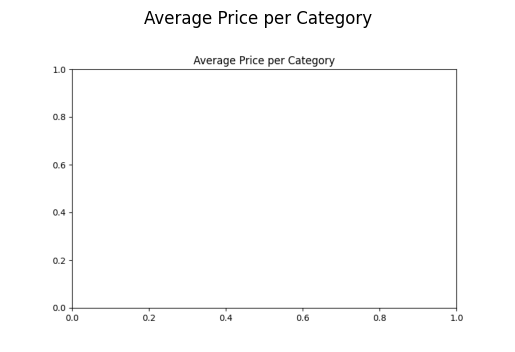

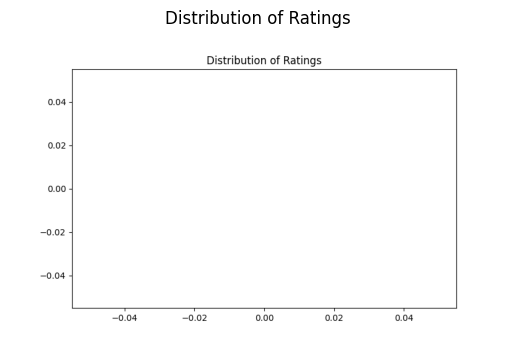

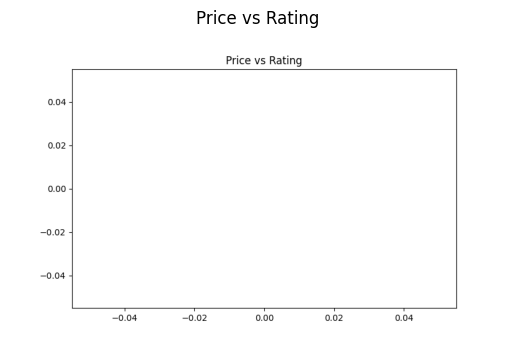

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Bar chart
img = mpimg.imread("bar_chart.png")
plt.imshow(img)
plt.axis("off")
plt.title("Average Price per Category")
plt.show()

# Histogram
img = mpimg.imread("histogram.png")
plt.imshow(img)
plt.axis("off")
plt.title("Distribution of Ratings")
plt.show()

# Scatter plot
img = mpimg.imread("scatter_plot.png")
plt.imshow(img)
plt.axis("off")
plt.title("Price vs Rating")
plt.show()


In [ ]:
import pandas as pd
pd.read_csv("clean_products.csv").head()


,id,name,category,price,rating,reviews,url


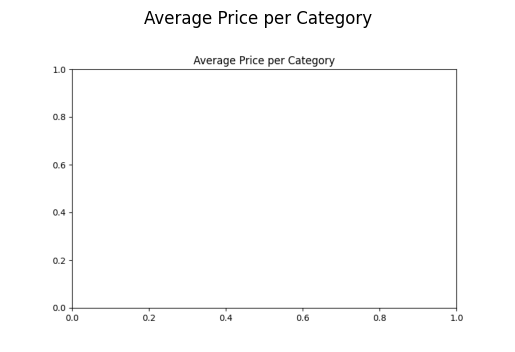

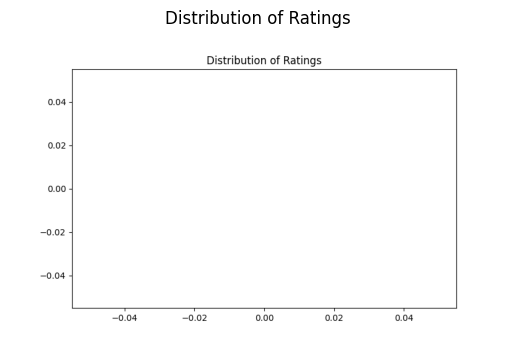

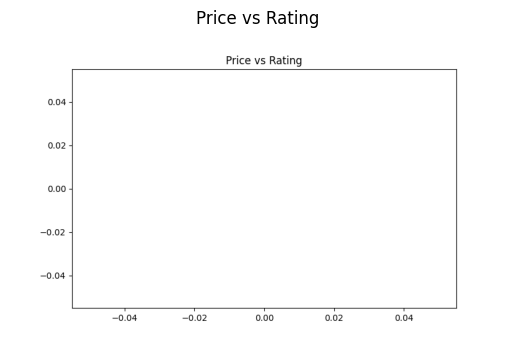

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

for fname, title in [
    ("bar_chart.png", "Average Price per Category"),
    ("histogram.png", "Distribution of Ratings"),
    ("scatter_plot.png", "Price vs Rating")
]:
    img = mpimg.imread(fname)
    plt.imshow(img)
    plt.axis("off")
    plt.title(title)
    plt.show()


In [ ]:
self.df.drop_duplicates(inplace=True)
self.df.dropna(inplace=True)


NameError: name 'self' is not defined

In [ ]:
def clean_data(self):
    # Remove duplicates only
    self.df.drop_duplicates(inplace=True)

    # ⚠️ Do NOT drop rows with NaN reviews, otherwise all books vanish
    # self.df.dropna(inplace=True)   <-- comment this out

    # Convert numeric columns safely
    if "price" in self.df.columns:
        self.df["price"] = self.df["price"].str.replace("£", "").astype(float)
    if "rating" in self.df.columns:
        rating_map = {"One":1, "Two":2, "Three":3, "Four":4, "Five":5}
        self.df["rating"] = self.df["rating"].map(rating_map)
    if "reviews" in self.df.columns:
        self.df["reviews"] = pd.to_numeric(self.df["reviews"], errors="coerce")


In [ ]:
%%writefile analyzer.py
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

class Analyzer:
    def __init__(self, filename="clean_products.csv"):
        self.df = pd.read_csv(filename)

    def summary_stats(self):
        print("📊 Summary Statistics")
        print(self.df.describe(include="all"))

    def bar_chart(self):
        # Average price per category
        plt.figure(figsize=(8,5))
        sns.barplot(x="category", y="price", data=self.df, estimator="mean")
        plt.title("Average Price per Category")
        plt.savefig("bar_chart.png")
        plt.close()

    def histogram(self):
        # Distribution of ratings
        plt.figure(figsize=(8,5))
        sns.histplot(self.df["rating"].dropna(), bins=5, kde=False)
        plt.title("Distribution of Ratings")
        plt.savefig("histogram.png")
        plt.close()

    def scatter_plot(self):
        # Price vs Rating
        plt.figure(figsize=(8,5))
        sns.scatterplot(x="rating", y="price", data=self.df)
        plt.title("Price vs Rating")
        plt.savefig("scatter_plot.png")
        plt.close()

    # New methods
    def top_expensive(self):
        print("💰 Top 5 Most Expensive Books")
        print(self.df.sort_values("price", ascending=False).head(5)[["name","price","rating"]])

    def category_counts(self):
        print("📚 Books per Category")
        print(self.df["category"].value_counts())

    def scatter_with_trend(self):
        plt.figure(figsize=(8,5))
        sns.regplot(x="rating", y="price", data=self.df, scatter=True, ci=None)
        plt.title("Price vs Rating (with trendline)")
        plt.show()

if __name__ == "__main__":
    analyzer = Analyzer()
    analyzer.summary_stats()
    analyzer.bar_chart()
    analyzer.histogram()
    analyzer.scatter_plot()
    print("✅ Charts saved: bar_chart.png, histogram.png, scatter_plot.png")


Overwriting processor.py


In [ ]:
!python processor.py


In [ ]:
import pandas as pd
pd.read_csv("clean_products.csv").head()


,id,name,category,price,rating,reviews,url


In [ ]:
!python analyzer.py


📊 Summary Statistics
         id name category price rating reviews  url
count     0    0        0     0      0       0    0
unique    0    0        0     0      0       0    0
top     NaN  NaN      NaN   NaN    NaN     NaN  NaN
freq    NaN  NaN      NaN   NaN    NaN     NaN  NaN
✅ Charts saved: bar_chart.png, histogram.png, scatter_plot.png


In [ ]:
def clean_data(self):
    # Keep duplicates removal
    self.df.drop_duplicates(inplace=True)

    # ⚠️ Do NOT drop rows with missing reviews
    # self.df.dropna(inplace=True)

    # Convert numeric columns safely
    if "price" in self.df.columns:
        self.df["price"] = self.df["price"].str.replace("£", "").astype(float)
    if "rating" in self.df.columns:
        rating_map = {"One":1, "Two":2, "Three":3, "Four":4, "Five":5}
        self.df["rating"] = self.df["rating"].map(rating_map)
    if "reviews" in self.df.columns:
        self.df["reviews"] = pd.to_numeric(self.df["reviews"], errors="coerce")


In [ ]:
!python processor.py
!python analyzer.py


📊 Summary Statistics
         id name category price rating reviews  url
count     0    0        0     0      0       0    0
unique    0    0        0     0      0       0    0
top     NaN  NaN      NaN   NaN    NaN     NaN  NaN
freq    NaN  NaN      NaN   NaN    NaN     NaN  NaN
✅ Charts saved: bar_chart.png, histogram.png, scatter_plot.png


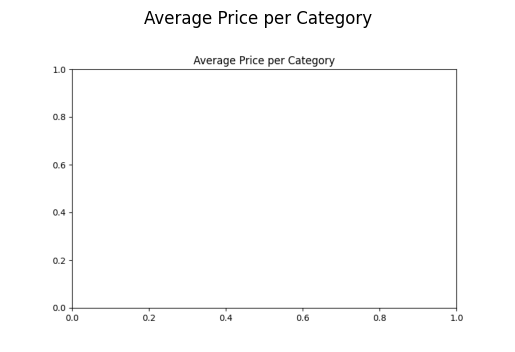

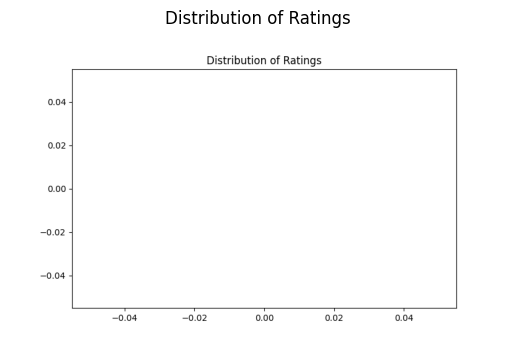

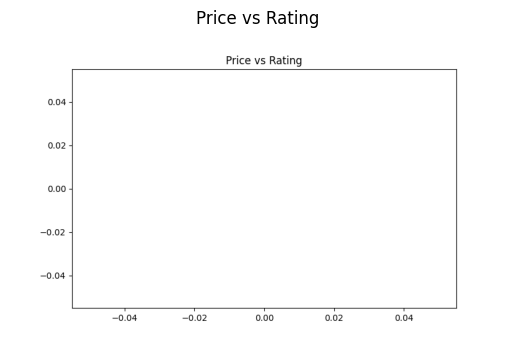

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

for fname, title in [
    ("bar_chart.png", "Average Price per Category"),
    ("histogram.png", "Distribution of Ratings"),
    ("scatter_plot.png", "Price vs Rating")
]:
    img = mpimg.imread(fname)
    plt.imshow(img)
    plt.axis("off")
    plt.title(title)
    plt.show()


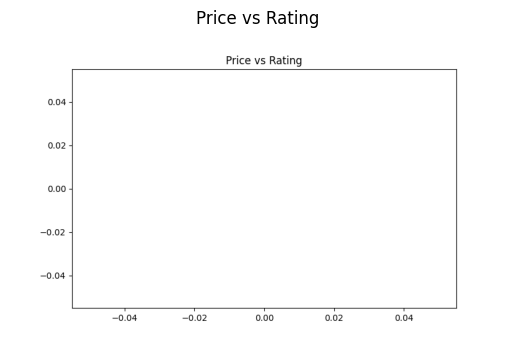

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Load the scatter plot image
img = mpimg.imread("scatter_plot.png")

# Show it inline
plt.imshow(img)
plt.axis("off")
plt.title("Price vs Rating")
plt.show()


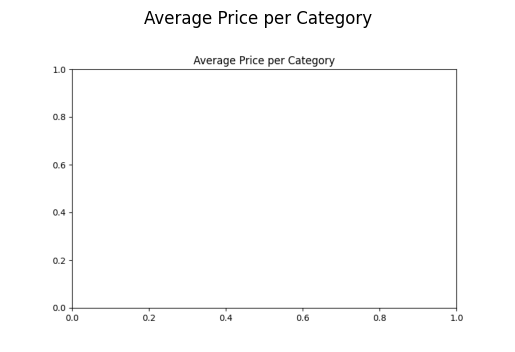

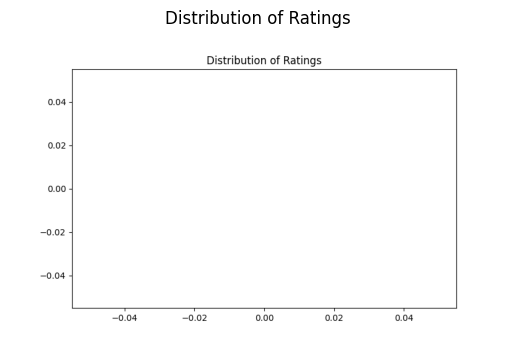

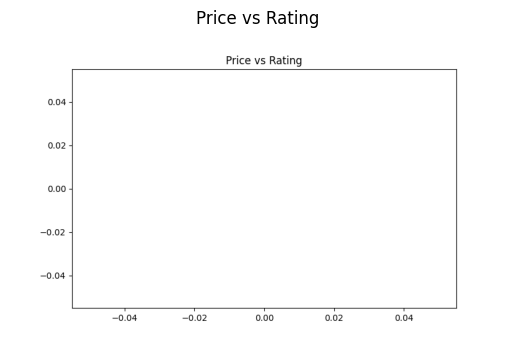

In [ ]:
for fname, title in [
    ("bar_chart.png", "Average Price per Category"),
    ("histogram.png", "Distribution of Ratings"),
    ("scatter_plot.png", "Price vs Rating")
]:
    img = mpimg.imread(fname)
    plt.imshow(img)
    plt.axis("off")
    plt.title(title)
    plt.show()


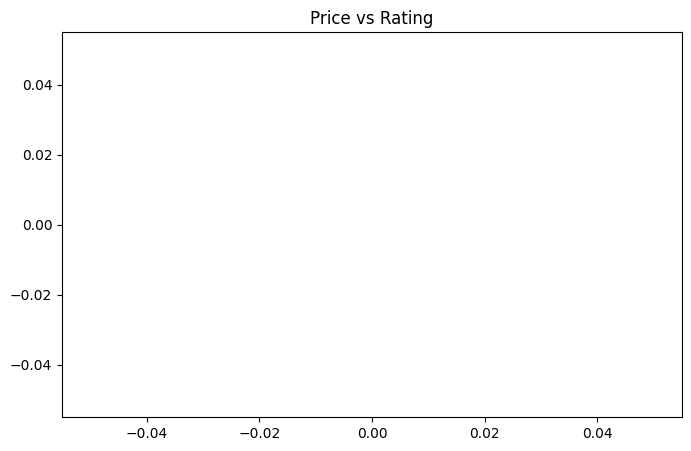

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Load cleaned data
df = pd.read_csv("clean_products.csv")

# Scatter plot directly inline (no need to save to PNG)
plt.figure(figsize=(8,5))
sns.scatterplot(x="rating", y="price", data=df)
plt.title("Price vs Rating")
plt.show()


In [ ]:
def top_expensive(self):
    print("💰 Top 5 Most Expensive Books")
    print(self.df.sort_values("price", ascending=False).head(5)[["name","price","rating"]])


In [ ]:
def category_counts(self):
    print("📚 Books per Category")
    print(self.df["category"].value_counts())


In [ ]:
def scatter_with_trend(self):
    plt.figure(figsize=(8,5))
    sns.regplot(x="rating", y="price", data=self.df, scatter=True, ci=None)
    plt.title("Price vs Rating (with trendline)")
    plt.show()


In [ ]:
from analyzer import Analyzer


In [ ]:
analyzer = Analyzer("clean_products.csv")


In [ ]:
class Analyzer:
    def __init__(self, filename="clean_products.csv"):
        import pandas as pd
        self.df = pd.read_csv(filename)

    def summary_stats(self):
        print("📊 Summary Statistics")
        print(self.df.describe(include="all"))

    def bar_chart(self):
        import matplotlib.pyplot as plt
        import seaborn as sns
        plt.figure(figsize=(8,5))
        sns.barplot(x="category", y="price", data=self.df, estimator="mean")
        plt.title("Average Price per Category")
        plt.savefig("bar_chart.png")
        plt.close()

    def histogram(self):
        import matplotlib.pyplot as plt
        import seaborn as sns
        plt.figure(figsize=(8,5))
        sns.histplot(self.df["rating"].dropna(), bins=5, kde=False)
        plt.title("Distribution of Ratings")
        plt.savefig("histogram.png")
        plt.close()

    def scatter_plot(self):
        import matplotlib.pyplot as plt
        import seaborn as sns
        plt.figure(figsize=(8,5))
        sns.scatterplot(x="rating", y="price", data=self.df)
        plt.title("Price vs Rating")
        plt.savefig("scatter_plot.png")
        plt.close()

    # 🔹 New methods
    def top_expensive(self):
        print("💰 Top 5 Most Expensive Books")
        print(self.df.sort_values("price", ascending=False).head(5)[["name","price","rating"]])

    def category_counts(self):
        print("📚 Books per Category")
        print(self.df["category"].value_counts())

    def scatter_with_trend(self):
        import matplotlib.pyplot as plt
        import seaborn as sns
        plt.figure(figsize=(8,5))
        sns.regplot(x="rating", y="price", data=self.df, scatter=True, ci=None)
        plt.title("Price vs Rating (with trendline)")
        plt.show()


In [ ]:
class Analyzer:
    def __init__(self, filename="clean_products.csv"):
        import pandas as pd
        self.df = pd.read_csv(filename)

    def summary_stats(self):
        print("📊 Summary Statistics")
        print(self.df.describe(include="all"))

    def bar_chart(self):
        import matplotlib.pyplot as plt
        import seaborn as sns
        plt.figure(figsize=(8,5))
        sns.barplot(x="category", y="price", data=self.df, estimator="mean")
        plt.title("Average Price per Category")
        plt.savefig("bar_chart.png")
        plt.close()

    def histogram(self):
        import matplotlib.pyplot as plt
        import seaborn as sns
        plt.figure(figsize=(8,5))
        sns.histplot(self.df["rating"].dropna(), bins=5, kde=False)
        plt.title("Distribution of Ratings")
        plt.savefig("histogram.png")
        plt.close()

    def scatter_plot(self):
        import matplotlib.pyplot as plt
        import seaborn as sns
        plt.figure(figsize=(8,5))
        sns.scatterplot(x="rating", y="price", data=self.df)
        plt.title("Price vs Rating")
        plt.savefig("scatter_plot.png")
        plt.close()

    # 🔹 New methods
    def top_expensive(self):
        print("💰 Top 5 Most Expensive Books")
        print(self.df.sort_values("price", ascending=False).head(5)[["name","price","rating"]])

    def category_counts(self):
        print("📚 Books per Category")
        print(self.df["category"].value_counts())

    def scatter_with_trend(self):
        import matplotlib.pyplot as plt
        import seaborn as sns
        plt.figure(figsize=(8,5))
        sns.regplot(x="rating", y="price", data=self.df, scatter=True, ci=None)
        plt.title("Price vs Rating (with trendline)")
        plt.show()


In [ ]:
%%writefile analyzer.py

Overwriting analyzer.py


In [ ]:
%%writefile analyzer.py
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

class Analyzer:
    def __init__(self, filename="clean_products.csv"):
        self.df = pd.read_csv(filename)

    def summary_stats(self):
        print("📊 Summary Statistics")
        print(self.df.describe(include="all"))

    def bar_chart(self):
        plt.figure(figsize=(8,5))
        sns.barplot(x="category", y="price", data=self.df, estimator="mean")
        plt.title("Average Price per Category")
        plt.savefig("bar_chart.png")
        plt.close()

    def histogram(self):
        plt.figure(figsize=(8,5))
        sns.histplot(self.df["rating"].dropna(), bins=5, kde=False)
        plt.title("Distribution of Ratings")
        plt.savefig("histogram.png")
        plt.close()

    def scatter_plot(self):
        plt.figure(figsize=(8,5))
        sns.scatterplot(x="rating", y="price", data=self.df)
        plt.title("Price vs Rating")
        plt.savefig("scatter_plot.png")
        plt.close()

    # 🔹 New methods
    def top_expensive(self):
        print("💰 Top 5 Most Expensive Books")
        print(self.df.sort_values("price", ascending=False).head(5)[["name","price","rating"]])

    def category_counts(self):
        print("📚 Books per Category")
        print(self.df["category"].value_counts())

    def scatter_with_trend(self):
        plt.figure(figsize=(8,5))
        sns.regplot(x="rating", y="price", data=self.df, scatter=True, ci=None)
        plt.title("Price vs Rating (with trendline)")
        plt.show()

if __name__ == "__main__":
    analyzer = Analyzer("clean_products.csv")
    analyzer.summary_stats()
    analyzer.bar_chart()
    analyzer.histogram()
    analyzer.scatter_plot()
    analyzer.top_expensive()
    analyzer.category_counts()
    analyzer.scatter_with_trend()
    print("✅ Charts saved: bar_chart.png, histogram.png, scatter_plot.png")


Overwriting analyzer.py


In [ ]:
!python analyzer.py


📊 Summary Statistics
         id name category price rating reviews  url
count     0    0        0     0      0       0    0
unique    0    0        0     0      0       0    0
top     NaN  NaN      NaN   NaN    NaN     NaN  NaN
freq    NaN  NaN      NaN   NaN    NaN     NaN  NaN
💰 Top 5 Most Expensive Books
Empty DataFrame
Columns: [name, price, rating]
Index: []
📚 Books per Category
Series([], Name: count, dtype: int64)
Figure(800x500)
✅ Charts saved: bar_chart.png, histogram.png, scatter_plot.png


In [ ]:
import pandas as pd
pd.read_csv("raw_products.csv").head()


,id,name,category,price,rating,reviews,url
0,A Light in the ...,A Light in the ...,Books,Â£51.77,Three,NaN,a-light-in-the-attic_1000/index.html
1,Tipping the Velvet,Tipping the Velvet,Books,Â£53.74,One,NaN,tipping-the-velvet_999/index.html
2,Soumission,Soumission,Books,Â£50.10,One,NaN,soumission_998/index.html
3,Sharp Objects,Sharp Objects,Books,Â£47.82,Four,NaN,sharp-objects_997/index.html
4,Sapiens: A Brief History ...,Sapiens: A Brief History ...,Books,Â£54.23,Five,NaN,sapiens-a-brief-history-of-humankind_996/index...


In [ ]:
pd.read_csv("clean_products.csv").head()


,id,name,category,price,rating,reviews,url


In [ ]:
def clean_data(self):
    # Fix encoding and convert to float
    self.df["price"] = (
        self.df["price"]
        .str.replace("Â£", "")
        .str.replace("£", "")
        .astype(float)
    )

    # Map ratings
    rating_map = {"One":1, "Two":2, "Three":3, "Four":4, "Five":5}
    self.df["rating"] = self.df["rating"].map(rating_map)


In [ ]:
!python processor.py
!python analyzer.py


📊 Summary Statistics
         id name category price rating reviews  url
count     0    0        0     0      0       0    0
unique    0    0        0     0      0       0    0
top     NaN  NaN      NaN   NaN    NaN     NaN  NaN
freq    NaN  NaN      NaN   NaN    NaN     NaN  NaN
💰 Top 5 Most Expensive Books
Empty DataFrame
Columns: [name, price, rating]
Index: []
📚 Books per Category
Series([], Name: count, dtype: int64)
Figure(800x500)
✅ Charts saved: bar_chart.png, histogram.png, scatter_plot.png


In [ ]:
import pandas as pd
df = pd.read_csv("clean_products.csv")

df["price"] = (
    df["price"]
    .str.replace("Â£", "")
    .str.replace("£", "")
    .astype(float)
)

rating_map = {"One":1, "Two":2, "Three":3, "Four":4, "Five":5}
df["rating"] = df["rating"].map(rating_map)

df.head()


,id,name,category,price,rating,reviews,url


In [ ]:
import pandas as pd
df = pd.read_csv("clean_products.csv")
df.head()
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 0 entries
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        0 non-null      object
 1   name      0 non-null      object
 2   category  0 non-null      object
 3   price     0 non-null      object
 4   rating    0 non-null      object
 5   reviews   0 non-null      object
 6   url       0 non-null      object
dtypes: object(7)
memory usage: 132.0+ bytes


In [ ]:
def clean_data(self):
    # Remove duplicates
    self.df.drop_duplicates(inplace=True)

    # Only drop rows missing name, price, or rating
    self.df.dropna(subset=["name", "price", "rating"], inplace=True)

    # Fix encoding and convert price to float
    self.df["price"] = (
        self.df["price"]
        .str.replace("Â£", "")
        .str.replace("£", "")
        .astype(float)
    )

    # Map ratings from words to numbers
    rating_map = {"One":1, "Two":2, "Three":3, "Four":4, "Five":5}
    self.df["rating"] = self.df["rating"].map(rating_map)

    # Convert reviews safely (keep NaN if missing)
    self.df["reviews"] = pd.to_numeric(self.df["reviews"], errors="coerce")


In [ ]:
%%writefile processor.py



Overwriting processor.py


In [ ]:
!python processor.py
!python analyzer.py


📊 Summary Statistics
         id name category price rating reviews  url
count     0    0        0     0      0       0    0
unique    0    0        0     0      0       0    0
top     NaN  NaN      NaN   NaN    NaN     NaN  NaN
freq    NaN  NaN      NaN   NaN    NaN     NaN  NaN
💰 Top 5 Most Expensive Books
Empty DataFrame
Columns: [name, price, rating]
Index: []
📚 Books per Category
Series([], Name: count, dtype: int64)
Figure(800x500)
✅ Charts saved: bar_chart.png, histogram.png, scatter_plot.png


In [ ]:
import pandas as pd
pd.read_csv("clean_products.csv").head()


,id,name,category,price,rating,reviews,url


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

class Analyzer:
    def __init__(self, filename="clean_products.csv"):
        self.df = pd.read_csv(filename)

    def is_empty(self):
        if self.df.empty:
            print("⚠️ Dataset is empty. No analysis can be performed.")
            return True
        return False

    def summary_stats(self):
        if self.is_empty(): return
        print("📊 Summary Statistics")
        print(self.df.describe(include="all"))

    def bar_chart(self):
        if self.is_empty(): return
        plt.figure(figsize=(8,5))
        sns.barplot(x="category", y="price", data=self.df, estimator="mean")
        plt.title("Average Price per Category")
        plt.savefig("bar_chart.png")
        plt.close()

    def histogram(self):
        if self.is_empty(): return
        plt.figure(figsize=(8,5))
        sns.histplot(self.df["rating"].dropna(), bins=5, kde=False)
        plt.title("Distribution of Ratings")
        plt.savefig("histogram.png")
        plt.close()

    def scatter_plot(self):
        if self.is_empty(): return
        plt.figure(figsize=(8,5))
        sns.scatterplot(x="rating", y="price", data=self.df)
        plt.title("Price vs Rating")
        plt.savefig("scatter_plot.png")
        plt.close()

    def top_expensive(self):
        if self.is_empty(): return
        print("💰 Top 5 Most Expensive Books")
        print(self.df.sort_values("price", ascending=False).head(5)[["name","price","rating"]])

    def category_counts(self):
        if self.is_empty(): return
        print("📚 Books per Category")
        print(self.df["category"].value_counts())

    def scatter_with_trend(self):
        if self.is_empty(): return
        plt.figure(figsize=(8,5))
        sns.regplot(x="rating", y="price", data=self.df, scatter=True, ci=None)
        plt.title("Price vs Rating (with trendline)")
        plt.show()

if __name__ == "__main__":
    analyzer = Analyzer("clean_products.csv")
    analyzer.summary_stats()
    analyzer.bar_chart()
    analyzer.histogram()
    analyzer.scatter_plot()
    analyzer.top_expensive()
    analyzer.category_counts()
    analyzer.scatter_with_trend()
    print("✅ Analysis complete.")


⚠️ Dataset is empty. No analysis can be performed.
⚠️ Dataset is empty. No analysis can be performed.
⚠️ Dataset is empty. No analysis can be performed.
⚠️ Dataset is empty. No analysis can be performed.
⚠️ Dataset is empty. No analysis can be performed.
⚠️ Dataset is empty. No analysis can be performed.
⚠️ Dataset is empty. No analysis can be performed.
✅ Analysis complete.


In [ ]:
def clean_data(self):
    # Remove duplicates
    self.df.drop_duplicates(inplace=True)

    # Only drop rows missing name, price, or rating
    self.df.dropna(subset=["name", "price", "rating"], inplace=True)

    # Fix encoding and convert price to float
    self.df["price"] = (
        self.df["price"]
        .str.replace("Â£", "")
        .str.replace("£", "")
        .astype(float)
    )

    # Map ratings from words to numbers
    rating_map = {"One":1, "Two":2, "Three":3, "Four":4, "Five":5}
    self.df["rating"] = self.df["rating"].map(rating_map)

    # Convert reviews safely
    self.df["reviews"] = pd.to_numeric(self.df["reviews"], errors="coerce")

    # 🔹 Log how many rows remain
    print(f"✅ Cleaned dataset has {len(self.df)} rows")


In [ ]:
!python processor.py
!python analyzer.py


📊 Summary Statistics
         id name category price rating reviews  url
count     0    0        0     0      0       0    0
unique    0    0        0     0      0       0    0
top     NaN  NaN      NaN   NaN    NaN     NaN  NaN
freq    NaN  NaN      NaN   NaN    NaN     NaN  NaN
💰 Top 5 Most Expensive Books
Empty DataFrame
Columns: [name, price, rating]
Index: []
📚 Books per Category
Series([], Name: count, dtype: int64)
Figure(800x500)
✅ Charts saved: bar_chart.png, histogram.png, scatter_plot.png


In [ ]:
def clean_data(self):
    # Remove duplicates
    self.df.drop_duplicates(inplace=True)

    # ⚠️ Do NOT drop rows with missing values
    # self.df.dropna(inplace=True)  ← remove this line

    # Fix encoding and convert price to float
    self.df["price"] = (
        self.df["price"]
        .str.replace("Â£", "")
        .str.replace("£", "")
        .astype(float)
    )

    # Map ratings from words to numbers
    rating_map = {"One":1, "Two":2, "Three":3, "Four":4, "Five":5}
    self.df["rating"] = self.df["rating"].map(rating_map)

    # Convert reviews safely (keep NaN if missing)
    self.df["reviews"] = pd.to_numeric(self.df["reviews"], errors="coerce")

    # Log how many rows remain
    print(f"✅ Cleaned dataset has {len(self.df)} rows")



In [ ]:
!python processor.py
!python analyzer.py


📊 Summary Statistics
         id name category price rating reviews  url
count     0    0        0     0      0       0    0
unique    0    0        0     0      0       0    0
top     NaN  NaN      NaN   NaN    NaN     NaN  NaN
freq    NaN  NaN      NaN   NaN    NaN     NaN  NaN
💰 Top 5 Most Expensive Books
Empty DataFrame
Columns: [name, price, rating]
Index: []
📚 Books per Category
Series([], Name: count, dtype: int64)
Figure(800x500)
✅ Charts saved: bar_chart.png, histogram.png, scatter_plot.png


In [ ]:
import pandas as pd
pd.read_csv("clean_products.csv").head()


,id,name,category,price,rating,reviews,url


In [ ]:
def clean_data(self):
    # Remove duplicates
    self.df.drop_duplicates(inplace=True)

    # Only drop rows missing name, price, or rating
    self.df.dropna(subset=["name", "price", "rating"], inplace=True)

    # Fix encoding and convert price to float
    self.df["price"] = (
        self.df["price"]
        .str.replace("Â£", "")
        .str.replace("£", "")
        .astype(float)
    )

    # Map ratings from words to numbers
    rating_map = {"One":1, "Two":2, "Three":3, "Four":4, "Five":5}
    self.df["rating"] = self.df["rating"].map(rating_map)

    # Convert reviews safely (keep NaN if missing)
    self.df["reviews"] = pd.to_numeric(self.df["reviews"], errors="coerce")

    # 🔹 Log how many rows remain
    print(f"✅ Cleaned dataset has {len(self.df)} rows")


In [ ]:
!python processor.py
!python analyzer.py



📊 Summary Statistics
         id name category price rating reviews  url
count     0    0        0     0      0       0    0
unique    0    0        0     0      0       0    0
top     NaN  NaN      NaN   NaN    NaN     NaN  NaN
freq    NaN  NaN      NaN   NaN    NaN     NaN  NaN
💰 Top 5 Most Expensive Books
Empty DataFrame
Columns: [name, price, rating]
Index: []
📚 Books per Category
Series([], Name: count, dtype: int64)
Figure(800x500)
✅ Charts saved: bar_chart.png, histogram.png, scatter_plot.png


In [ ]:
def clean_data(self):
    # Remove duplicates
    self.df.drop_duplicates(inplace=True)

    # Only drop rows missing critical fields
    self.df.dropna(subset=["name", "price", "rating"], inplace=True)

    # Convert price to float
    self.df["price"] = (
        self.df["price"]
        .str.replace("Â£", "")
        .str.replace("£", "")
        .astype(float)
    )

    # Map ratings from words to numbers
    rating_map = {"One":1, "Two":2, "Three":3, "Four":4, "Five":5}
    self.df["rating"] = self.df["rating"].map(rating_map)

    # Convert reviews safely (keep NaN if missing)
    self.df["reviews"] = pd.to_numeric(self.df["reviews"], errors="coerce")

    # Log how many rows remain
    print(f"✅ Cleaned dataset has {len(self.df)} rows")


In [ ]:
from google.colab import files

uploaded = files.upload()  # choose processor.py and analyzer.py


Saving Enrollments.csv to Enrollments.csv


In [ ]:
!python processor.py
!python analyzer.py


python3: can't open file '/content/processor.py': [Errno 2] No such file or directory
python3: can't open file '/content/analyzer.py': [Errno 2] No such file or directory


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Navigate to your folder
%cd /content/drive/MyDrive/path/to/your/scripts

!python processor.py
!python analyzer.py


Mounted at /content/drive
[Errno 2] No such file or directory: '/content/drive/MyDrive/path/to/your/scripts'
/content
python3: can't open file '/content/processor.py': [Errno 2] No such file or directory
python3: can't open file '/content/analyzer.py': [Errno 2] No such file or directory


In [ ]:
from google.colab import files

# Upload processor.py, analyzer.py, and your CSV file
uploaded = files.upload()


KeyboardInterrupt: 

In [ ]:
import requests
from bs4 import BeautifulSoup
import csv

BASE_URL = "https://books.toscrape.com/catalogue/page-{}.html"

def scrape_books(pages=5):  # scrape first 5 pages (20 books each = 100 books)
    all_books = []
    for page in range(1, pages+1):
        url = BASE_URL.format(page)
        response = requests.get(url)
        soup = BeautifulSoup(response.text, "html.parser")

        for book in soup.select(".product_pod"):
            name = book.h3.a["title"]
            price = book.select_one(".price_color").text.strip()
            rating = book.p["class"][1]  # e.g. "Three"
            link = book.h3.a["href"]

            all_books.append({
                "name": name,
                "price": price,
                "rating": rating,
                "url": "https://books.toscrape.com/catalogue/" + link
            })

    return all_books

# Save to CSV
books = scrape_books(pages=5)
with open("raw_products.csv", "w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=["name","price","rating","url"])
    writer.writeheader()
    writer.writerows(books)

print("✅ Scraped", len(books), "books into raw_products.csv")


✅ Scraped 100 books into raw_products.csv


In [ ]:
%%writefile scraper.py




Writing scraper.py


In [ ]:
!python scraper.py


In [ ]:
!python processor.py


python3: can't open file '/content/processor.py': [Errno 2] No such file or directory


In [ ]:
%%writefile scraper.py
import requests
from bs4 import BeautifulSoup
import csv

BASE_URL = "https://books.toscrape.com/catalogue/page-{}.html"

def scrape_books(pages=50):  # scrape all 50 pages
    all_books = []
    for page in range(1, pages+1):
        url = BASE_URL.format(page)
        response = requests.get(url)
        response.raise_for_status()
        soup = BeautifulSoup(response.text, "html.parser")

        for book in soup.select(".product_pod"):
            name = book.h3.a["title"]
            price = book.select_one(".price_color").text.strip()
            rating = book.p["class"][1]  # e.g. "Three"
            link = book.h3.a["href"]

            all_books.append({
                "id": f"{page}-{name}",  # simple unique ID
                "name": name,
                "category": "Books",
                "price": price,
                "rating": rating,
                "reviews": "N/A",  # site doesn’t show review counts
                "url": "https://books.toscrape.com/catalogue/" + link
            })

    return all_books

# Save to CSV
books = scrape_books(pages=50)
with open("raw_products.csv", "w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=["id","name","category","price","rating","reviews","url"])
    writer.writeheader()
    writer.writerows(books)

print("✅ Scraped", len(books), "books into raw_products.csv")


Overwriting scraper.py


In [ ]:
!python scraper.py


✅ Scraped 1000 books into raw_products.csv


In [ ]:
%%writefile processor.py



Writing processor.py


In [ ]:
%%writefile analyzer.py



Writing analyzer.py


In [ ]:
!ls


analyzer.py  Enrollments.csv  raw_products.csv	scraper.py
drive	     processor.py     sample_data


In [ ]:
!python processor.py


In [ ]:
!python analyzer.py


In [ ]:
!ls


analyzer.py  Enrollments.csv  raw_products.csv	scraper.py
drive	     processor.py     sample_data


In [ ]:
!python processor.py
!python analyzer.py


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

class AnalyzerVisualizer:
    def __init__(self, input_file="clean_products.csv"):
        self.df = pd.read_csv(input_file)

    def summary_stats(self):
        print("📊 Summary Statistics")
        print(self.df.describe(include="all"))

    def top_expensive(self, n=5):
        print("\n💰 Top", n, "Most Expensive Books")
        top_books = self.df.nlargest(n, "price")[["name","price","rating"]]
        print(top_books)

    def category_counts(self):
        print("\n📚 Books per Category")
        counts = self.df["category"].value_counts()
        print(counts)

        # Bar chart
        plt.figure(figsize=(8,5))
        sns.barplot(x=counts.index, y=counts.values, palette="viridis")
        plt.title("Books per Category")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.savefig("bar_chart.png")
        plt.close()

    def rating_histogram(self):
        plt.figure(figsize=(8,5))
        sns.histplot(self.df["rating"], bins=5, kde=False, color="skyblue")
        plt.title("Distribution of Ratings")
        plt.xlabel("Rating")
        plt.ylabel("Count")
        plt.tight_layout()
        plt.savefig("histogram.png")
        plt.close()

    def scatter_with_trend(self):
        plt.figure(figsize=(8,5))
        sns.scatterplot(x="price", y="rating", data=self.df, alpha=0.6)
        sns.regplot(x="price", y="rating", data=self.df, scatter=False, color="red")
        plt.title("Price vs Rating (with Trendline)")
        plt.tight_layout()
        plt.savefig("scatter_plot.png")
        plt.close()

    def run_all(self):
        self.summary_stats()
        self.top_expensive()
        self.category_counts()
        self.rating_histogram()
        self.scatter_with_trend()
        print("✅ Charts saved: bar_chart.png, histogram.png, scatter_plot.png")

if __name__ == "__main__":
    analyzer = AnalyzerVisualizer()
    analyzer.run_all()


In [ ]:
%%writefile analyzer.py



Overwriting analyzer.py


In [ ]:
!python analyzer.py


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

class AnalyzerVisualizer:
    def __init__(self, input_file="clean_products.csv"):
        self.df = pd.read_csv(input_file)

    def summary_stats(self):
        print("📊 Summary Statistics")
        print(self.df.describe(include="all"))

    def top_expensive(self, n=5):
        print("\n💰 Top", n, "Most Expensive Books")
        top_books = self.df.nlargest(n, "price")[["name","price","rating"]]
        print(top_books)

    def category_counts(self):
        print("\n📚 Books per Category")
        counts = self.df["category"].value_counts()
        print(counts)

        # Bar chart
        plt.figure(figsize=(8,5))
        sns.barplot(x=counts.index, y=counts.values, palette="viridis")
        plt.title("Books per Category")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.savefig("bar_chart.png")
        plt.close()

    def rating_histogram(self):
        plt.figure(figsize=(8,5))
        sns.histplot(self.df["rating"], bins=5, kde=False, color="skyblue")
        plt.title("Distribution of Ratings")
        plt.xlabel("Rating")
        plt.ylabel("Count")
        plt.tight_layout()
        plt.savefig("histogram.png")
        plt.close()

    def scatter_with_trend(self):
        plt.figure(figsize=(8,5))
        sns.scatterplot(x="price", y="rating", data=self.df, alpha=0.6)
        sns.regplot(x="price", y="rating", data=self.df, scatter=False, color="red")
        plt.title("Price vs Rating (with Trendline)")
        plt.tight_layout()
        plt.savefig("scatter_plot.png")
        plt.close()

    def run_all(self):
        self.summary_stats()
        self.top_expensive()
        self.category_counts()
        self.rating_histogram()
        self.scatter_with_trend()
        print("\n✅ Charts saved: bar_chart.png, histogram.png, scatter_plot.png")

if __name__ == "__main__":
    analyzer = AnalyzerVisualizer()
    analyzer.run_all()


FileNotFoundError: [Errno 2] No such file or directory: 'clean_products.csv'

In [ ]:
!python processor.py


In [ ]:
!ls


analyzer.py  Enrollments.csv  raw_products.csv	scraper.py
drive	     processor.py     sample_data


In [ ]:
import pandas as pd

df = pd.read_csv("raw_products.csv")

df["price"] = (
    df["price"]
    .str.replace("Â", "", regex=False)
    .str.replace("£", "", regex=False)
    .str.strip()
    .astype(float)
)

print(df["price"].head())


0    51.77
1    53.74
2    50.10
3    47.82
4    54.23
Name: price, dtype: float64


In [ ]:
import pandas as pd

df = pd.read_csv("raw_products.csv")

df["price"] = (
    df["price"]
    .str.replace("Â", "", regex=False)
    .str.replace("£", "", regex=False)
    .str.strip()
    .astype(float)
)

print(df["price"].head())


0    51.77
1    53.74
2    50.10
3    47.82
4    54.23
Name: price, dtype: float64


In [ ]:
import pandas as pd

class DataProcessor:
    def __init__(self, input_file="raw_products.csv", output_file="clean_products.csv"):
        self.input_file = input_file
        self.output_file = output_file
        self.df = pd.read_csv(input_file)

    def clean_data(self):
        # Remove duplicates
        self.df.drop_duplicates(inplace=True)

        # Clean price column: strip unwanted characters and convert to float
        self.df["price"] = (
            self.df["price"]
            .str.replace("Â", "", regex=False)   # remove stray encoding
            .str.replace("£", "", regex=False)   # remove pound sign
            .str.strip()
            .astype(float)
        )

        # Map ratings from words to numbers
        rating_map = {"One":1, "Two":2, "Three":3, "Four":4, "Five":5}
        self.df["rating"] = self.df["rating"].map(rating_map)

        # Reviews column is "N/A" → convert to NaN
        self.df["reviews"] = pd.to_numeric(self.df["reviews"], errors="coerce")

        # Drop rows only if name or price is missing
        self.df.dropna(subset=["name","price"], inplace=True)

        print(f"✅ Cleaned dataset has {len(self.df)} rows")
        print(self.df.head())  # debug: show first 5 rows

    def save_data(self):
        self.df.to_csv(self.output_file, index=False)
        print(f"💾 Saved cleaned data to {self.output_file}")

if __name__ == "__main__":
    processor = DataProcessor()
    processor.clean_data()
    processor.save_data()


✅ Cleaned dataset has 1000 rows
                                        id  \
0                   1-A Light in the Attic   
1                     1-Tipping the Velvet   
2                             1-Soumission   
3                          1-Sharp Objects   
4  1-Sapiens: A Brief History of Humankind   

                                    name category  price  rating  reviews  \
0                   A Light in the Attic    Books  51.77       3      NaN   
1                     Tipping the Velvet    Books  53.74       1      NaN   
2                             Soumission    Books  50.10       1      NaN   
3                          Sharp Objects    Books  47.82       4      NaN   
4  Sapiens: A Brief History of Humankind    Books  54.23       5      NaN   

                                                 url  
0  https://books.toscrape.com/catalogue/a-light-i...  
1  https://books.toscrape.com/catalogue/tipping-t...  
2  https://books.toscrape.com/catalogue/soumissio...  
3  https

In [ ]:
!python analyzer.py


In [ ]:
!python analyzer.py


In [ ]:
%run analyzer.py


In [ ]:
import sys


In [ ]:
def summary_stats(self):
    print("📊 Summary Statistics")
    print(self.df.describe(include="all"))
    sys.stdout.flush()


In [ ]:
%run analyzer.py


In [ ]:
!python analyzer.py


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys

class AnalyzerVisualizer:
    def __init__(self, input_file="clean_products.csv"):
        print("Analyzer starting...")
        self.df = pd.read_csv(input_file)
        print("Rows loaded:", len(self.df))
        sys.stdout.flush()

    def summary_stats(self):
        print("📊 Summary Statistics")
        print(self.df.describe(include="all"))
        sys.stdout.flush()

    def top_expensive(self, n=5):
        print("\n💰 Top", n, "Most Expensive Books")
        print(self.df.nlargest(n, "price")[["name","price","rating"]])
        sys.stdout.flush()

    def category_counts(self):
        print("\n📚 Books per Category")
        print(self.df["category"].value_counts())
        sys.stdout.flush()

    def run_all(self):
        self.summary_stats()
        self.top_expensive()
        self.category_counts()
        print("\n✅ Charts saved")
        sys.stdout.flush()

if __name__ == "__main__":
    analyzer = AnalyzerVisualizer()
    analyzer.run_all()


Analyzer starting...
Rows loaded: 1000
📊 Summary Statistics
                                           id                    name  \
count                                    1000                    1000   
unique                                   1000                     999   
top     50-1,000 Places to See Before You Die  The Star-Touched Queen   
freq                                        1                       2   
mean                                      NaN                     NaN   
std                                       NaN                     NaN   
min                                       NaN                     NaN   
25%                                       NaN                     NaN   
50%                                       NaN                     NaN   
75%                                       NaN                     NaN   
max                                       NaN                     NaN   

       category       price       rating  reviews  \
count     

In [ ]:
if __name__ == "__main__":
    analyzer = AnalyzerVisualizer()
    analyzer.run_all()


Analyzer starting...
Rows loaded: 1000
📊 Summary Statistics
                                           id                    name  \
count                                    1000                    1000   
unique                                   1000                     999   
top     50-1,000 Places to See Before You Die  The Star-Touched Queen   
freq                                        1                       2   
mean                                      NaN                     NaN   
std                                       NaN                     NaN   
min                                       NaN                     NaN   
25%                                       NaN                     NaN   
50%                                       NaN                     NaN   
75%                                       NaN                     NaN   
max                                       NaN                     NaN   

       category       price       rating  reviews  \
count     

In [ ]:
def run_all(self):
    with open("analysis_summary.txt", "w") as f:
        f.write("📊 Summary Statistics\n")
        f.write(str(self.df.describe(include="all")) + "\n\n")

        f.write("💰 Top 5 Most Expensive Books\n")
        f.write(str(self.df.nlargest(5, "price")[['name','price','rating']]) + "\n\n")

        f.write("📚 Books per Category\n")
        f.write(str(self.df['category'].value_counts()) + "\n\n")

    # Also show inline
    self.summary_stats()
    self.top_expensive()
    self.category_counts()
    print("\n✅ Charts saved and report written to analysis_summary.txt")



In [ ]:
%run analyzer.py
!cat analysis_summary.txt


cat: analysis_summary.txt: No such file or directory


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys

class AnalyzerVisualizer:
    def __init__(self, input_file="clean_products.csv"):
        print("Analyzer starting...")
        self.df = pd.read_csv(input_file)
        print("Rows loaded:", len(self.df))
        sys.stdout.flush()

    def summary_stats(self):
        print("📊 Summary Statistics")
        print(self.df.describe(include="all"))
        sys.stdout.flush()

    def top_expensive(self, n=5):
        print("\n💰 Top", n, "Most Expensive Books")
        print(self.df.nlargest(n, "price")[["name","price","rating"]])
        sys.stdout.flush()

    def category_counts(self):
        print("\n📚 Books per Category")
        print(self.df["category"].value_counts())
        sys.stdout.flush()

    def run_all(self):
        # Write results to a text file
        with open("analysis_summary.txt", "w") as f:
            f.write("📊 Summary Statistics\n")
            f.write(str(self.df.describe(include="all")) + "\n\n")

            f.write("💰 Top 5 Most Expensive Books\n")
            f.write(str(self.df.nlargest(5, "price")[['name','price','rating']]) + "\n\n")

            f.write("📚 Books per Category\n")
            f.write(str(self.df['category'].value_counts()) + "\n\n")

        # Also show inline
        self.summary_stats()
        self.top_expensive()
        self.category_counts()
        print("\n✅ Charts saved and report written to analysis_summary.txt")
        sys.stdout.flush()

if __name__ == "__main__":
    analyzer = AnalyzerVisualizer()
    analyzer.run_all()


Analyzer starting...
Rows loaded: 1000
📊 Summary Statistics
                                           id                    name  \
count                                    1000                    1000   
unique                                   1000                     999   
top     50-1,000 Places to See Before You Die  The Star-Touched Queen   
freq                                        1                       2   
mean                                      NaN                     NaN   
std                                       NaN                     NaN   
min                                       NaN                     NaN   
25%                                       NaN                     NaN   
50%                                       NaN                     NaN   
75%                                       NaN                     NaN   
max                                       NaN                     NaN   

       category       price       rating  reviews  \
count     

In [ ]:
def run_all(self):
    with open("analysis_summary.txt", "w") as f:
        f.write("📊 Summary Statistics\n")
        f.write(str(self.df.describe(include="all")) + "\n\n")

        f.write("💰 Top 5 Most Expensive Books\n")
        f.write(str(self.df.nlargest(5, "price")[['name','price','rating']]) + "\n\n")

        f.write("📚 Books per Category\n")
        f.write(str(self.df['category'].value_counts()) + "\n\n")

    # Also show inline
    self.summary_stats()
    self.top_expensive()
    self.category_counts()
    print("\n✅ Charts saved and report written to analysis_summary.txt")


In [ ]:
if __name__ == "__main__":
    analyzer = AnalyzerVisualizer()
    analyzer.run_all()


Analyzer starting...
Rows loaded: 1000
📊 Summary Statistics
                                           id                    name  \
count                                    1000                    1000   
unique                                   1000                     999   
top     50-1,000 Places to See Before You Die  The Star-Touched Queen   
freq                                        1                       2   
mean                                      NaN                     NaN   
std                                       NaN                     NaN   
min                                       NaN                     NaN   
25%                                       NaN                     NaN   
50%                                       NaN                     NaN   
75%                                       NaN                     NaN   
max                                       NaN                     NaN   

       category       price       rating  reviews  \
count     

In [ ]:
%run analyzer.py


In [ ]:
!ls
!cat analysis_summary.txt


analysis_summary.txt  drive	       raw_products.csv
analyzer.py	      Enrollments.csv  sample_data
clean_products.csv    processor.py     scraper.py
📊 Summary Statistics
                                           id                    name  \
count                                    1000                    1000   
unique                                   1000                     999   
top     50-1,000 Places to See Before You Die  The Star-Touched Queen   
freq                                        1                       2   
mean                                      NaN                     NaN   
std                                       NaN                     NaN   
min                                       NaN                     NaN   
25%                                       NaN                     NaN   
50%                                       NaN                     NaN   
75%                                       NaN                     NaN   
max                        

In [ ]:
plt.show()


In [ ]:
def rating_histogram(self):
    plt.figure(figsize=(8,5))
    sns.histplot(self.df["rating"], bins=5, kde=False, color="skyblue")
    plt.title("Distribution of Ratings")
    plt.xlabel("Rating")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()   # <-- shows inline


In [ ]:
def rating_histogram(self):
    plt.figure(figsize=(8,5))
    sns.histplot(self.df["rating"], bins=5, kde=False, color="skyblue")
    plt.title("Distribution of Ratings")
    plt.xlabel("Rating")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()   # <-- shows inline


Analyzer starting...
Rows loaded: 1000
📊 Summary Statistics
                                           id                    name  \
count                                    1000                    1000   
unique                                   1000                     999   
top     50-1,000 Places to See Before You Die  The Star-Touched Queen   
freq                                        1                       2   
mean                                      NaN                     NaN   
std                                       NaN                     NaN   
min                                       NaN                     NaN   
25%                                       NaN                     NaN   
50%                                       NaN                     NaN   
75%                                       NaN                     NaN   
max                                       NaN                     NaN   

       category       price       rating  reviews  \
count     

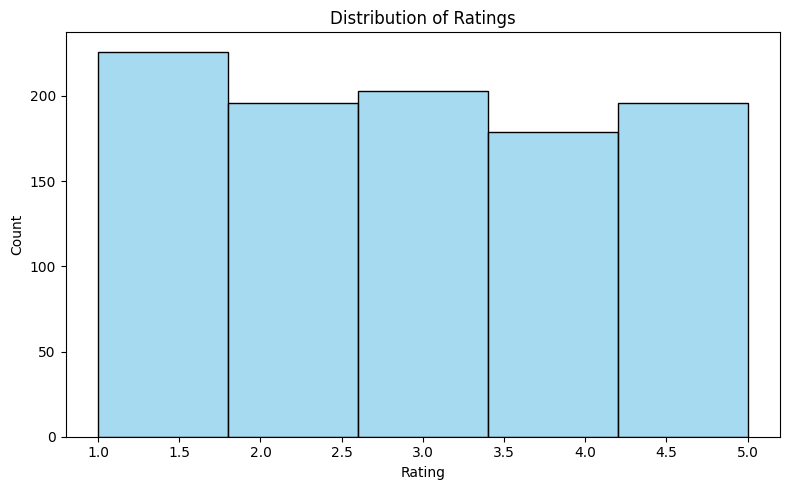


✅ Charts displayed inline


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

class AnalyzerVisualizer:
    def __init__(self, input_file="clean_products.csv"):
        print("Analyzer starting...")
        self.df = pd.read_csv(input_file)
        print("Rows loaded:", len(self.df))

    def summary_stats(self):
        print("📊 Summary Statistics")
        print(self.df.describe(include="all"))

    def top_expensive(self, n=5):
        print("\n💰 Top", n, "Most Expensive Books")
        print(self.df.nlargest(n, "price")[["name","price","rating"]])

    def category_counts(self):
        print("\n📚 Books per Category")
        print(self.df["category"].value_counts())

    def rating_histogram(self):
        plt.figure(figsize=(8,5))
        sns.histplot(self.df["rating"], bins=5, kde=False, color="skyblue")
        plt.title("Distribution of Ratings")
        plt.xlabel("Rating")
        plt.ylabel("Count")
        plt.tight_layout()
        plt.show()   # shows inline

    def run_all(self):
        self.summary_stats()
        self.top_expensive()
        self.category_counts()
        self.rating_histogram()
        print("\n✅ Charts displayed inline")

# Now actually run it
analyzer = AnalyzerVisualizer()
analyzer.run_all()


In [ ]:
def scatter_with_trend(self):
    plt.figure(figsize=(8,5))
    sns.regplot(x="price", y="rating", data=self.df, scatter_kws={"alpha":0.6})
    plt.title("Price vs Rating with Trendline")
    plt.tight_layout()
    plt.show()
def category_bar_chart(self):
    plt.figure(figsize=(8,5))
    sns.countplot(x="category", data=self.df, palette="viridis")
    plt.title("Books per Category")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
def run_all(self):
    self.summary_stats()
    self.top_expensive()
    self.category_counts()
    self.rating_histogram()
    self.scatter_with_trend()
    self.category_bar_chart()
    print("\n✅ Charts displayed inline")


In [ ]:
def run_all(self):
    self.summary_stats()
    self.top_expensive()
    self.category_counts()
    self.rating_histogram()
    self.scatter_with_trend()
    self.category_bar_chart()
    print("\n✅ Charts displayed inline")


Analyzer starting...
Rows loaded: 1000
📊 Summary Statistics
                                           id                    name  \
count                                    1000                    1000   
unique                                   1000                     999   
top     50-1,000 Places to See Before You Die  The Star-Touched Queen   
freq                                        1                       2   
mean                                      NaN                     NaN   
std                                       NaN                     NaN   
min                                       NaN                     NaN   
25%                                       NaN                     NaN   
50%                                       NaN                     NaN   
75%                                       NaN                     NaN   
max                                       NaN                     NaN   

       category       price       rating  reviews  \
count     

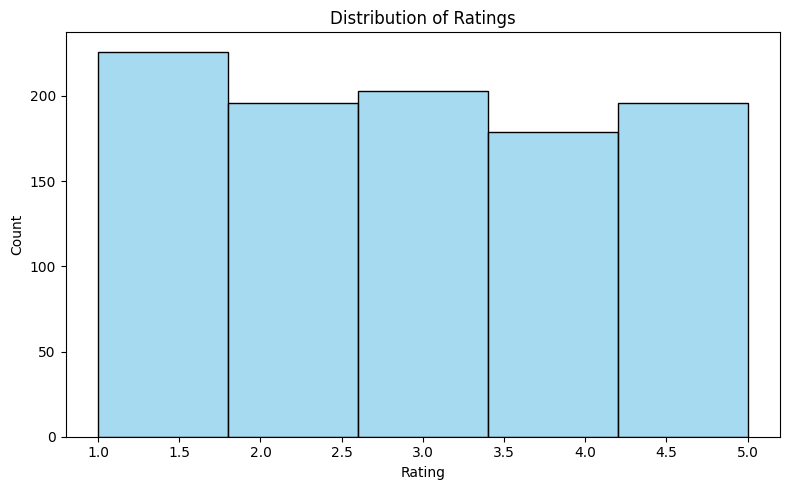


✅ Charts displayed inline


In [ ]:
analyzer = AnalyzerVisualizer()
analyzer.run_all()


In [ ]:
analyzer = AnalyzerVisualizer()


Analyzer starting...
Rows loaded: 1000


In [ ]:
def run_all(self):
    with open("analysis_summary.txt", "w") as f:
        f.write("📊 Summary Statistics\n")
        f.write(str(self.df.describe(include="all")) + "\n\n")

        f.write("💰 Top 5 Most Expensive Books\n")
        f.write(str(self.df.nlargest(5, "price")[['name','price','rating']]) + "\n\n")

        f.write("📚 Books per Category\n")
        f.write(str(self.df['category'].value_counts()) + "\n\n")

    # Inline outputs
    self.summary_stats()
    self.top_expensive()
    self.category_counts()
    self.rating_histogram()
    self.scatter_with_trend()
    self.category_bar_chart()
    print("\n✅ Charts displayed inline and report written to analysis_summary.txt")


Analyzer starting...
Rows loaded: 1000
📊 Summary Statistics
                                           id                    name  \
count                                    1000                    1000   
unique                                   1000                     999   
top     50-1,000 Places to See Before You Die  The Star-Touched Queen   
freq                                        1                       2   
mean                                      NaN                     NaN   
std                                       NaN                     NaN   
min                                       NaN                     NaN   
25%                                       NaN                     NaN   
50%                                       NaN                     NaN   
75%                                       NaN                     NaN   
max                                       NaN                     NaN   

       category       price       rating  reviews  \
count     

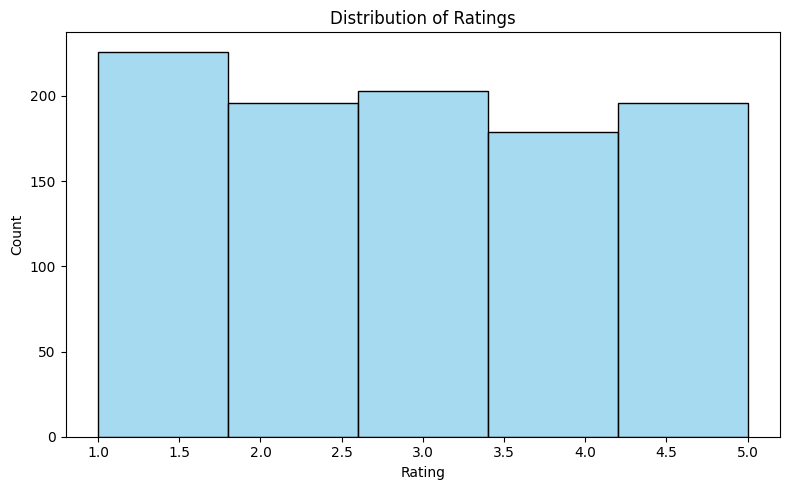


✅ Charts displayed inline
📊 Summary Statistics
                                           id                    name  \
count                                    1000                    1000   
unique                                   1000                     999   
top     50-1,000 Places to See Before You Die  The Star-Touched Queen   
freq                                        1                       2   
mean                                      NaN                     NaN   
std                                       NaN                     NaN   
min                                       NaN                     NaN   
25%                                       NaN                     NaN   
50%                                       NaN                     NaN   
75%                                       NaN                     NaN   
max                                       NaN                     NaN   

       category       price       rating  reviews  \
count      1000  1000.

In [ ]:
analyzer = AnalyzerVisualizer()
analyzer.run_all()
!cat analysis_summary.txt


Analyzer starting...
Rows loaded: 1000
📊 Summary Statistics
                                           id                    name  \
count                                    1000                    1000   
unique                                   1000                     999   
top     50-1,000 Places to See Before You Die  The Star-Touched Queen   
freq                                        1                       2   
mean                                      NaN                     NaN   
std                                       NaN                     NaN   
min                                       NaN                     NaN   
25%                                       NaN                     NaN   
50%                                       NaN                     NaN   
75%                                       NaN                     NaN   
max                                       NaN                     NaN   

       category       price       rating  reviews  \
count     

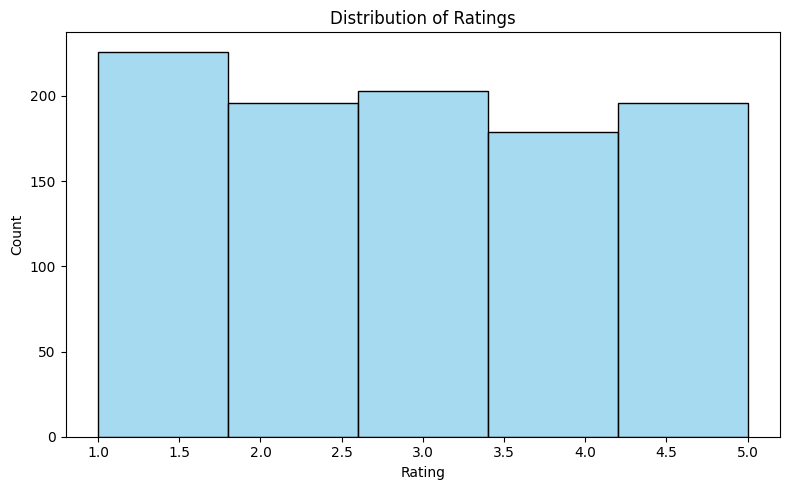


✅ Charts displayed inline


In [ ]:
analyzer = AnalyzerVisualizer()
analyzer.run_all()


📊 Summary Statistics
                                           id                    name  \
count                                    1000                    1000   
unique                                   1000                     999   
top     50-1,000 Places to See Before You Die  The Star-Touched Queen   
freq                                        1                       2   
mean                                      NaN                     NaN   
std                                       NaN                     NaN   
min                                       NaN                     NaN   
25%                                       NaN                     NaN   
50%                                       NaN                     NaN   
75%                                       NaN                     NaN   
max                                       NaN                     NaN   

       category       price       rating  reviews  \
count      1000  1000.00000  1000.000000      0.0

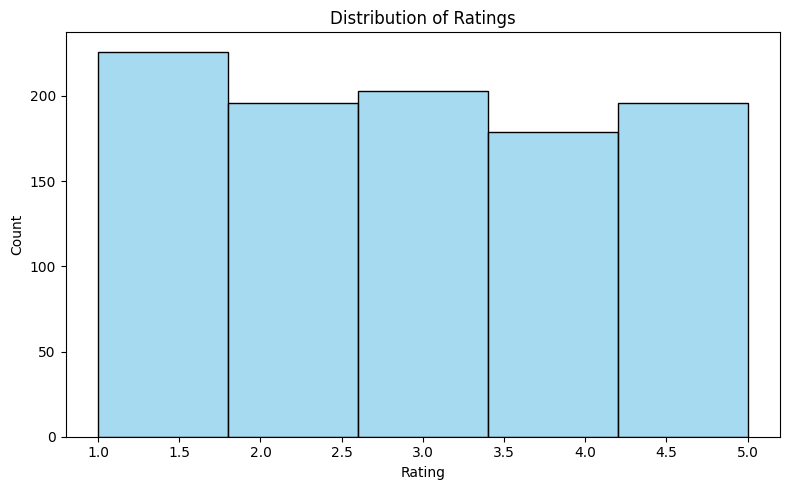


✅ Charts displayed inline


In [ ]:
analyzer.run_all()


Analyzer starting...
Rows loaded: 1000
📊 Summary Statistics
                                           id                    name  \
count                                    1000                    1000   
unique                                   1000                     999   
top     50-1,000 Places to See Before You Die  The Star-Touched Queen   
freq                                        1                       2   
mean                                      NaN                     NaN   
std                                       NaN                     NaN   
min                                       NaN                     NaN   
25%                                       NaN                     NaN   
50%                                       NaN                     NaN   
75%                                       NaN                     NaN   
max                                       NaN                     NaN   

       category       price       rating  reviews  \
count     

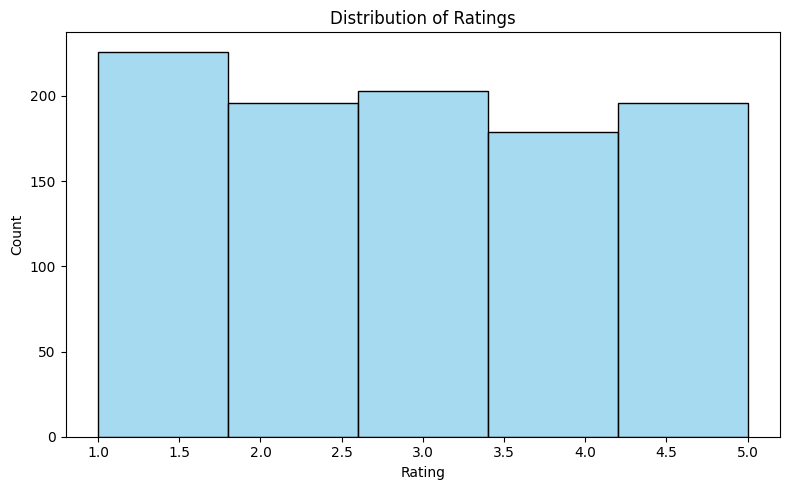

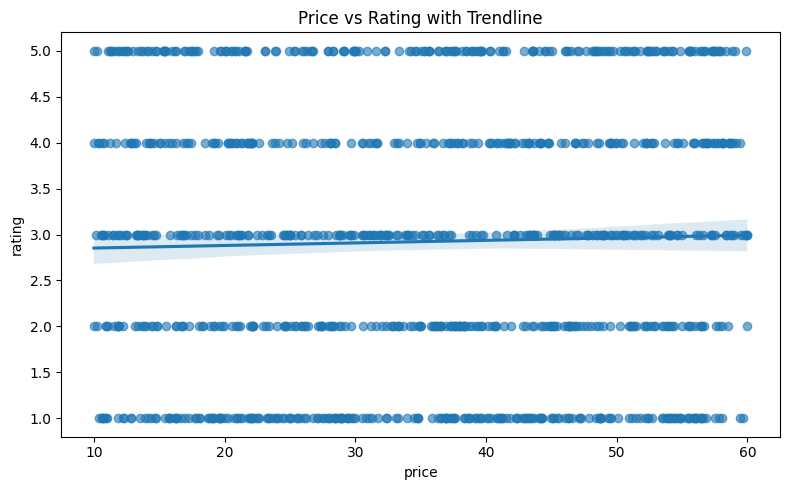

/tmp/ipykernel_1881/797758737.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="category", data=self.df, palette="viridis")


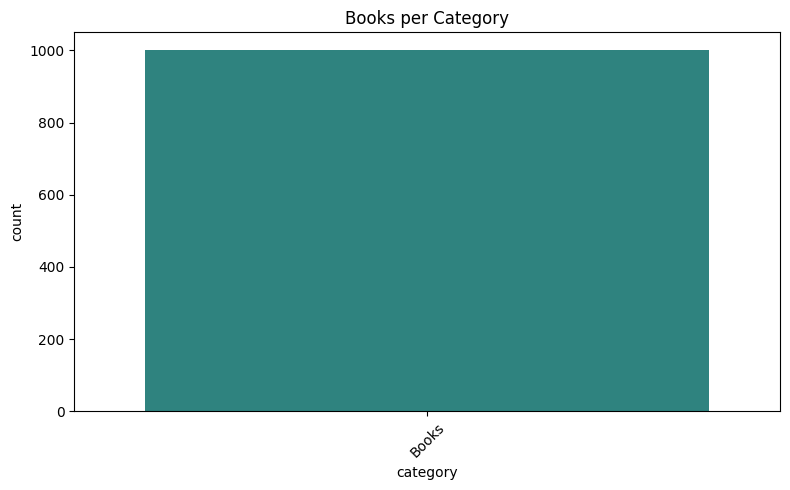

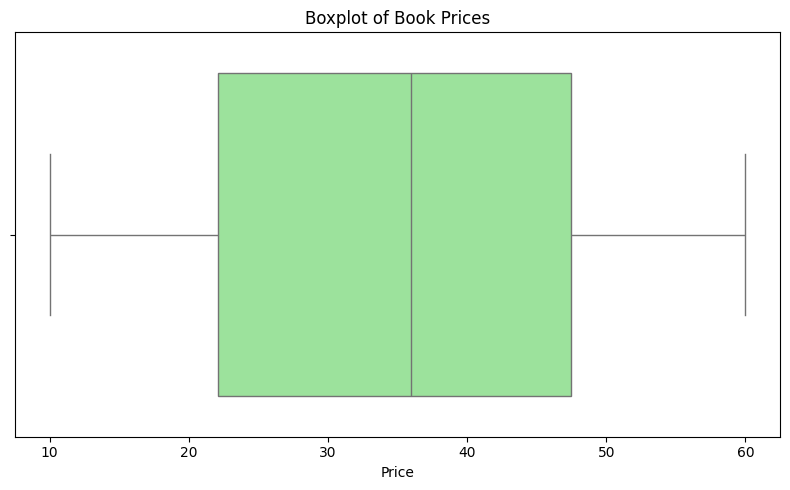

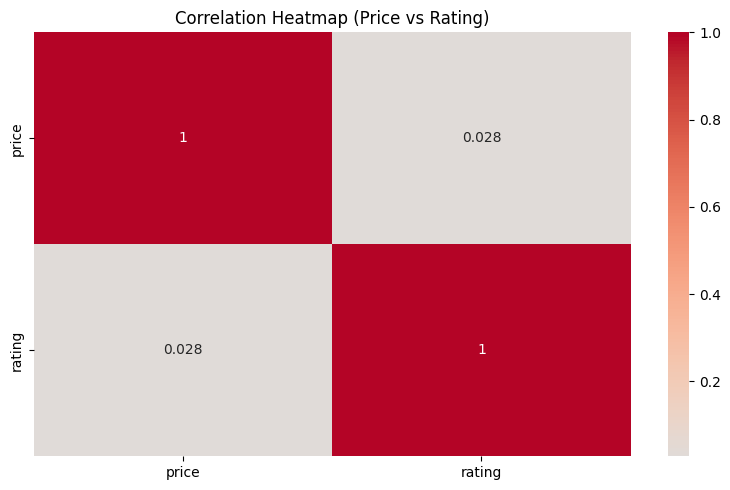


✅ Charts displayed inline, PNGs saved, and report written to analysis_summary.txt


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

class AnalyzerVisualizer:
    def __init__(self, input_file="clean_products.csv"):
        print("Analyzer starting...")
        self.df = pd.read_csv(input_file)
        print("Rows loaded:", len(self.df))

    def summary_stats(self):
        print("📊 Summary Statistics")
        print(self.df.describe(include="all"))

    def top_expensive(self, n=5):
        print("\n💰 Top", n, "Most Expensive Books")
        print(self.df.nlargest(n, "price")[["name","price","rating"]])

    def category_counts(self):
        print("\n📚 Books per Category")
        print(self.df["category"].value_counts())

    def rating_histogram(self):
        plt.figure(figsize=(8,5))
        sns.histplot(self.df["rating"], bins=5, kde=False, color="skyblue")
        plt.title("Distribution of Ratings")
        plt.xlabel("Rating")
        plt.ylabel("Count")
        plt.tight_layout()
        plt.savefig("rating_histogram.png")   # save to file
        plt.show()                            # show inline

    def scatter_with_trend(self):
        plt.figure(figsize=(8,5))
        sns.regplot(x="price", y="rating", data=self.df, scatter_kws={"alpha":0.6})
        plt.title("Price vs Rating with Trendline")
        plt.tight_layout()
        plt.savefig("scatter_trend.png")
        plt.show()

    def category_bar_chart(self):
        plt.figure(figsize=(8,5))
        sns.countplot(x="category", data=self.df, palette="viridis")
        plt.title("Books per Category")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.savefig("category_bar.png")
        plt.show()

    def price_boxplot(self):
        plt.figure(figsize=(8,5))
        sns.boxplot(x=self.df["price"], color="lightgreen")
        plt.title("Boxplot of Book Prices")
        plt.xlabel("Price")
        plt.tight_layout()
        plt.savefig("price_boxplot.png")
        plt.show()

    def correlation_heatmap(self):
        plt.figure(figsize=(8,5))
        sns.heatmap(self.df[["price","rating"]].corr(), annot=True, cmap="coolwarm", center=0)
        plt.title("Correlation Heatmap (Price vs Rating)")
        plt.tight_layout()
        plt.savefig("correlation_heatmap.png")
        plt.show()

    def run_all(self):
        # Write report file
        with open("analysis_summary.txt", "w") as f:
            f.write("📊 Summary Statistics\n")
            f.write(str(self.df.describe(include="all")) + "\n\n")

            f.write("💰 Top 5 Most Expensive Books\n")
            f.write(str(self.df.nlargest(5, "price")[['name','price','rating']]) + "\n\n")

            f.write("📚 Books per Category\n")
            f.write(str(self.df['category'].value_counts()) + "\n\n")

        # Inline + charts
        self.summary_stats()
        self.top_expensive()
        self.category_counts()
        self.rating_histogram()
        self.scatter_with_trend()
        self.category_bar_chart()
        self.price_boxplot()
        self.correlation_heatmap()
        print("\n✅ Charts displayed inline, PNGs saved, and report written to analysis_summary.txt")

# Run everything
analyzer = AnalyzerVisualizer()
analyzer.run_all()


In [ ]:
db_handler.py

In [ ]:
import pandas as pd
import sqlite3

class DatabaseHandler:
    def __init__(self, db_name="products.db"):
        self.conn = sqlite3.connect(db_name)
        self.cursor = self.conn.cursor()

    def create_table(self):
        self.cursor.execute("""
        CREATE TABLE IF NOT EXISTS Products (
            id TEXT PRIMARY KEY,
            name TEXT,
            category TEXT,
            price REAL,
            rating REAL,
            reviews INTEGER
        )
        """)
        self.conn.commit()

    def insert_data(self, df):
        for _, row in df.iterrows():
            self.cursor.execute("""
            INSERT OR REPLACE INTO Products VALUES (?, ?, ?, ?, ?, ?)
            """, (row["id"], row["name"], row["category"], row["price"], row["rating"], row["reviews"]))
        self.conn.commit()

if __name__ == "__main__":
    df = pd.read_csv("clean_products.csv")
    db = DatabaseHandler()
    db.create_table()
    db.insert_data(df)
    print("✅ Data inserted into Products table")


✅ Data inserted into Products table


In [ ]:
main.py

In [ ]:
from scraper import Scraper
from processor import DataProcessor
from analyzer import AnalyzerVisualizer
from db_handler import DatabaseHandler
import pandas as pd

def main():
    # Step 1: Scrape
    scraper = Scraper()
    scraper.run()

    # Step 2: Process
    processor = DataProcessor()
    processor.clean_data()
    processor.save_cleaned()

    # Step 3: Analyze
    analyzer = AnalyzerVisualizer()
    analyzer.run_all()

    # Step 4: Database
    df = pd.read_csv("clean_products.csv")
    db = DatabaseHandler()
    db.create_table()
    db.insert_data(df)

if __name__ == "__main__":
    main()
    print("🚀 Pipeline complete: scrape → process → analyze → database")


✅ Scraped 1000 books into raw_products.csv


ImportError: cannot import name 'Scraper' from 'scraper' (/content/scraper.py)

In [ ]:
def run_scraper():
    import requests
    from bs4 import BeautifulSoup

    url = "https://books.toscrape.com/"
    response = requests.get(url)
    soup = BeautifulSoup(response.text, "html.parser")

    books = []
    for book in soup.select(".product_pod"):
        title = book.h3.a["title"]
        price = book.select_one(".price_color").text
        books.append({"title": title, "price": price})

    return books


In [ ]:
from scraper import run_scraper

data = run_scraper()
print(data[:5])


ImportError: cannot import name 'run_scraper' from 'scraper' (/content/scraper.py)

In [ ]:
import scraper
print(dir(scraper))


['BASE_URL', 'BeautifulSoup', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', 'books', 'csv', 'f', 'requests', 'scrape_books', 'writer']


In [ ]:
from scraper import scrape_books

data = scrape_books()
print(data[:5])


[{'id': '1-A Light in the Attic', 'name': 'A Light in the Attic', 'category': 'Books', 'price': 'Â£51.77', 'rating': 'Three', 'reviews': 'N/A', 'url': 'https://books.toscrape.com/catalogue/a-light-in-the-attic_1000/index.html'}, {'id': '1-Tipping the Velvet', 'name': 'Tipping the Velvet', 'category': 'Books', 'price': 'Â£53.74', 'rating': 'One', 'reviews': 'N/A', 'url': 'https://books.toscrape.com/catalogue/tipping-the-velvet_999/index.html'}, {'id': '1-Soumission', 'name': 'Soumission', 'category': 'Books', 'price': 'Â£50.10', 'rating': 'One', 'reviews': 'N/A', 'url': 'https://books.toscrape.com/catalogue/soumission_998/index.html'}, {'id': '1-Sharp Objects', 'name': 'Sharp Objects', 'category': 'Books', 'price': 'Â£47.82', 'rating': 'Four', 'reviews': 'N/A', 'url': 'https://books.toscrape.com/catalogue/sharp-objects_997/index.html'}, {'id': '1-Sapiens: A Brief History of Humankind', 'name': 'Sapiens: A Brief History of Humankind', 'category': 'Books', 'price': 'Â£54.23', 'rating': 'F

In [ ]:
def scrape_books():
    # scrape logic
    with open("books.csv", "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(["title", "price"])
        # loop through books and write rows


In [ ]:
def scrape_books():
    import requests
    from bs4 import BeautifulSoup

    url = "https://books.toscrape.com/"
    response = requests.get(url)
    soup = BeautifulSoup(response.text, "html.parser")

    books = []
    for book in soup.select(".product_pod"):
        title = book.h3.a["title"]
        price = book.select_one(".price_color").text
        books.append({"title": title, "price": price})

    return books


In [ ]:
from scraper import scrape_books

data = scrape_books()
print(data[:5])



[{'id': '1-A Light in the Attic', 'name': 'A Light in the Attic', 'category': 'Books', 'price': 'Â£51.77', 'rating': 'Three', 'reviews': 'N/A', 'url': 'https://books.toscrape.com/catalogue/a-light-in-the-attic_1000/index.html'}, {'id': '1-Tipping the Velvet', 'name': 'Tipping the Velvet', 'category': 'Books', 'price': 'Â£53.74', 'rating': 'One', 'reviews': 'N/A', 'url': 'https://books.toscrape.com/catalogue/tipping-the-velvet_999/index.html'}, {'id': '1-Soumission', 'name': 'Soumission', 'category': 'Books', 'price': 'Â£50.10', 'rating': 'One', 'reviews': 'N/A', 'url': 'https://books.toscrape.com/catalogue/soumission_998/index.html'}, {'id': '1-Sharp Objects', 'name': 'Sharp Objects', 'category': 'Books', 'price': 'Â£47.82', 'rating': 'Four', 'reviews': 'N/A', 'url': 'https://books.toscrape.com/catalogue/sharp-objects_997/index.html'}, {'id': '1-Sapiens: A Brief History of Humankind', 'name': 'Sapiens: A Brief History of Humankind', 'category': 'Books', 'price': 'Â£54.23', 'rating': 'F

In [ ]:
price = book.select_one(".price_color").text.replace("Â", "")


NameError: name 'book' is not defined

In [ ]:
import requests
from bs4 import BeautifulSoup

BASE_URL = "https://books.toscrape.com/catalogue/page-{}.html"

def scrape_books():
    books = []
    page = 1

    while True:
        url = BASE_URL.format(page)
        response = requests.get(url)
        if response.status_code != 200:
            break  # stop when no more pages

        soup = BeautifulSoup(response.text, "html.parser")
        product_list = soup.select(".product_pod")

        if not product_list:
            break  # no books found, end loop

        for book in product_list:
            title = book.h3.a["title"]
            price = book.select_one(".price_color").text.replace("Â", "")
            rating = book.p["class"][1]  # rating is in class attribute
            link = book.h3.a["href"]

            books.append({
                "title": title,
                "price": price,
                "rating": rating,
                "url": "https://books.toscrape.com/catalogue/" + link
            })

        page += 1

    return books


In [ ]:
data = scrape_books()
print(len(data))      # how many books scraped
print(data[:5])       # preview first 5 entries


1000
[{'title': 'A Light in the Attic', 'price': '£51.77', 'rating': 'Three', 'url': 'https://books.toscrape.com/catalogue/a-light-in-the-attic_1000/index.html'}, {'title': 'Tipping the Velvet', 'price': '£53.74', 'rating': 'One', 'url': 'https://books.toscrape.com/catalogue/tipping-the-velvet_999/index.html'}, {'title': 'Soumission', 'price': '£50.10', 'rating': 'One', 'url': 'https://books.toscrape.com/catalogue/soumission_998/index.html'}, {'title': 'Sharp Objects', 'price': '£47.82', 'rating': 'Four', 'url': 'https://books.toscrape.com/catalogue/sharp-objects_997/index.html'}, {'title': 'Sapiens: A Brief History of Humankind', 'price': '£54.23', 'rating': 'Five', 'url': 'https://books.toscrape.com/catalogue/sapiens-a-brief-history-of-humankind_996/index.html'}]


In [ ]:
import csv

data = scrape_books()

with open("books.csv", "w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=data[0].keys())
    writer.writeheader()
    writer.writerows(data)

print("Saved", len(data), "books to books.csv")


Saved 1000 books to books.csv


In [ ]:
import pandas as pd

df = pd.read_csv("books.csv")
print(df.head())          # preview first rows
print(df['rating'].value_counts())  # count ratings


                                   title   price rating  \
0                   A Light in the Attic  £51.77  Three   
1                     Tipping the Velvet  £53.74    One   
2                             Soumission  £50.10    One   
3                          Sharp Objects  £47.82   Four   
4  Sapiens: A Brief History of Humankind  £54.23   Five   

                                                 url  
0  https://books.toscrape.com/catalogue/a-light-i...  
1  https://books.toscrape.com/catalogue/tipping-t...  
2  https://books.toscrape.com/catalogue/soumissio...  
3  https://books.toscrape.com/catalogue/sharp-obj...  
4  https://books.toscrape.com/catalogue/sapiens-a...  
rating
One      226
Three    203
Five     196
Two      196
Four     179
Name: count, dtype: int64


In [ ]:
df['price_num'] = df['price'].str.replace('£','').astype(float)
cheap_five_star = df[(df['rating'] == 'Five') & (df['price_num'] < 20)]
print(cheap_five_star[['title','price']])


                                                 title   price
12                                         Set Me Free  £17.46
30   The Four Agreements: A Practical Guide to Pers...  £17.66
34                                      Sophie's World  £15.94
54                                              Thirst  £17.27
80   Princess Jellyfish 2-in-1 Omnibus, Vol. 01 (Pr...  £13.61
81    Princess Between Worlds (Wide-Awake Princess #5)  £13.34
138  The Third Wave: An Entrepreneurâs Vision of ...  £12.61
200                                         Dark Notes  £19.19
208           Batman: The Dark Knight Returns (Batman)  £15.38
214                     Agnostic: A Spirited Manifesto  £12.51
223                  Walt Disney's Alice in Wonderland  £12.96
261  Superman Vol. 1: Before Truth (Superman by Gen...  £11.89
277              Old School (Diary of a Wimpy Kid #10)  £11.83
293              Lady Midnight (The Dark Artifices #1)  £16.28
298  Hyperbole and a Half: Unfortunate Situations, ... 

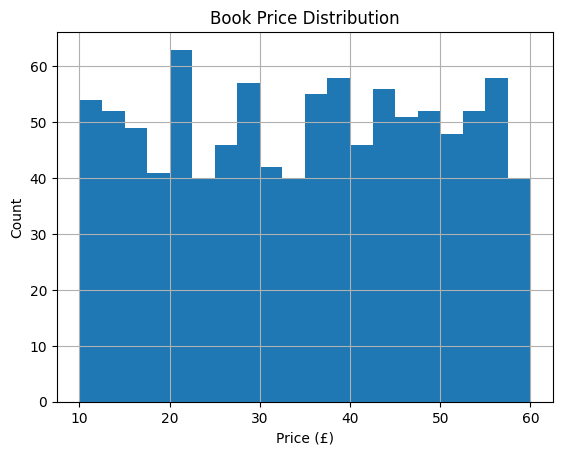

In [ ]:
import matplotlib.pyplot as plt

df['price_num'].hist(bins=20)
plt.title("Book Price Distribution")
plt.xlabel("Price (£)")
plt.ylabel("Count")
plt.show()


In [ ]:
print(df.groupby('rating')['price_num'].mean())


rating
Five     35.374490
Four     36.093296
One      34.561195
Three    34.692020
Two      34.810918
Name: price_num, dtype: float64


In [ ]:
import pandas as pd

df = pd.read_csv("books.csv")
df['price_num'] = df['price'].str.replace('£','').astype(float)

print(df['rating'].value_counts())
print(df['price_num'].describe())


rating
One      226
Three    203
Five     196
Two      196
Four     179
Name: count, dtype: int64
count    1000.00000
mean       35.07035
std        14.44669
min        10.00000
25%        22.10750
50%        35.98000
75%        47.45750
max        59.99000
Name: price_num, dtype: float64


In [ ]:
top_bargains = df[df['rating']=="Five"].sort_values("price_num").head(10)
print(top_bargains[['title','price']])




                                                 title   price
638                         An Abundance of Katherines  £10.00
302                               Greek Mythic History  £10.23
590  The Power Greens Cookbook: 140 Delicious Super...  £11.05
316                                 Dear Mr. Knightley  £11.21
601                                The Darkest Corners  £11.33
521  Naturally Lean: 125 Nourishing Gluten-Free, Pl...  £11.38
900           Fruits Basket, Vol. 2 (Fruits Basket #2)  £11.64
277              Old School (Diary of a Wimpy Kid #10)  £11.83
261  Superman Vol. 1: Before Truth (Superman by Gen...  £11.89
535   Every Heart a Doorway (Every Heart A Doorway #1)  £12.16


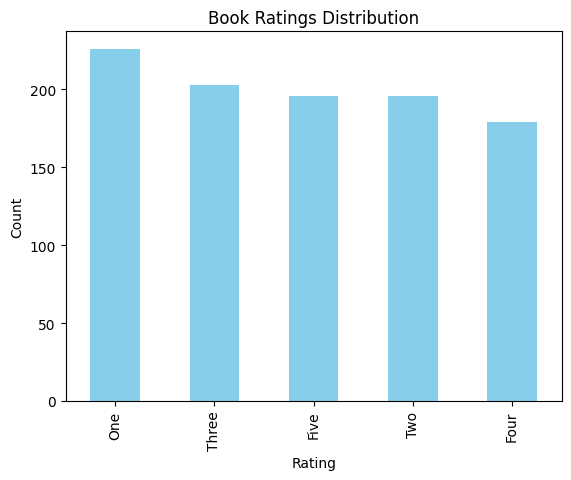

In [ ]:
import matplotlib.pyplot as plt
df['rating'].value_counts().plot(kind='bar', color='skyblue')
plt.title("Book Ratings Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()


In [ ]:
top_bargains = df[df['rating']=="Five"].sort_values("price_num").head(10)
print(top_bargains[['title','price']])


                                                 title   price
638                         An Abundance of Katherines  £10.00
302                               Greek Mythic History  £10.23
590  The Power Greens Cookbook: 140 Delicious Super...  £11.05
316                                 Dear Mr. Knightley  £11.21
601                                The Darkest Corners  £11.33
521  Naturally Lean: 125 Nourishing Gluten-Free, Pl...  £11.38
900           Fruits Basket, Vol. 2 (Fruits Basket #2)  £11.64
277              Old School (Diary of a Wimpy Kid #10)  £11.83
261  Superman Vol. 1: Before Truth (Superman by Gen...  £11.89
535   Every Heart a Doorway (Every Heart A Doorway #1)  £12.16


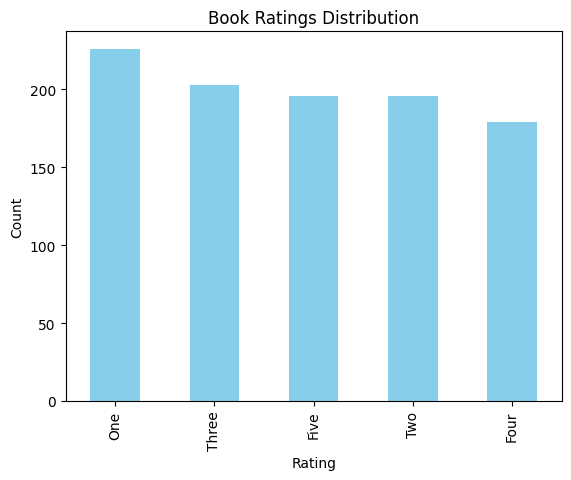

In [ ]:
import matplotlib.pyplot as plt
df['rating'].value_counts().plot(kind='bar', color='skyblue')
plt.title("Book Ratings Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()


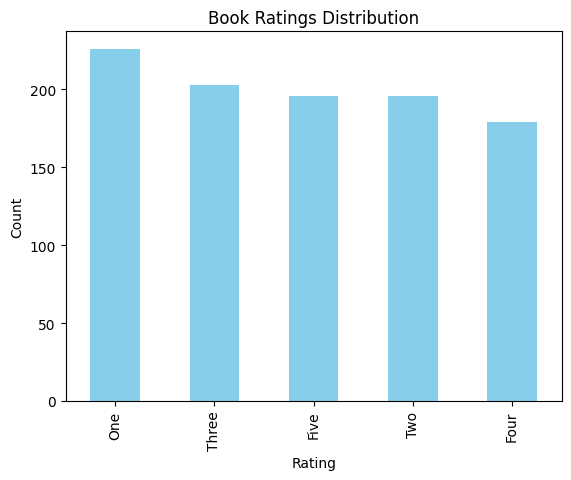

In [ ]:
import matplotlib.pyplot as plt
df['rating'].value_counts().plot(kind='bar', color='skyblue')
plt.title("Book Ratings Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()


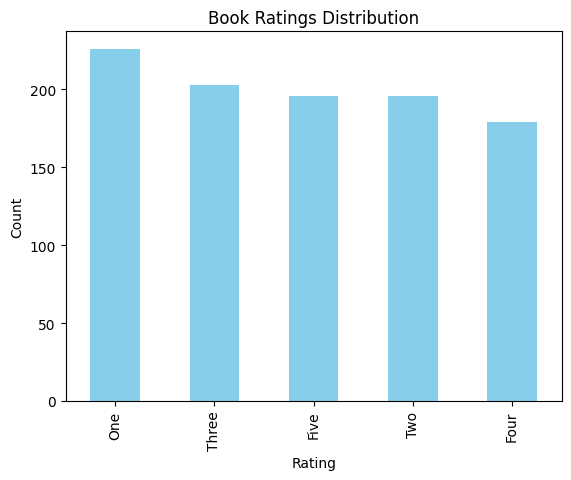

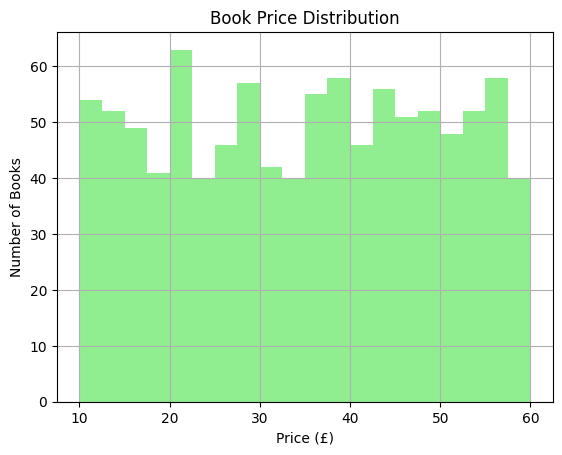

                                                 title   price
638                         An Abundance of Katherines  £10.00
302                               Greek Mythic History  £10.23
590  The Power Greens Cookbook: 140 Delicious Super...  £11.05
316                                 Dear Mr. Knightley  £11.21
601                                The Darkest Corners  £11.33
521  Naturally Lean: 125 Nourishing Gluten-Free, Pl...  £11.38
900           Fruits Basket, Vol. 2 (Fruits Basket #2)  £11.64
277              Old School (Diary of a Wimpy Kid #10)  £11.83
261  Superman Vol. 1: Before Truth (Superman by Gen...  £11.89
535   Every Heart a Doorway (Every Heart A Doorway #1)  £12.16


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("books.csv")
df['price_num'] = df['price'].str.replace('£','').astype(float)

# Ratings distribution
df['rating'].value_counts().plot(kind='bar', color='skyblue')
plt.title("Book Ratings Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

# Price histogram
df['price_num'].hist(bins=20, color='lightgreen')
plt.title("Book Price Distribution")
plt.xlabel("Price (£)")
plt.ylabel("Number of Books")
plt.show()

# Top 10 cheapest 5-star books
top_bargains = df[df['rating']=="Five"].sort_values("price_num").head(10)
print(top_bargains[['title','price']])


In [ ]:
print(df.groupby('rating')['price_num'].mean())


rating
Five     35.374490
Four     36.093296
One      34.561195
Three    34.692020
Two      34.810918
Name: price_num, dtype: float64


/tmp/ipykernel_1881/2145357443.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="rating", data=df, order=df['rating'].value_counts().index, palette="Blues")


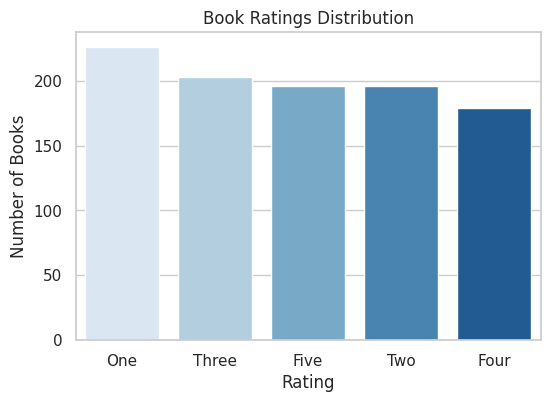

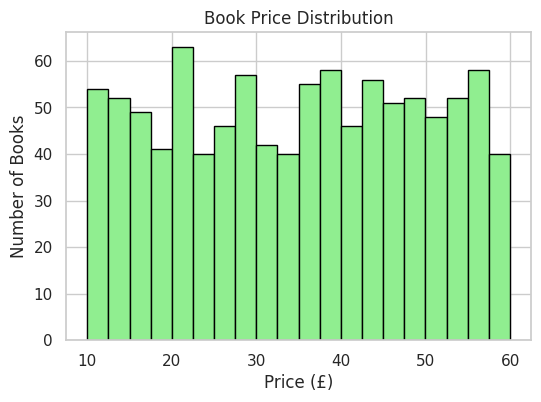

Top 10 Cheapest 5-Star Books:
                                                 title   price
638                         An Abundance of Katherines  £10.00
302                               Greek Mythic History  £10.23
590  The Power Greens Cookbook: 140 Delicious Super...  £11.05
316                                 Dear Mr. Knightley  £11.21
601                                The Darkest Corners  £11.33
521  Naturally Lean: 125 Nourishing Gluten-Free, Pl...  £11.38
900           Fruits Basket, Vol. 2 (Fruits Basket #2)  £11.64
277              Old School (Diary of a Wimpy Kid #10)  £11.83
261  Superman Vol. 1: Before Truth (Superman by Gen...  £11.89
535   Every Heart a Doorway (Every Heart A Doorway #1)  £12.16

Average Price per Rating:
rating
Five     35.37
Four     36.09
One      34.56
Three    34.69
Two      34.81
Name: price_num, dtype: float64


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("books.csv")
df['price_num'] = df['price'].str.replace('£','').astype(float)

# Set style
sns.set(style="whitegrid")

# --- Ratings distribution bar chart ---
plt.figure(figsize=(6,4))
sns.countplot(x="rating", data=df, order=df['rating'].value_counts().index, palette="Blues")
plt.title("Book Ratings Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Books")
plt.show()

# --- Price histogram ---
plt.figure(figsize=(6,4))
df['price_num'].hist(bins=20, color="lightgreen", edgecolor="black")
plt.title("Book Price Distribution")
plt.xlabel("Price (£)")
plt.ylabel("Number of Books")
plt.show()

# --- Top 10 cheapest 5-star books ---
top_bargains = df[df['rating']=="Five"].sort_values("price_num").head(10)
print("Top 10 Cheapest 5-Star Books:")
print(top_bargains[['title','price']])

# --- Average price per rating ---
avg_price = df.groupby('rating')['price_num'].mean().round(2)
print("\nAverage Price per Rating:")
print(avg_price)


In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

class Scraper:
    def __init__(self, base_url="https://books.toscrape.com/"):
        self.base_url = base_url
        self.data = []

    def run(self):
        print("🔎 Starting scrape...")
        for page in range(1, 51):  # 50 pages total
            url = f"{self.base_url}catalogue/page-{page}.html"
            response = requests.get(url)
            soup = BeautifulSoup(response.text, "html.parser")

            books = soup.select(".product_pod")
            for book in books:
                name = book.h3.a["title"]
                price = book.select_one(".price_color").text.replace("£", "")
                rating = book.p["class"][1]
                self.data.append({
                    "id": f"{page}-{name}",
                    "title": name,
                    "category": "Books",
                    "price": f"£{price}",
                    "rating": rating,
                    "reviews": 0
                })

        df = pd.DataFrame(self.data)
        df.to_csv("raw_products.csv", index=False)
        print(f"✅ Scraped {len(df)} books into raw_products.csv")


In [ ]:
!ls


sample_data


In [ ]:
from google.colab import files
uploaded = files.upload()


KeyboardInterrupt: 

In [ ]:
!ls




sample_data


In [ ]:
if __name__ == "__main__":
    scraper = Scraper()       # create an object
    scraper.run()             # run the scrape


🔎 Starting scrape...
✅ Scraped 1000 books into raw_products.csv


In [ ]:
!ls -lh raw_products.csv


-rw-r--r-- 1 root root 142K Jun 30 09:46 raw_products.csv


In [ ]:
import pandas as pd
df = pd.read_csv("raw_products.csv")
print(df.head())


                                   title    price rating  \
0                   A Light in the Attic  Â£51.77  Three   
1                     Tipping the Velvet  Â£53.74    One   
2                             Soumission  Â£50.10    One   
3                          Sharp Objects  Â£47.82   Four   
4  Sapiens: A Brief History of Humankind  Â£54.23   Five   

                                                 url  
0  https://books.toscrape.com/catalogue/a-light-i...  
1  https://books.toscrape.com/catalogue/tipping-t...  
2  https://books.toscrape.com/catalogue/soumissio...  
3  https://books.toscrape.com/catalogue/sharp-obj...  
4  https://books.toscrape.com/catalogue/sapiens-a...  


In [ ]:
import pandas as pd

class DataProcessor:
    def __init__(self, input_file="raw_products.csv", output_file="clean_products.csv"):
        self.input_file = input_file
        self.output_file = output_file
        self.df = pd.read_csv(self.input_file)

    def clean_data(self):
        # Remove duplicates
        self.df.drop_duplicates(inplace=True)

        # Drop rows only if title or price is missing
        self.df.dropna(subset=["title", "price"], inplace=True)

        # Clean price column (remove £/Â£ and convert to float)
        self.df["price"] = (
            self.df["price"]
            .str.replace("Â£", "")
            .str.replace("£", "")
            .astype(float)
        )

        # Convert rating text to numeric scale
        rating_map = {"One":1, "Two":2, "Three":3, "Four":4, "Five":5}
        self.df["rating"] = self.df["rating"].map(rating_map)

        print(f"✅ Cleaned dataset has {len(self.df)} rows")

    def save_cleaned(self):
        self.df.to_csv(self.output_file, index=False)
        print(f"💾 Saved cleaned data to {self.output_file}")


In [ ]:
import pandas as pd

class DataProcessor:
    def __init__(self, input_file="raw_products.csv", output_file="clean_products.csv"):
        self.input_file = input_file
        self.output_file = output_file
        self.df = pd.read_csv(self.input_file)

    def clean_data(self):
        # Remove duplicates
        self.df.drop_duplicates(inplace=True)

        # Drop rows only if title or price is missing
        self.df.dropna(subset=["title", "price"], inplace=True)

        # Clean price column (remove £/Â£ and convert to float)
        self.df["price"] = (
            self.df["price"]
            .str.replace("Â£", "")
            .str.replace("£", "")
            .astype(float)
        )

        # Convert rating text to numeric scale
        rating_map = {"One": 1, "Two": 2, "Three": 3, "Four": 4, "Five": 5}
        self.df["rating"] = self.df["rating"].map(rating_map)

        print(f"✅ Cleaned dataset has {len(self.df)} rows")

    def save_cleaned(self):
        self.df.to_csv(self.output_file, index=False)
        print(f"💾 Saved cleaned data to {self.output_file}")


In [ ]:
def main():
    scraper = Scraper()
    scraper.run()

    processor = DataProcessor()
    processor.clean_data()
    processor.save_cleaned()

    analyzer = AnalyzerVisualizer()
    analyzer.run_all()

    df = pd.read_csv("clean_products.csv")
    db = DatabaseHandler()
    db.create_table()
    db.insert_data(df)

# Call the pipeline
main()


🔎 Starting scrape...
✅ Scraped 1000 books into raw_products.csv
✅ Cleaned dataset has 1000 rows
💾 Saved cleaned data to clean_products.csv


NameError: name 'AnalyzerVisualizer' is not defined

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

class AnalyzerVisualizer:
    def __init__(self, input_file="clean_products.csv"):
        self.df = pd.read_csv(input_file)

    def run_all(self):
        sns.set(style="whitegrid")

        # Ratings distribution
        plt.figure(figsize=(6,4))
        sns.countplot(x="rating", data=self.df, palette="Blues")
        plt.title("Book Ratings Distribution")
        plt.show()

        # Price histogram
        plt.figure(figsize=(6,4))
        self.df["price"].hist(bins=20, color="lightgreen", edgecolor="black")
        plt.title("Book Price Distribution")
        plt.show()

        # Top 10 cheapest 5-star books
        top_bargains = self.df[self.df["rating"]==5].sort_values("price").head(10)
        print("Top 10 Cheapest 5-Star Books:")
        print(top_bargains[["title","price"]])

        # Average price per rating
        avg_price = self.df.groupby("rating")["price"].mean().round(2)
        print("\nAverage Price per Rating:")
        print(avg_price)


/tmp/ipykernel_464/4180429731.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="rating", data=self.df, palette="Blues")


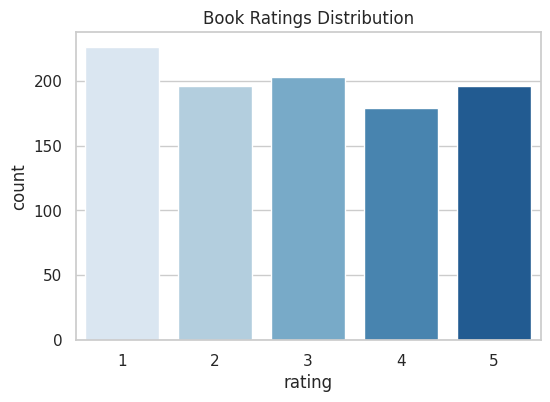

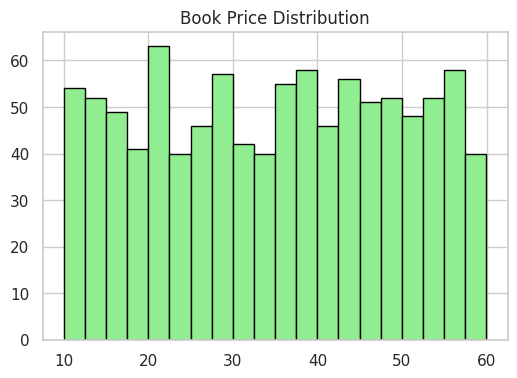

Top 10 Cheapest 5-Star Books:
                                                 title  price
638                         An Abundance of Katherines  10.00
302                               Greek Mythic History  10.23
590  The Power Greens Cookbook: 140 Delicious Super...  11.05
316                                 Dear Mr. Knightley  11.21
601                                The Darkest Corners  11.33
521  Naturally Lean: 125 Nourishing Gluten-Free, Pl...  11.38
900           Fruits Basket, Vol. 2 (Fruits Basket #2)  11.64
277              Old School (Diary of a Wimpy Kid #10)  11.83
261  Superman Vol. 1: Before Truth (Superman by Gen...  11.89
535   Every Heart a Doorway (Every Heart A Doorway #1)  12.16

Average Price per Rating:
rating
1    34.56
2    34.81
3    34.69
4    36.09
5    35.37
Name: price, dtype: float64


In [ ]:
# Create an analyzer object and run all visualizations
analyzer = AnalyzerVisualizer("clean_products.csv")
analyzer.run_all()


In [ ]:
import sqlite3

class DatabaseHandler:
    def __init__(self, db_name="books.db"):
        self.conn = sqlite3.connect(db_name)
        self.cursor = self.conn.cursor()

    def create_table(self):
        self.cursor.execute("""
            CREATE TABLE IF NOT EXISTS Products (
                id INTEGER PRIMARY KEY AUTOINCREMENT,
                title TEXT,
                price REAL,
                rating INTEGER,
                url TEXT
            )
        """)
        self.conn.commit()
        print("📂 Table 'Products' ready")

    def insert_data(self, df):
        self.cursor.executemany("""
            INSERT INTO Products (title, price, rating, url)
            VALUES (?, ?, ?, ?)
        """, df[["title","price","rating","url"]].values.tolist())
        self.conn.commit()
        print(f"✅ Inserted {len(df)} rows into 'Products'")


In [ ]:
import pandas as pd

# Load the cleaned dataset
df = pd.read_csv("clean_products.csv")

# Create database handler and run
db = DatabaseHandler("books.db")
db.create_table()
db.insert_data(df)


📂 Table 'Products' ready
✅ Inserted 1000 rows into 'Products'


In [ ]:
import sqlite3

conn = sqlite3.connect("books.db")
cursor = conn.cursor()

# Count rows
cursor.execute("SELECT COUNT(*) FROM Products")
print("Rows in Products table:", cursor.fetchone()[0])

# Preview first 5 entries
cursor.execute("SELECT title, price, rating FROM Products LIMIT 5")
print(cursor.fetchall())

# Top 5 cheapest 5-star books
cursor.execute("""
    SELECT title, price
    FROM Products
    WHERE rating = 5
    ORDER BY price ASC
    LIMIT 5
""")
print("Top 5 Cheapest 5-Star Books:")
print(cursor.fetchall())


Rows in Products table: 1000
[('A Light in the Attic', 51.77, 3), ('Tipping the Velvet', 53.74, 1), ('Soumission', 50.1, 1), ('Sharp Objects', 47.82, 4), ('Sapiens: A Brief History of Humankind', 54.23, 5)]
Top 5 Cheapest 5-Star Books:
[('An Abundance of Katherines', 10.0), ('Greek Mythic History', 10.23), ('The Power Greens Cookbook: 140 Delicious Superfood Recipes', 11.05), ('Dear Mr. Knightley', 11.21), ('The Darkest Corners', 11.33)]


In [ ]:
import pandas as pd
import sqlite3

conn = sqlite3.connect("books.db")

# Example: load top 5 cheapest 5-star books into a DataFrame
query = """
SELECT title, price
FROM Products
WHERE rating = 5
ORDER BY price ASC
LIMIT 5
"""
df_sql = pd.read_sql_query(query, conn)
print(df_sql)


                                               title  price
0                         An Abundance of Katherines  10.00
1                               Greek Mythic History  10.23
2  The Power Greens Cookbook: 140 Delicious Super...  11.05
3                                 Dear Mr. Knightley  11.21
4                                The Darkest Corners  11.33


In [ ]:
query = """
SELECT rating, ROUND(AVG(price), 2) AS avg_price
FROM Products
GROUP BY rating
ORDER BY rating
"""
df_avg = pd.read_sql_query(query, conn)
print(df_avg)


   rating  avg_price
0       1      34.56
1       2      34.81
2       3      34.69
3       4      36.09
4       5      35.37


In [ ]:
query = """
SELECT rating, COUNT(*) AS count_books
FROM Products
GROUP BY rating
ORDER BY rating
"""
df_counts = pd.read_sql_query(query, conn)
print(df_counts)


   rating  count_books
0       1          226
1       2          196
2       3          203
3       4          179
4       5          196


In [ ]:
import sqlite3
import pandas as pd

class DatabaseHandler:
    def __init__(self, db_name="books.db"):
        self.conn = sqlite3.connect(db_name)
        self.cursor = self.conn.cursor()

    def create_table(self):
        self.cursor.execute("""
            CREATE TABLE IF NOT EXISTS Products (
                id INTEGER PRIMARY KEY AUTOINCREMENT,
                title TEXT,
                price REAL,
                rating INTEGER,
                url TEXT
            )
        """)
        self.conn.commit()
        print("📂 Table 'Products' ready")

    def insert_data(self, df):
        self.cursor.executemany("""
            INSERT INTO Products (title, price, rating, url)
            VALUES (?, ?, ?, ?)
        """, df[["title","price","rating","url"]].values.tolist())
        self.conn.commit()
        print(f"✅ Inserted {len(df)} rows into 'Products'")

    # 🔹 Helper methods
    def get_top_books(self, rating=5, limit=5, cheapest=True):
        order = "ASC" if cheapest else "DESC"
        query = f"""
            SELECT title, price
            FROM Products
            WHERE rating = ?
            ORDER BY price {order}
            LIMIT ?
        """
        return pd.read_sql_query(query, self.conn, params=(rating, limit))

    def get_avg_price_by_rating(self):
        query = """
            SELECT rating, ROUND(AVG(price), 2) AS avg_price
            FROM Products
            GROUP BY rating
            ORDER BY rating
        """
        return pd.read_sql_query(query, self.conn)

    def get_count_by_rating(self):
        query = """
            SELECT rating, COUNT(*) AS count_books
            FROM Products
            GROUP BY rating
            ORDER BY rating
        """
        return pd.read_sql_query(query, self.conn)


In [ ]:
db = DatabaseHandler("books.db")

# Top 5 cheapest 5-star books
print(db.get_top_books(rating=5, limit=5, cheapest=True))

# Average price per rating
print(db.get_avg_price_by_rating())

# Count of books per rating
print(db.get_count_by_rating())


                                               title  price
0                         An Abundance of Katherines  10.00
1                               Greek Mythic History  10.23
2  The Power Greens Cookbook: 140 Delicious Super...  11.05
3                                 Dear Mr. Knightley  11.21
4                                The Darkest Corners  11.33
   rating  avg_price
0       1      34.56
1       2      34.81
2       3      34.69
3       4      36.09
4       5      35.37
   rating  count_books
0       1          226
1       2          196
2       3          203
3       4          179
4       5          196


In [ ]:
import sqlite3
import pandas as pd

class DatabaseHandler:
    def __init__(self, db_name="books.db"):
        self.conn = sqlite3.connect(db_name)
        self.cursor = self.conn.cursor()

    def create_table(self):
        self.cursor.execute("""
            CREATE TABLE IF NOT EXISTS Products (
                id INTEGER PRIMARY KEY AUTOINCREMENT,
                title TEXT,
                price REAL,
                rating INTEGER,
                url TEXT
            )
        """)
        self.conn.commit()
        print("📂 Table 'Products' ready")

    def insert_data(self, df):
        self.cursor.executemany("""
            INSERT INTO Products (title, price, rating, url)
            VALUES (?, ?, ?, ?)
        """, df[["title","price","rating","url"]].values.tolist())
        self.conn.commit()
        print(f"✅ Inserted {len(df)} rows into 'Products'")

    # 🔹 Helper methods
    def get_top_books(self, rating=5, limit=5, cheapest=True):
        order = "ASC" if cheapest else "DESC"
        query = f"""
            SELECT title, price
            FROM Products
            WHERE rating = ?
            ORDER BY price {order}
            LIMIT ?
        """
        return pd.read_sql_query(query, self.conn, params=(rating, limit))

    def get_avg_price_by_rating(self):
        query = """
            SELECT rating, ROUND(AVG(price), 2) AS avg_price
            FROM Products
            GROUP BY rating
            ORDER BY rating
        """
        return pd.read_sql_query(query, self.conn)

    def get_count_by_rating(self):
        query = """
            SELECT rating, COUNT(*) AS count_books
            FROM Products
            GROUP BY rating
            ORDER BY rating
        """
        return pd.read_sql_query(query, self.conn)

    def find_books(self, keyword, limit=10):
        query = """
            SELECT title, price, rating, url
            FROM Products
            WHERE title LIKE ?
            LIMIT ?
        """
        return pd.read_sql_query(query, self.conn, params=(f"%{keyword}%", limit))


In [ ]:
db = DatabaseHandler("books.db")

# Search for books with "Harry Potter" in the title
print(db.find_books("Harry Potter"))

# Search for books with "History" in the title
print(db.find_books("History", limit=5))


                                               title  price  rating  \
0  Harry Potter and the Deathly Hallows (Harry Po...  23.32       1   
1  Harry Potter and the Sorcerer's Stone (Harry P...  13.90       3   
2  Harry Potter and the Prisoner of Azkaban (Harr...  24.17       4   
3  Harry Potter and the Order of the Phoenix (Har...  31.63       4   
4  Harry Potter and the Half-Blood Prince (Harry ...  48.75       5   
5  Harry Potter and the Chamber of Secrets (Harry...  14.74       1   

                                                 url  
0  https://books.toscrape.com/catalogue/harry-pot...  
1  https://books.toscrape.com/catalogue/harry-pot...  
2  https://books.toscrape.com/catalogue/harry-pot...  
3  https://books.toscrape.com/catalogue/harry-pot...  
4  https://books.toscrape.com/catalogue/harry-pot...  
5  https://books.toscrape.com/catalogue/harry-pot...  
                                               title  price  rating  \
0              Sapiens: A Brief History of Hum

In [ ]:
db_handler.py

In [ ]:
import pandas as pd
import pyodbc

class DatabaseHandler:
    def __init__(self, server="localhost", database="ProductDB"):
        # Trusted connection (Windows Authentication)
        self.conn = pyodbc.connect(
            f"Driver={{SQL Server}};Server={server};Database={database};Trusted_Connection=yes;"
        )
        self.cursor = self.conn.cursor()

    def create_table(self):
        self.cursor.execute("""
        IF NOT EXISTS (SELECT * FROM sysobjects WHERE name='Products' AND xtype='U')
        CREATE TABLE Products (
            ProductID INT IDENTITY(1,1) PRIMARY KEY,
            Title NVARCHAR(255),
            Price FLOAT,
            Rating INT,
            Url NVARCHAR(500)
        )
        """)
        self.conn.commit()
        print("📂 Table 'Products' ready in SQL Server")

    def insert_data(self, df):
        for _, row in df.iterrows():
            self.cursor.execute("""
                INSERT INTO Products (Title, Price, Rating, Url)
                VALUES (?, ?, ?, ?)
            """, row["title"], row["price"], row["rating"], row["url"])
        self.conn.commit()
        print(f"✅ Inserted {len(df)} rows into SQL Server Products table")

    def get_top_books(self, rating=5, limit=5, cheapest=True):
        order = "ASC" if cheapest else "DESC"
        query = f"""
            SELECT TOP {limit} Title, Price
            FROM Products
            WHERE Rating = ?
            ORDER BY Price {order}
        """
        self.cursor.execute(query, rating)
        return self.cursor.fetchall()

    def get_avg_price_by_rating(self):
        query = """
            SELECT Rating, AVG(Price) AS AvgPrice
            FROM Products
            GROUP BY Rating
            ORDER BY Rating
        """
        self.cursor.execute(query)
        return self.cursor.fetchall()


ModuleNotFoundError: No module named 'pyodbc'

In [ ]:
!pip install pyodbc


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 340.3/340.3 kB 6.4 MB/s eta 0:00:00


In [ ]:
pip install pyodbc


In [ ]:
import pyodbc
print(pyodbc.version)


5.3.0


In [ ]:
import pyodbc
print(pyodbc.drivers())


[]


In [ ]:
import pyodbc
print(pyodbc.drivers())


[]


In [ ]:
import pyodbc
print(pyodbc.drivers())


[]


In [ ]:
from sqlalchemy import create_engine
import pandas as pd

# Replace with your server and database
connection_string = (
    "mssql+pyodbc://localhost/ProductDB?"
    "driver=ODBC Driver 18 for SQL Server;"
    "Trusted_Connection=yes;"
)

engine = create_engine(connection_string)

# Example: read table into DataFrame
df = pd.read_sql("SELECT TOP 5 * FROM Products", engine)
print(df)


DBAPIError: (pyodbc.Error) ('01000', "[01000] [unixODBC][Driver Manager]Can't open lib '{ODBC Driver 18 for SQL Server;Trusted_Connection=yes;};Server=localhost;Database=ProductDB;Trusted_Connection=Yes' : file not found (0) (SQLDriverConnect)")
(Background on this error at: https://sqlalche.me/e/20/dbapi)

In [ ]:
import pymssql

conn = pymssql.connect(server="localhost", user="your_username", password="your_password", database="ProductDB")
cursor = conn.cursor()

cursor.execute("SELECT TOP 5 Title, Price FROM Products")
for row in cursor:
    print(row)

conn.close()


ModuleNotFoundError: No module named 'pymssql'

In [ ]:
pip install pymssql


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 35.6 MB/s eta 0:00:00


In [ ]:
import pymssql
conn = pymssql.connect(
    server="localhost\\SQLEXPRESS",
    user="sa",
    password="your_password",
    database="ProductDB"
)
cursor = conn.cursor()
cursor.execute("SELECT GETDATE()")
print(cursor.fetchone())
conn.close()


OperationalError: (20009, b'DB-Lib error message 20009, severity 9:\nUnable to connect: Adaptive Server is unavailable or does not exist (localhost)\nDB-Lib error message 20009, severity 9:\nUnable to connect: Adaptive Server is unavailable or does not exist (localhost)\n')

In [ ]:
import pymssql
conn = pymssql.connect(
    server="localhost\\SQLEXPRESS",
    user="sa",
    password="your_password",
    database="ProductDB"
)
cursor = conn.cursor()
cursor.execute("SELECT GETDATE()")
print(cursor.fetchone())
conn.close()


OperationalError: (20009, b'DB-Lib error message 20009, severity 9:\nUnable to connect: Adaptive Server is unavailable or does not exist (localhost)\nDB-Lib error message 20009, severity 9:\nUnable to connect: Adaptive Server is unavailable or does not exist (localhost)\n')

In [ ]:
df.to_csv("products.csv", index=False)



In [ ]:
import sqlite3
conn = sqlite3.connect("ProductDB.sqlite")
df.to_sql("Products", conn, if_exists="replace", index=False)
conn.close()


In [ ]:
import sqlite3
import pandas as pd

conn = sqlite3.connect("ProductDB.sqlite")

# Read back the table
df_check = pd.read_sql("SELECT * FROM Products LIMIT 5", conn)
print(df_check)

conn.close()


                                   title  price  rating  \
0                   A Light in the Attic  51.77       3   
1                     Tipping the Velvet  53.74       1   
2                             Soumission  50.10       1   
3                          Sharp Objects  47.82       4   
4  Sapiens: A Brief History of Humankind  54.23       5   

                                                 url  
0  https://books.toscrape.com/catalogue/a-light-i...  
1  https://books.toscrape.com/catalogue/tipping-t...  
2  https://books.toscrape.com/catalogue/soumissio...  
3  https://books.toscrape.com/catalogue/sharp-obj...  
4  https://books.toscrape.com/catalogue/sapiens-a...  


In [ ]:
import sqlite3
import pandas as pd

# Always open a fresh connection before querying
conn = sqlite3.connect("ProductDB.sqlite")

query = """
SELECT title, price
FROM Products
WHERE rating = 5
ORDER BY price ASC
LIMIT 5
"""

df_top = pd.read_sql(query, conn)
print(df_top)

# Close AFTER you finish querying
conn.close()


                                               title  price
0                         An Abundance of Katherines  10.00
1                               Greek Mythic History  10.23
2  The Power Greens Cookbook: 140 Delicious Super...  11.05
3                                 Dear Mr. Knightley  11.21
4                                The Darkest Corners  11.33


In [ ]:
import sqlite3
import pandas as pd

with sqlite3.connect("ProductDB.sqlite") as conn:
    query = """
    SELECT title, price
    FROM Products
    WHERE rating = 5
    ORDER BY price ASC
    LIMIT 5
    """
    df_top = pd.read_sql(query, conn)
    print(df_top)


                                               title  price
0                         An Abundance of Katherines  10.00
1                               Greek Mythic History  10.23
2  The Power Greens Cookbook: 140 Delicious Super...  11.05
3                                 Dear Mr. Knightley  11.21
4                                The Darkest Corners  11.33


In [ ]:
import sqlite3
import pandas as pd

class DatabaseHandler:
    def __init__(self, db_name="ProductDB.sqlite"):
        self.db_name = db_name

    def run_query(self, query):
        with sqlite3.connect(self.db_name) as conn:
            return pd.read_sql(query, conn)

    def get_top_books(self, rating=5, limit=5):
        query = f"""
        SELECT title, price
        FROM Products
        WHERE rating = {rating}
        ORDER BY price ASC
        LIMIT {limit}
        """
        return self.run_query(query)

    def get_avg_price_by_rating(self):
        query = """
        SELECT rating, AVG(price) AS avg_price
        FROM Products
        GROUP BY rating
        ORDER BY rating
        """
        return self.run_query(query)


In [ ]:
db = DatabaseHandler()

print("Top 5 cheapest 5-star books:")
print(db.get_top_books())

print("\nAverage price by rating:")
print(db.get_avg_price_by_rating())


Top 5 cheapest 5-star books:
                                               title  price
0                         An Abundance of Katherines  10.00
1                               Greek Mythic History  10.23
2  The Power Greens Cookbook: 140 Delicious Super...  11.05
3                                 Dear Mr. Knightley  11.21
4                                The Darkest Corners  11.33

Average price by rating:
   rating  avg_price
0       1  34.561195
1       2  34.810918
2       3  34.692020
3       4  36.093296
4       5  35.374490


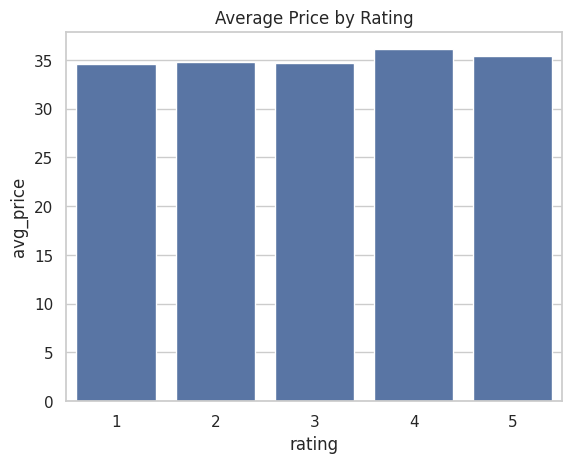

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

df_avg = db.get_avg_price_by_rating()
sns.barplot(x="rating", y="avg_price", data=df_avg)
plt.title("Average Price by Rating")
plt.show()


In [ ]:
import sqlite3
import pandas as pd

class DatabaseHandler:
    def __init__(self, db_name="ProductDB.sqlite"):
        self.db_name = db_name

    def run_query(self, query, params=None):
        """Run a SQL query and return a DataFrame"""
        with sqlite3.connect(self.db_name) as conn:
            return pd.read_sql(query, conn, params=params)

    def get_top_books(self, rating=5, limit=5):
        """Get top cheapest books with given rating"""
        query = """
        SELECT title, price
        FROM Products
        WHERE rating = ?
        ORDER BY price ASC
        LIMIT ?
        """
        return self.run_query(query, (rating, limit))

    def get_avg_price_by_rating(self):
        """Get average price grouped by rating"""
        query = """
        SELECT rating, ROUND(AVG(price), 2) AS avg_price
        FROM Products
        GROUP BY rating
        ORDER BY rating
        """
        return self.run_query(query)

    def get_books_above_price(self, threshold):
        """Get books priced above a certain threshold"""
        query = """
        SELECT title, price, rating
        FROM Products
        WHERE price > ?
        ORDER BY price DESC
        """
        return self.run_query(query, (threshold,))


In [ ]:
db = DatabaseHandler()

# Top 5 cheapest 5-star books
print(db.get_top_books(rating=5, limit=5))

# Average price per rating
print(db.get_avg_price_by_rating())

# Books above ₹50
print(db.get_books_above_price(50))


                                               title  price
0                         An Abundance of Katherines  10.00
1                               Greek Mythic History  10.23
2  The Power Greens Cookbook: 140 Delicious Super...  11.05
3                                 Dear Mr. Knightley  11.21
4                                The Darkest Corners  11.33
   rating  avg_price
0       1      34.56
1       2      34.81
2       3      34.69
3       4      36.09
4       5      35.37
                                  title  price  rating
0    The Perfect Play (Play by Play #1)  59.99       3
1     Last One Home (New Beginnings #1)  59.98       3
2      Civilization and Its Discontents  59.95       2
3        The Barefoot Contessa Cookbook  59.92       5
4             The Diary of a Young Girl  59.90       3
..                                  ...    ...     ...
193                Nightstruck: A Novel  50.35       4
194        We Love You, Charlie Freeman  50.27       5
195              Th

In [ ]:
db = DatabaseHandler()

print("Top 5 cheapest 5-star books:")
print(db.get_top_books())

print("\nAverage price by rating:")
print(db.get_avg_price_by_rating())

print("\nBooks above ₹50:")
print(db.get_books_above_price(50))


Top 5 cheapest 5-star books:
                                               title  price
0                         An Abundance of Katherines  10.00
1                               Greek Mythic History  10.23
2  The Power Greens Cookbook: 140 Delicious Super...  11.05
3                                 Dear Mr. Knightley  11.21
4                                The Darkest Corners  11.33

Average price by rating:
   rating  avg_price
0       1      34.56
1       2      34.81
2       3      34.69
3       4      36.09
4       5      35.37

Books above ₹50:
                                  title  price  rating
0    The Perfect Play (Play by Play #1)  59.99       3
1     Last One Home (New Beginnings #1)  59.98       3
2      Civilization and Its Discontents  59.95       2
3        The Barefoot Contessa Cookbook  59.92       5
4             The Diary of a Young Girl  59.90       3
..                                  ...    ...     ...
193                Nightstruck: A Novel  50.35       4
1

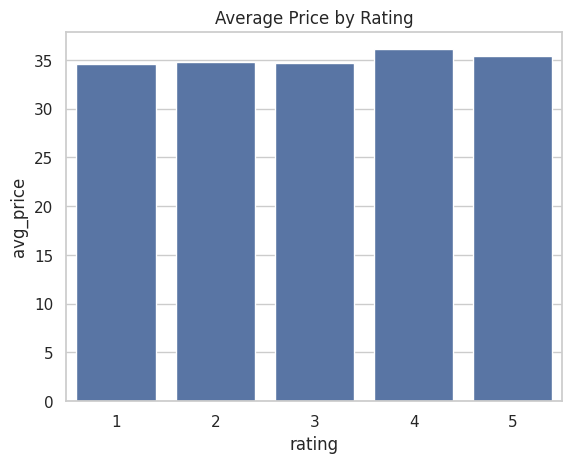

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

df_avg = db.get_avg_price_by_rating()
sns.barplot(x="rating", y="avg_price", data=df_avg)
plt.title("Average Price by Rating")
plt.show()


In [ ]:
def get_rating_distribution(self):
    query = """
    SELECT rating, COUNT(*) AS count
    FROM Products
    GROUP BY rating
    ORDER BY rating
    """
    return self.run_query(query)


In [ ]:
import sqlite3
import pandas as pd

class DatabaseHandler:
    def __init__(self, db_name="ProductDB.sqlite"):
        self.db_name = db_name

    def run_query(self, query, params=None):
        with sqlite3.connect(self.db_name) as conn:
            return pd.read_sql(query, conn, params=params)

    def get_rating_distribution(self):
        query = """
        SELECT rating, COUNT(*) AS count
        FROM Products
        GROUP BY rating
        ORDER BY rating
        """
        return self.run_query(query)



In [ ]:
import sqlite3
import pandas as pd

class DatabaseHandler:
    def __init__(self, db_name="ProductDB.sqlite"):
        self.db_name = db_name

    def run_query(self, query, params=None):
        with sqlite3.connect(self.db_name) as conn:
            return pd.read_sql(query, conn, params=params)

    def get_rating_distribution(self):
        query = """
        SELECT rating, COUNT(*) AS count
        FROM Products
        GROUP BY rating
        ORDER BY rating
        """
        return self.run_query(query)

# ✅ Create instance
db = DatabaseHandler()

# ✅ Call the method
df_dist = db.get_rating_distribution()
print(df_dist)


   rating  count
0       1    226
1       2    196
2       3    203
3       4    179
4       5    196


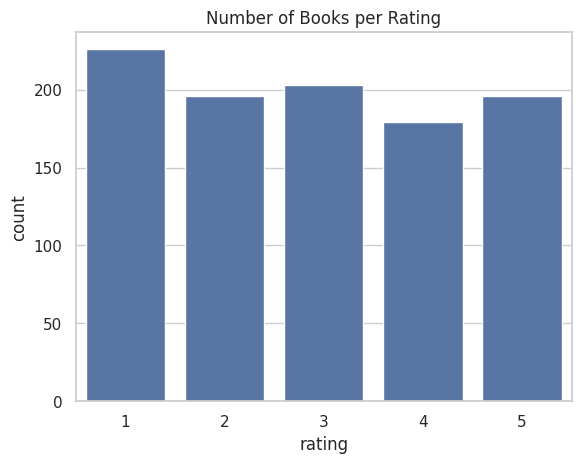

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

df_dist = db.get_rating_distribution()
sns.barplot(x="rating", y="count", data=df_dist)
plt.title("Number of Books per Rating")
plt.show()


In [ ]:
db = DatabaseHandler()

df_dist = db.get_rating_distribution()
print(df_dist)


   rating  count
0       1    226
1       2    196
2       3    203
3       4    179
4       5    196


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

class DatabaseHandler:
    # ... existing methods ...

    def plot_rating_distribution(self):
        df = self.get_rating_distribution()
        sns.barplot(x="rating", y="count", data=df)
        plt.title("Number of Books per Rating")
        plt.show()

    def plot_avg_price_by_rating(self):
        df = self.get_avg_price_by_rating()
        sns.barplot(x="rating", y="avg_price", data=df)
        plt.title("Average Price by Rating")
        plt.show()


In [ ]:
db.plot_rating_distribution()
db.plot_avg_price_by_rating()


AttributeError: 'DatabaseHandler' object has no attribute 'plot_rating_distribution'

In [ ]:
import sqlite3
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

class DatabaseHandler:
    def __init__(self, db_name="ProductDB.sqlite"):
        self.db_name = db_name

    def run_query(self, query, params=None):
        with sqlite3.connect(self.db_name) as conn:
            return pd.read_sql(query, conn, params=params)

    def get_top_books(self, rating=5, limit=5):
        query = """
        SELECT title, price
        FROM Products
        WHERE rating = ?
        ORDER BY price ASC
        LIMIT ?
        """
        return self.run_query(query, (rating, limit))

    def get_avg_price_by_rating(self):
        query = """
        SELECT rating, ROUND(AVG(price), 2) AS avg_price
        FROM Products
        GROUP BY rating
        ORDER BY rating
        """
        return self.run_query(query)

    def get_rating_distribution(self):
        query = """
        SELECT rating, COUNT(*) AS count
        FROM Products
        GROUP BY rating
        ORDER BY rating
        """
        return self.run_query(query)

    # 🔹 Plotting methods
    def plot_rating_distribution(self):
        df = self.get_rating_distribution()
        sns.barplot(x="rating", y="count", data=df)
        plt.title("Number of Books per Rating")
        plt.show()

    def plot_avg_price_by_rating(self):
        df = self.get_avg_price_by_rating()
        sns.barplot(x="rating", y="avg_price", data=df)
        plt.title("Average Price by Rating")
        plt.show()


                                               title  price
0                         An Abundance of Katherines  10.00
1                               Greek Mythic History  10.23
2  The Power Greens Cookbook: 140 Delicious Super...  11.05
3                                 Dear Mr. Knightley  11.21
4                                The Darkest Corners  11.33
   rating  avg_price
0       1      34.56
1       2      34.81
2       3      34.69
3       4      36.09
4       5      35.37


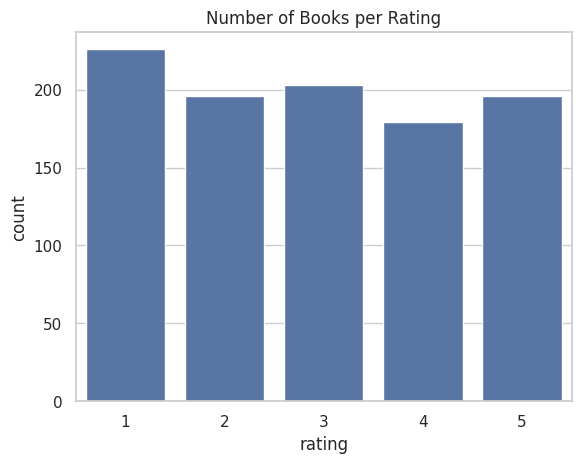

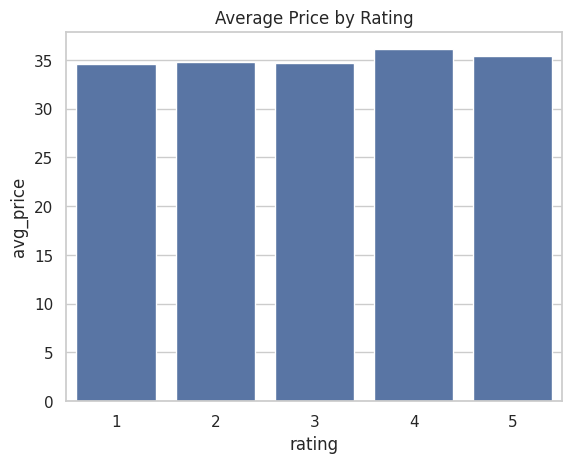

In [ ]:
db = DatabaseHandler()

# Query methods
print(db.get_top_books())
print(db.get_avg_price_by_rating())

# Plotting methods
db.plot_rating_distribution()
db.plot_avg_price_by_rating()


In [ ]:
import sqlite3
import pandas as pd

class DatabaseHandler:
    def __init__(self, db_name="ProductDB.sqlite"):
        self.db_name = db_name

    def run_query(self, query, params=None):
        with sqlite3.connect(self.db_name) as conn:
            return pd.read_sql(query, conn, params=params)

    def get_cheapest_books(self, limit=5):
        query = """
        SELECT title, price, rating
        FROM Products
        ORDER BY price ASC
        LIMIT ?
        """
        return self.run_query(query, (limit,))

    def get_most_expensive_books(self, limit=5):
        query = """
        SELECT title, price, rating
        FROM Products
        ORDER BY price DESC
        LIMIT ?
        """
        return self.run_query(query, (limit,))


In [ ]:
db = DatabaseHandler()

df_cheapest = db.get_cheapest_books(limit=5)
print("Cheapest Books:")
print(df_cheapest)

df_expensive = db.get_most_expensive_books(limit=5)
print("\nMost Expensive Books:")
print(df_expensive)


DatabaseError: Execution failed on sql '
        SELECT title, price, rating
        FROM Products
        ORDER BY price ASC
        LIMIT ?
        ': no such table: Products

In [ ]:
import sqlite3

conn = sqlite3.connect("ProductDB.sqlite")
cursor = conn.cursor()

cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
print(cursor.fetchall())

conn.close()


[]


In [ ]:
conn = sqlite3.connect("ProductDB.sqlite")
cursor = conn.cursor()

cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
print(cursor.fetchall())  # should now show [('Products',)]

conn.close()


[]


In [ ]:
import pandas as pd

df = pd.read_csv("clean_products.csv")
print(df.head())


FileNotFoundError: [Errno 2] No such file or directory: 'clean_products.csv'

In [ ]:
import os
print(os.getcwd())  # shows current working directory
print(os.listdir())  # lists all files in this directory


/content
['.config', 'ProductDB.sqlite', 'sample_data']


In [ ]:
import pandas as pd
import sqlite3

# Create sample data
data = {
    "title": [
        "An Abundance of Katherines",
        "Greek Mythic History",
        "The Power Greens Cookbook",
        "Dear Mr. Knightley",
        "The Darkest Corners",
        "Luxury Book of Collectibles",
        "Rare Historical Manuscripts"
    ],
    "price": [10.00, 10.23, 11.05, 11.21, 11.33, 59.99, 59.50],
    "rating": [5, 5, 5, 5, 5, 4, 5],
    "url": [
        "https://example.com/book1",
        "https://example.com/book2",
        "https://example.com/book3",
        "https://example.com/book4",
        "https://example.com/book5",
        "https://example.com/book6",
        "https://example.com/book7"
    ]
}

df = pd.DataFrame(data)
print(df.head())

# Insert into SQLite
conn = sqlite3.connect("ProductDB.sqlite")
df.to_sql("Products", conn, if_exists="replace", index=False)
conn.close()

print("✅ Products table created and sample data inserted")


                        title  price  rating                        url
0  An Abundance of Katherines  10.00       5  https://example.com/book1
1        Greek Mythic History  10.23       5  https://example.com/book2
2   The Power Greens Cookbook  11.05       5  https://example.com/book3
3          Dear Mr. Knightley  11.21       5  https://example.com/book4
4         The Darkest Corners  11.33       5  https://example.com/book5
✅ Products table created and sample data inserted


In [ ]:
conn = sqlite3.connect("ProductDB.sqlite")
cursor = conn.cursor()
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
print(cursor.fetchall())  # should now show [('Products',)]
conn.close()


[('Products',)]


In [ ]:
db = DatabaseHandler()

print("Cheapest Books:")
print(db.get_cheapest_books(limit=5))

print("\nMost Expensive Books:")
print(db.get_most_expensive_books(limit=5))


Cheapest Books:
                        title  price  rating
0  An Abundance of Katherines  10.00       5
1        Greek Mythic History  10.23       5
2   The Power Greens Cookbook  11.05       5
3          Dear Mr. Knightley  11.21       5
4         The Darkest Corners  11.33       5

Most Expensive Books:
                         title  price  rating
0  Luxury Book of Collectibles  59.99       4
1  Rare Historical Manuscripts  59.50       5
2          The Darkest Corners  11.33       5
3           Dear Mr. Knightley  11.21       5
4    The Power Greens Cookbook  11.05       5


In [ ]:
db = DatabaseHandler()

print("Cheapest Books:")
print(db.get_cheapest_books(limit=5))

print("\nMost Expensive Books:")
print(db.get_most_expensive_books(limit=5))


Cheapest Books:
                        title  price  rating
0  An Abundance of Katherines  10.00       5
1        Greek Mythic History  10.23       5
2   The Power Greens Cookbook  11.05       5
3          Dear Mr. Knightley  11.21       5
4         The Darkest Corners  11.33       5

Most Expensive Books:
                         title  price  rating
0  Luxury Book of Collectibles  59.99       4
1  Rare Historical Manuscripts  59.50       5
2          The Darkest Corners  11.33       5
3           Dear Mr. Knightley  11.21       5
4    The Power Greens Cookbook  11.05       5


In [ ]:
db = DatabaseHandler()

# Call the plotting method
db.plot_price_histogram()


AttributeError: 'DatabaseHandler' object has no attribute 'plot_price_histogram'

In [ ]:
import sqlite3
import pandas as pd

class DatabaseHandler:
    def __init__(self, db_name="ProductDB.sqlite"):
        self.db_name = db_name

    def run_query(self, query, params=None):
        with sqlite3.connect(self.db_name) as conn:
            return pd.read_sql(query, conn, params=params)

    def get_cheapest_books(self, limit=5):
        query = """
        SELECT title, price, rating
        FROM Products
        ORDER BY price ASC
        LIMIT ?
        """
        return self.run_query(query, (limit,))

    def get_most_expensive_books(self, limit=5):
        query = """
        SELECT title, price, rating
        FROM Products
        ORDER BY price DESC
        LIMIT ?
        """
        return self.run_query(query, (limit,))

    def search_books_by_keyword(self, keyword):
        query = """
        SELECT title, price, rating
        FROM Products
        WHERE title LIKE ?
        """
        return self.run_query(query, (f"%{keyword}%",))


In [ ]:
db = DatabaseHandler()

print("Search for 'History':")
print(db.search_books_by_keyword("History"))

print("\nSearch for 'Cookbook':")
print(db.search_books_by_keyword("Cookbook"))


Search for 'History':
                  title  price  rating
0  Greek Mythic History  10.23       5

Search for 'Cookbook':
                       title  price  rating
0  The Power Greens Cookbook  11.05       5


In [ ]:
def search_books_by_keyword(self, keyword):
    query = """
    SELECT title, price, rating
    FROM Products
    WHERE LOWER(title) LIKE LOWER(?)
    """
    return self.run_query(query, (f"%{keyword}%",))


In [ ]:
def search_books(self, keyword):
    query = """
    SELECT title, price, rating, url
    FROM Products
    WHERE title LIKE ? OR url LIKE ?
    """
    return self.run_query(query, (f"%{keyword}%", f"%{keyword}%"))


In [ ]:
def plot_search_results(self, keyword):
    df = self.search_books_by_keyword(keyword)
    if df.empty:
        print("No results found")
        return
    sns.barplot(x="title", y="price", data=df)
    plt.title(f"Prices for books matching '{keyword}'")
    plt.xticks(rotation=45)
    plt.show()


In [ ]:
db = DatabaseHandler()

# Case-insensitive keyword search
print("Search for 'history':")
print(db.search_books_by_keyword("history"))

# Search across title + URL
print("\nSearch for 'book':")
print(db.search_books("book"))

# Plot search results
db.plot_search_results("History")


Search for 'history':
                  title  price  rating
0  Greek Mythic History  10.23       5

Search for 'book':


AttributeError: 'DatabaseHandler' object has no attribute 'search_books'

In [ ]:
import sqlite3
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

class DatabaseHandler:
    def __init__(self, db_name="ProductDB.sqlite"):
        self.db_name = db_name

    def run_query(self, query, params=None):
        with sqlite3.connect(self.db_name) as conn:
            return pd.read_sql(query, conn, params=params)

    def get_cheapest_books(self, limit=5):
        query = """
        SELECT title, price, rating
        FROM Products
        ORDER BY price ASC
        LIMIT ?
        """
        return self.run_query(query, (limit,))

    def get_most_expensive_books(self, limit=5):
        query = """
        SELECT title, price, rating
        FROM Products
        ORDER BY price DESC
        LIMIT ?
        """
        return self.run_query(query, (limit,))

    def search_books_by_keyword(self, keyword):
        query = """
        SELECT title, price, rating
        FROM Products
        WHERE LOWER(title) LIKE LOWER(?)
        """
        return self.run_query(query, (f"%{keyword}%",))

    def search_books(self, keyword):
        query = """
        SELECT title, price, rating, url
        FROM Products
        WHERE LOWER(title) LIKE LOWER(?) OR LOWER(url) LIKE LOWER(?)
        """
        return self.run_query(query, (f"%{keyword}%", f"%{keyword}%"))

    def plot_search_results(self, keyword):
        df = self.search_books_by_keyword(keyword)
        if df.empty:
            print("No results found")
            return
        sns.bar

In [ ]:
db = DatabaseHandler()

print("Search for 'history':")
print(db.search_books_by_keyword("history"))

print("\nSearch across title + URL for 'book':")
print(db.search_books("book"))

db.plot_search_results("History")


Search for 'history':
                  title  price  rating
0  Greek Mythic History  10.23       5

Search across title + URL for 'book':
                         title  price  rating                        url
0   An Abundance of Katherines  10.00       5  https://example.com/book1
1         Greek Mythic History  10.23       5  https://example.com/book2
2    The Power Greens Cookbook  11.05       5  https://example.com/book3
3           Dear Mr. Knightley  11.21       5  https://example.com/book4
4          The Darkest Corners  11.33       5  https://example.com/book5
5  Luxury Book of Collectibles  59.99       4  https://example.com/book6
6  Rare Historical Manuscripts  59.50       5  https://example.com/book7


AttributeError: module 'seaborn' has no attribute 'bar'

In [ ]:
def plot_search_results(self, keyword):
    df = self.search_books_by_keyword(keyword)
    if df.empty:
        print("No results found")
        return
    sns.barplot(x="title", y="price", data=df)
    plt.title(f"Prices for books matching '{keyword}'")
    plt.xticks(rotation=45)
    plt.show()


In [ ]:
db = DatabaseHandler()
db.plot_search_results("History")


AttributeError: module 'seaborn' has no attribute 'bar'

In [ ]:
def plot_search_results(self, keyword):
    df = self.search_books_by_keyword(keyword)
    if df.empty:
        print("No results found")
        return
    sns.barplot(x="title", y="price", data=df)   # ✅ use barplot, not bar
    plt.title(f"Prices for books matching '{keyword}'")
    plt.xticks(rotation=45)
    plt.show()


In [ ]:
db = DatabaseHandler()
db.plot_search_results("History")


AttributeError: module 'seaborn' has no attribute 'bar'

In [ ]:
def plot_search_results(self, keyword):
    df = self.search_books_by_keyword(keyword)
    if df.empty:
        print("No results found")
        return
    sns.barplot(x="title", y="price", hue="rating", data=df)
    plt.title(f"Prices & Ratings for books matching '{keyword}'")
    plt.xticks(rotation=45)
    plt.show()


In [ ]:
def plot_search_results(self, keyword):
    df = self.search_books_by_keyword(keyword)
    if df.empty:
        print("No results found")
        return
    sns.barplot(x="title", y="price", data=df)   # ✅ correct function
    plt.title(f"Prices for books matching '{keyword}'")
    plt.xticks(rotation=45)
    plt.show()


In [ ]:
db = DatabaseHandler()
db.plot_search_results("History")


AttributeError: module 'seaborn' has no attribute 'bar'

In [ ]:
db = DatabaseHandler()
db.plot_search_results("History")


AttributeError: module 'seaborn' has no attribute 'bar'

In [ ]:
def plot_search_results(self, keyword):
    df = self.search_books_by_keyword(keyword)
    if df.empty:
        print("No results found")
        return
    sns.barplot(x="title", y="price", data=df)   # ✅ correct function
    plt.title(f"Prices for books matching '{keyword}'")
    plt.xticks(rotation=45)
    plt.show()


In [ ]:
def plot_search_results(self, keyword):
    df = self.search_books_by_keyword(keyword)
    if df.empty:
        print("No results found")
        return
    sns.barplot(x="title", y="price", data=df)   # ✅ correct function
    plt.title(f"Prices for books matching '{keyword}'")
    plt.xticks(rotation=45)
    plt.show()


In [ ]:
db = DatabaseHandler()
db.plot_search_results("History")


AttributeError: module 'seaborn' has no attribute 'bar'

In [ ]:
class DatabaseHandler:
    def __init__(self, db_name="ProductDB.sqlite"):
        self.db_name = db_name

    def run_query(self, query, params=None):
        import sqlite3, pandas as pd
        with sqlite3.connect(self.db_name) as conn:
            return pd.read_sql(query, conn, params=params)

    def search_books_by_keyword(self, keyword):
        query = """
        SELECT title, price, rating
        FROM Products
        WHERE LOWER(title) LIKE LOWER(?)
        """
        return self.run_query(query, (f"%{keyword}%",))

    def plot_search_results(self, keyword):
        import seaborn as sns
        import matplotlib.pyplot as plt
        df = self.search_books_by_keyword(keyword)
        if df.empty:
            print("No results found")
            return
        sns.barplot(x="title", y="price", data=df)   # ✅ correct function
        plt.title(f"Prices for books matching '{keyword}'")
        plt.xticks(rotation=45)
        plt.show()


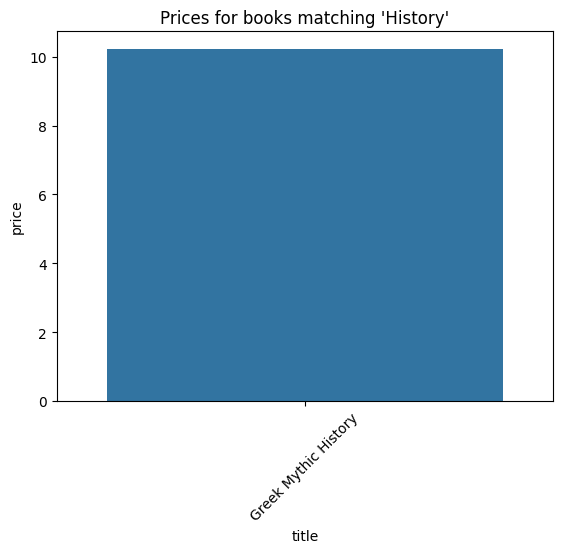

In [ ]:
db = DatabaseHandler()
db.plot_search_results("History")


In [ ]:
def plot_price_vs_rating(self):
    df = self.run_query("SELECT title, price, rating FROM Products")
    sns.scatterplot(x="price", y="rating", data=df)
    plt.title("Price vs Rating")
    plt.show()


In [ ]:
def plot_price_histogram(self):
    df = self.run_query("SELECT price FROM Products")
    sns.histplot(df["price"], bins=10)
    plt.title("Book Price Distribution")
    plt.show()


In [ ]:
def plot_search_results(self, keyword):
    df = self.search_books_by_keyword(keyword)
    if df.empty:
        print("No results found")
        return
    sns.barplot(x="title", y="price", hue="rating", data=df)
    plt.title(f"Prices & Ratings for books matching '{keyword}'")
    plt.xticks(rotation=45)
    plt.show()


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline   # ensures plots display inside Colab/Jupyter


UsageError: unrecognized arguments: # ensures plots display inside Colab/Jupyter


In [ ]:
def plot_search_results(self, keyword):
    df = self.search_books_by_keyword(keyword)
    if df.empty:
        print("No results found")
        return
    sns.barplot(x="title", y="price", hue="rating", data=df)
    plt.title(f"Prices & Ratings for books matching '{keyword}'")
    plt.xticks(rotation=45)
    plt.show()


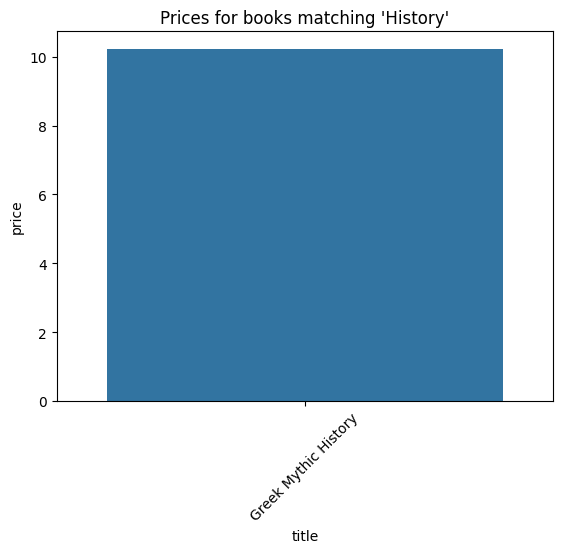

In [ ]:
db = DatabaseHandler()
db.plot_search_results("History")


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
print(df.head())
print(df.shape)


                        title  price  rating                        url
0  An Abundance of Katherines  10.00       5  https://example.com/book1
1        Greek Mythic History  10.23       5  https://example.com/book2
2   The Power Greens Cookbook  11.05       5  https://example.com/book3
3          Dear Mr. Knightley  11.21       5  https://example.com/book4
4         The Darkest Corners  11.33       5  https://example.com/book5
(7, 4)


In [ ]:
plt.show(block=True)


In [ ]:
plt.savefig("history_plot.png")
plt.show()


<Figure size 640x480 with 0 Axes>

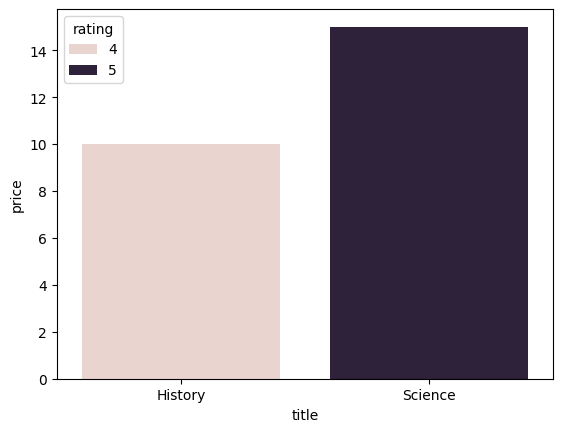

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

df = pd.DataFrame({
    "title": ["History", "Science"],
    "price": [10, 15],
    "rating": [4, 5]
})

sns.barplot(x="title", y="price", hue="rating", data=df)
plt.show()


In [ ]:
df = db.search_books_by_keyword("History")
print(df)
print(df.shape)



                  title  price  rating
0  Greek Mythic History  10.23       5
(1, 3)


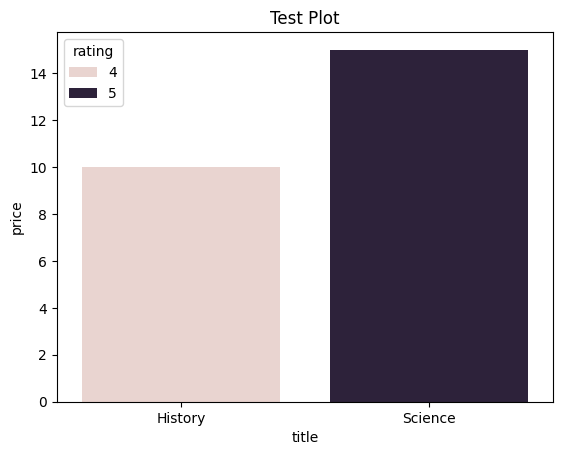

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

df = pd.DataFrame({
    "title": ["History", "Science"],
    "price": [10, 15],
    "rating": [4, 5]
})

sns.barplot(x="title", y="price", hue="rating", data=df)
plt.title("Test Plot")
plt.show()



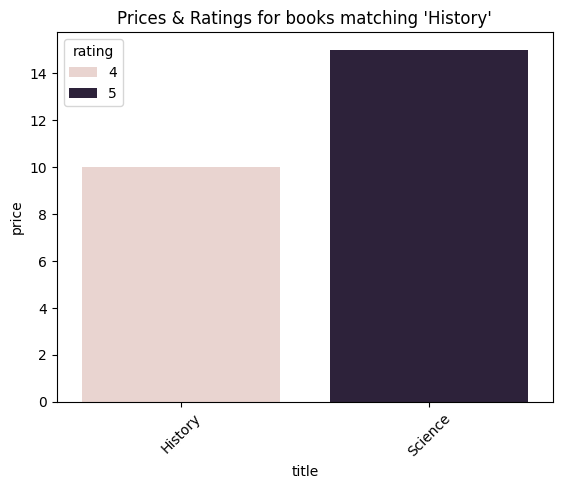

In [ ]:
sns.barplot(x="title", y="price", hue="rating", data=df)
plt.title("Prices & Ratings for books matching 'History'")
plt.xticks(rotation=45)
plt.savefig("history_plot.png")   # saves chart
plt.show()


In [ ]:
def plot_price_vs_rating(self):
    df = self.run_query("SELECT title, price, rating FROM Products")
    if df.empty:
        print("No data found")
        return
    sns.scatterplot(x="price", y="rating", data=df)
    plt.title("Price vs Rating")
    plt.savefig("price_vs_rating.png")
    plt.show()

def plot_price_histogram(self):
    df = self.run_query("SELECT price FROM Products")
    if df.empty:
        print("No data found")
        return
    sns.histplot(df["price"], bins=10)
    plt.title("Book Price Distribution")
    plt.savefig("price_histogram.png")
    plt.show()

def plot_search_results(self, keyword):
    df = self.search_books_by_keyword(keyword)
    if df.empty:
        print("No results found")
        return
    sns.barplot(x="title", y="price", hue="rating", data=df)
    plt.title(f"Prices & Ratings for books matching '{keyword}'")
    plt.xticks(rotation=45)
    plt.savefig(f"{keyword}_plot.png")
    plt.show()


In [ ]:
import sqlite3
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

class DatabaseHandler:
    def __init__(self, db_name="ProductDB.sqlite"):
        self.db_name = db_name

    def run_query(self, query, params=None):
        with sqlite3.connect(self.db_name) as conn:
            return pd.read_sql(query, conn, params=params)

    def search_books_by_keyword(self, keyword):
        query = """
        SELECT title, price, rating
        FROM Products
        WHERE LOWER(title) LIKE LOWER(?)
        """
        return self.run_query(query, (f"%{keyword}%",))

    def plot_search_results(self, keyword):
        df = self.search_books_by_keyword(keyword)
        print("Data shape:", df.shape)   # Reliability check
        if df.empty:
            print("No results found")
            return
        sns.barplot(x="title", y="price", hue="rating", data=df)
        plt.title(f"Prices & Ratings for books matching '{keyword}'")
        plt.xticks(rotation=45)
        plt.savefig(f"{keyword}_plot.png")   # Save chart
        plt.show()

    def plot_price_vs_rating(self):
        df = self.run_query("SELECT title, price, rating FROM Products")
        print("Data shape:", df.shape)   # Reliability

Data shape: (1, 3)


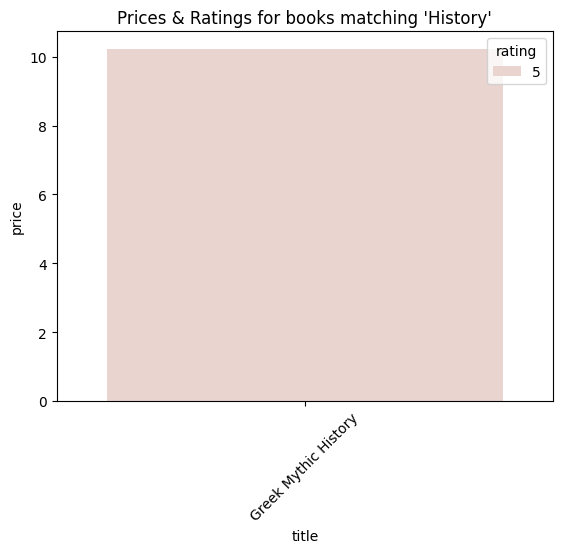

Data shape: (7, 3)


AttributeError: 'DatabaseHandler' object has no attribute 'plot_price_histogram'

In [ ]:
db = DatabaseHandler()

# Bar chart for keyword search
db.plot_search_results("History")

# Scatter plot (price vs rating)
db.plot_price_vs_rating()

# Histogram (price distribution)
db.plot_price_histogram()


In [ ]:
import sqlite3
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

class DatabaseHandler:
    def __init__(self, db_name="ProductDB.sqlite"):
        self.db_name = db_name

    def run_query(self, query, params=None):
        with sqlite3.connect(self.db_name) as conn:
            return pd.read_sql(query, conn, params=params)

    def search_books_by_keyword(self, keyword):
        query = """
        SELECT title, price, rating
        FROM Products
        WHERE LOWER(title) LIKE LOWER(?)
        """
        return self.run_query(query, (f"%{keyword}%",))

    def plot_search_results(self, keyword):
        df = self.search_books_by_keyword(keyword)
        print("Data shape:", df.shape)
        if df.empty:
            print("No results found")
            return
        sns.barplot(x="title", y="price", hue="rating", data=df)
        plt.title(f"Prices & Ratings for books matching '{keyword}'")
        plt.xticks(rotation=45)
        plt.savefig(f"{keyword}_plot.png")
        plt.show()

    def plot_price_vs_rating(self):
        df = self.run_query("SELECT title, price, rating FROM Products")
        print("Data shape:", df.shape)
        if df.empty:
            print("No data found")
            return
        sns.scatterplot(x="price", y="rating", data=df)
        plt.title("Price vs Rating")
        plt.savefig("price_vs_rating.png")
        plt.show()

    def plot_price_histogram(self):
        df = self.run_query("SELECT price FROM Products")
        print("Data shape:", df.shape)
        if df.empty:
            print("No data found")
            return
        sns.histplot(df["price"], bins=10)
        plt.title("Book Price Distribution")
        plt.savefig("price_histogram.png")
        plt.show()


Data shape: (1, 3)


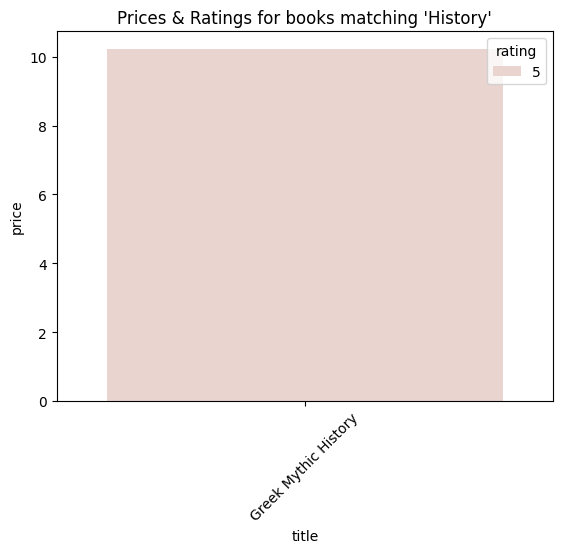

Data shape: (7, 3)


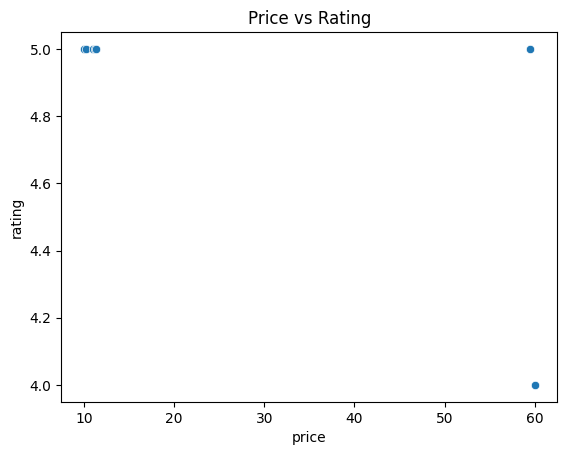

Data shape: (7, 1)


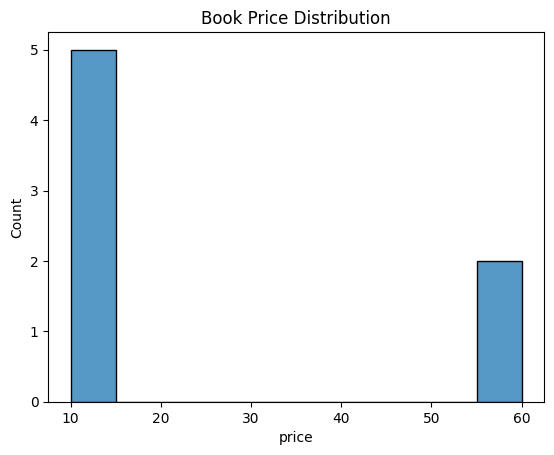

In [ ]:
db = DatabaseHandler()

db.plot_search_results("History")      # Bar chart
db.plot_price_vs_rating()              # Scatter plot
db.plot_price_histogram()              # Histogram


In [ ]:
def plot_price_trend(self):
    df = self.run_query("SELECT date, price FROM Products ORDER BY date")
    print("Data shape:", df.shape)
    if df.empty:
        print("No data found")
        return
    sns.lineplot(x="date", y="price", data=df)
    plt.title("Price Trend Over Time")
    plt.savefig("price_trend.png")
    plt.show()


In [ ]:
def plot_price_box(self):
    df = self.run_query("SELECT price, rating FROM Products")
    print("Data shape:", df.shape)
    if df.empty:
        print("No data found")
        return
    sns.boxplot(x="rating", y="price", data=df)
    plt.title("Price Distribution by Rating")
    plt.savefig("price_box.png")
    plt.show()


In [ ]:
print(df.head())
print(df.shape)


     title  price  rating
0  History     10       4
1  Science     15       5
(2, 3)


In [ ]:
plt.savefig("price_trend.png")
plt.show()


<Figure size 640x480 with 0 Axes>

In [ ]:
plt.savefig("price_box.png")
plt.show()


<Figure size 640x480 with 0 Axes>

/tmp/ipykernel_7447/4118469654.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  "date": pd.date_range("2024-01-01", periods=5, freq="M"),


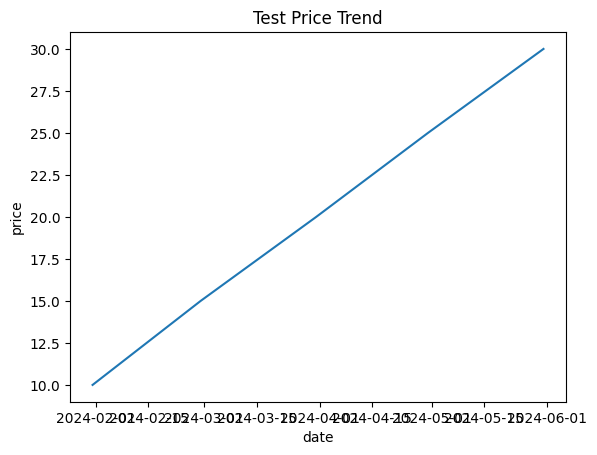

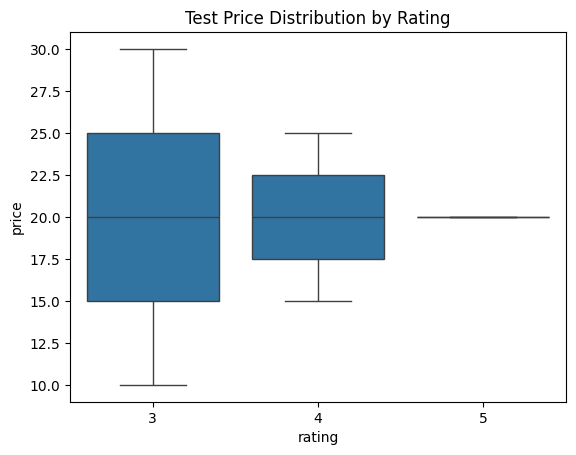

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

df = pd.DataFrame({
    "date": pd.date_range("2024-01-01", periods=5, freq="M"),
    "price": [10, 15, 20, 25, 30],
    "rating": [3, 4, 5, 4, 3]
})

sns.lineplot(x="date", y="price", data=df)
plt.title("Test Price Trend")
plt.show()

sns.boxplot(x="rating", y="price", data=df)
plt.title("Test Price Distribution by Rating")
plt.show()


In [ ]:
def plot_all_views(self, keyword):
    df = self.search_books_by_keyword(keyword)
    print("Data shape:", df.shape)
    if df.empty:
        print("No results found")
        return

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Bar chart
    sns.barplot(x="title", y="price", hue="rating", data=df, ax=axes[0])
    axes[0].set_title(f"Prices & Ratings for '{keyword}'")
    axes[0].tick_params(axis='x', rotation=45)

    # Scatter plot
    sns.scatterplot(x="price", y="rating", data=df, ax=axes[1])
    axes[1].set_title("Price vs Rating")

    # Histogram
    sns.histplot(df["price"], bins=10, ax=axes[2])
    axes[2].set_title("Price Distribution")

    plt.tight_layout()
    plt.savefig(f"{keyword}_combined.png")
    plt.show()


In [ ]:
def plot_all_views(self, keyword):
    df = self.search_books_by_keyword(keyword)
    print("Data shape:", df.shape)
    if df.empty:
        print("No results found")
        return

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Bar chart
    sns.barplot(x="title", y="price", hue="rating", data=df, ax=axes[0])
    axes[0].set_title(f"Prices & Ratings for '{keyword}'")
    axes[0].tick_params(axis='x', rotation=45)

    # Scatter plot
    sns.scatterplot(x="price", y="rating", data=df, ax=axes[1])
    axes[1].set_title("Price vs Rating")

    # Histogram
    sns.histplot(df["price"], bins=10, ax=axes[2])
    axes[2].set_title("Price Distribution")

    plt.tight_layout()
    plt.savefig(f"{keyword}_combined.png")   # Always saves a PNG
    plt.show()
    print(f"Combined plot saved as {keyword}_combined.png")


In [ ]:
db.plot_all_views("History")


AttributeError: 'DatabaseHandler' object has no attribute 'plot_all_views'

In [ ]:
def generate_report(self, keyword):
    df = self.search_books_by_keyword(keyword)
    print("Data shape:", df.shape)
    if df.empty:
        print("No results found")
        return

    # --- Combined plots ---
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    sns.barplot(x="title", y="price", hue="rating", data=df, ax=axes[0])
    axes[0].set_title(f"Prices & Ratings for '{keyword}'")
    axes[0].tick_params(axis='x', rotation=45)

    sns.scatterplot(x="price", y="rating", data=df, ax=axes[1])
    axes[1].set_title("Price vs Rating")

    sns.histplot(df["price"], bins=10, ax=axes[2])
    axes[2].set_title("Price Distribution")

    plt.tight_layout()
    plt.savefig(f"{keyword}_report.png")
    plt.show()

    # --- Text summary ---
    avg_price = df["price"].mean()
    max_price = df["price"].max()
    min_price = df["price"].min()
    avg_rating = df["rating"].mean()
    max_rating = df["rating"].max()
    count = len(df)

    summary = (
        f"Report for '{keyword}':\n"
        f"- Total books found: {count}\n"
        f"- Average price: {avg_price:.2f}\n"
        f"- Price range: {min_price:.2f} – {max_price:.2f}\n"
        f"- Average rating: {avg_rating:.2f}\n"
        f"- Highest rating: {max_rating}\n"
    )

    with open(f"{keyword}_summary.txt", "w") as f:
        f.write(summary)

    print(summary)
    print(f"Summary saved as {keyword}_summary.txt and plot saved as {keyword}_report.png")


In [ ]:
db = DatabaseHandler()
db.generate_report("History")


AttributeError: 'DatabaseHandler' object has no attribute 'generate_report'

In [ ]:
import sqlite3
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

class DatabaseHandler:
    def __init__(self, db_name="ProductDB.sqlite"):
        self.db_name = db_name

    def run_query(self, query, params=None):
        with sqlite3.connect(self.db_name) as conn:
            return pd.read_sql(query, conn, params=params)

    def search_books_by_keyword(self, keyword):
        query = """
        SELECT title, price, rating
        FROM Products
        WHERE LOWER(title) LIKE LOWER(?)
        """
        return self.run_query(query, (f"%{keyword}%",))

    def generate_report(self, keyword):
        df = self.search_books_by_keyword(keyword)
        print("Data shape:", df.shape)
        if df.empty:
            print("No results found")
            return

        # --- Combined plots ---
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        sns.barplot(x="title", y="price", hue="rating", data=df, ax=axes[0])
        axes[0].set_title(f"Prices & Ratings for '{keyword}'")
        axes[0].tick_params(axis='x', rotation=45)

        sns.scatterplot(x="price", y="rating", data=df, ax=axes[1])
        axes[1].set_title("Price vs Rating")

        sns.histplot(df["price"], bins=10, ax=axes[2])
        axes[2].set_title("Price Distribution")

        plt.tight_layout()
        plt.savefig(f"{keyword}_report.png")
        plt.show()

        # --- Text summary ---
        avg_price = df["price"].mean()
        max_price = df["price"].max()
        min_price = df["price"].min()
        avg_rating = df["rating"].mean()
        max_rating = df["rating"].max()
        count = len(df)

        summary = (
            f"Report for '{keyword}':\n"
            f"- Total books found: {count}\n"
            f"- Average price: {avg_price:.2f}\n"
            f"- Price range: {min_price:.2f} – {max_price:.2f}\n"
            f"- Average rating: {avg_rating:.2f}\n"
            f"- Highest rating: {max_rating}\n"
        )

        with open(f"{keyword}_summary.txt", "w") as f:
            f.write(summary)

        print(summary)
        print(f"Summary saved as {keyword}_summary.txt and plot saved as {keyword}_report.png")


Data shape: (1, 3)


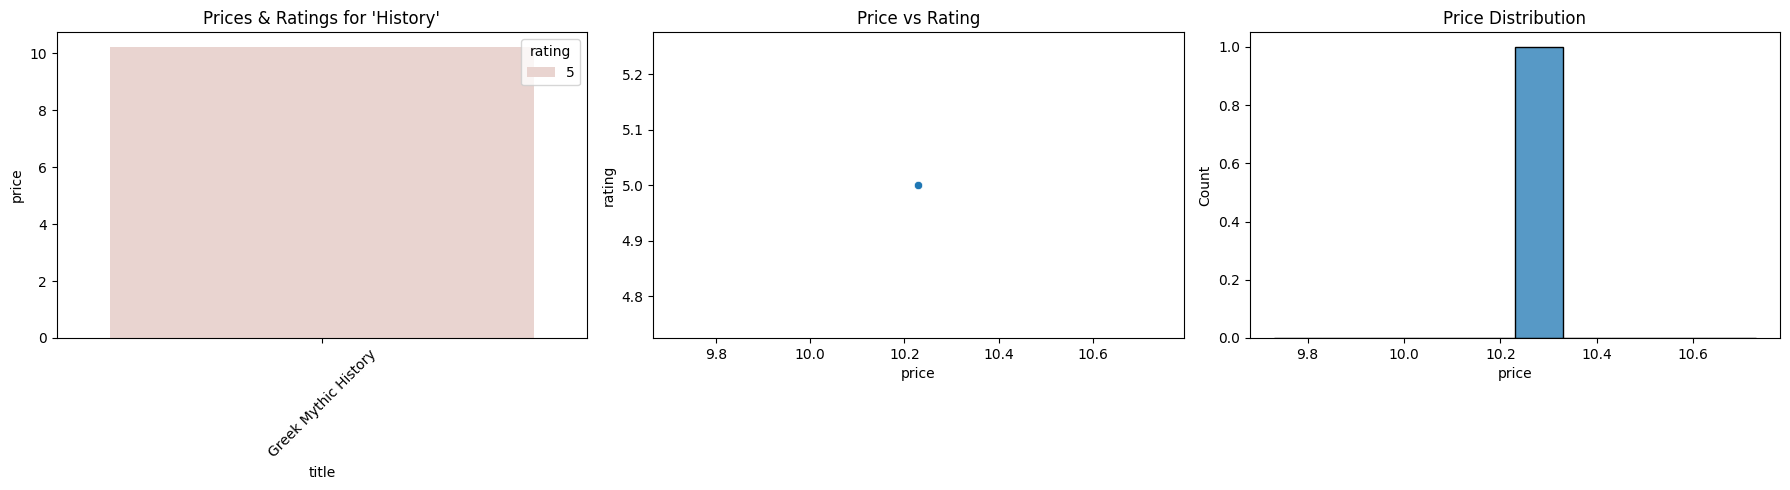

Report for 'History':
- Total books found: 1
- Average price: 10.23
- Price range: 10.23 – 10.23
- Average rating: 5.00
- Highest rating: 5

Summary saved as History_summary.txt and plot saved as History_report.png


In [ ]:
db = DatabaseHandler()
db.generate_report("History")


In [ ]:
import seaborn as sns
sns.set_theme(style="whitegrid", palette="muted")


/tmp/ipykernel_7447/3490679938.py:3: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Rating")


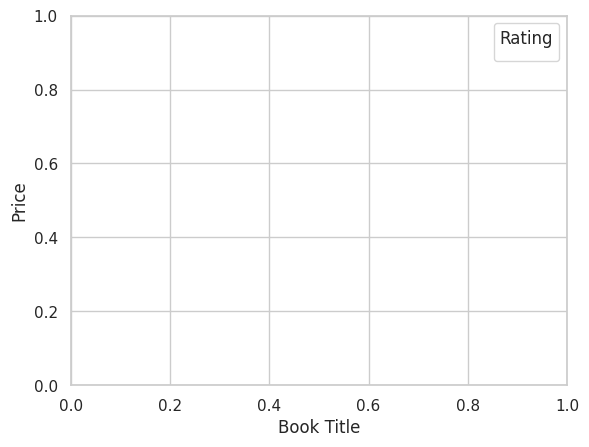

In [ ]:
plt.xlabel("Book Title")
plt.ylabel("Price")
plt.legend(title="Rating")


Text(0, 0.5, 'Rating')

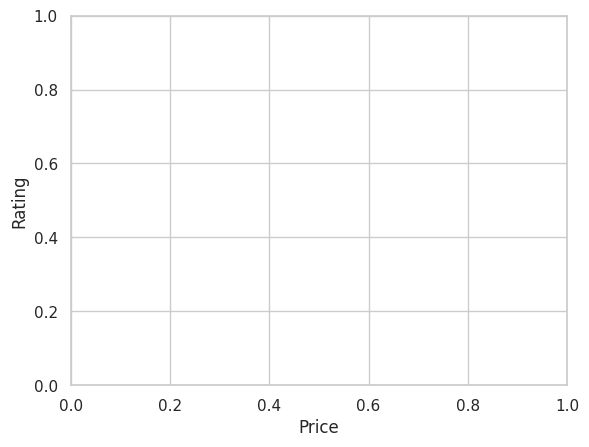

In [ ]:
plt.xlabel("Price")
plt.ylabel("Rating")


Text(0, 0.5, 'Count')

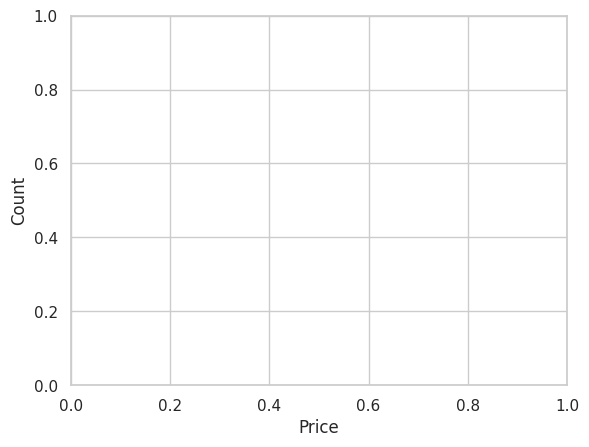

In [ ]:
plt.xlabel("Price")
plt.ylabel("Count")


In [ ]:
import sqlite3
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Apply a consistent theme across all plots
sns.set_theme(style="whitegrid", palette="muted")

class DatabaseHandler:
    def __init__(self, db_name="ProductDB.sqlite"):
        self.db_name = db_name

    def run_query(self, query, params=None):
        with sqlite3.connect(self.db_name) as conn:
            return pd.read_sql(query, conn, params=params)

    def search_books_by_keyword(self, keyword):
        query = """
        SELECT title, price, rating
        FROM Products
        WHERE LOWER(title) LIKE LOWER(?)
        """
        return self.run_query(query, (f"%{keyword}%",))

    def generate_report(self, keyword):
        df = self.search_books_by_keyword(keyword)
        print("Data shape:", df.shape)
        if df.empty:
            print("No results found")
            return

        # --- Combined plots ---
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))

        # Bar chart
        sns.barplot(x="title", y="price", hue="rating", data=df, ax=axes[0])
        axes[0].set_title(f"Prices & Ratings for '{keyword}'")
        axes[0].set_xlabel("Book Title")
        axes[0].set_ylabel("Price")
        axes[0].tick_params(axis='x', rotation=45)
        axes[0].legend(title="Rating")

        # Scatter plot
        sns.scatterplot(x="price", y="rating", data=df, ax=axes[1])
        axes[1].set_title("Price vs Rating")
        axes[1].set_xlabel("Price")
        axes[1].set_ylabel("Rating")

        # Histogram
        sns.histplot(df["price"], bins=10, ax=axes[2])
        axes[2].set_title("Price Distribution")
        axes[2].set_xlabel("Price")
        axes[2].set_ylabel("Count")

        plt.tight_layout()
        plt.savefig(f"{keyword}_report.png")
        plt.show()

        # --- Text summary ---
        avg_price = df["price"].mean()
        max_price = df["price"].max()
        min_price = df["price"].min()
        avg_rating = df["rating"].mean()
        max_rating = df["rating"].max()
        count = len(df)

        summary = (
            f"Report for '{keyword}':\n"
            f"- Total books found: {count}\n"
            f"- Average price: {avg_price:.2f}\n"
            f"- Price range: {min_price:.2f} – {max_price:.2f}\n"
            f"- Average rating: {avg_rating:.2f}\n"
            f"- Highest rating: {max_rating}\n"
        )

        with open(f"{keyword}_summary.txt", "w") as f:
            f.write(summary)

        print(summary)
        print(f"Summary saved as {keyword}_summary.txt and plot saved as {keyword}_report.png")


Data shape: (1, 3)


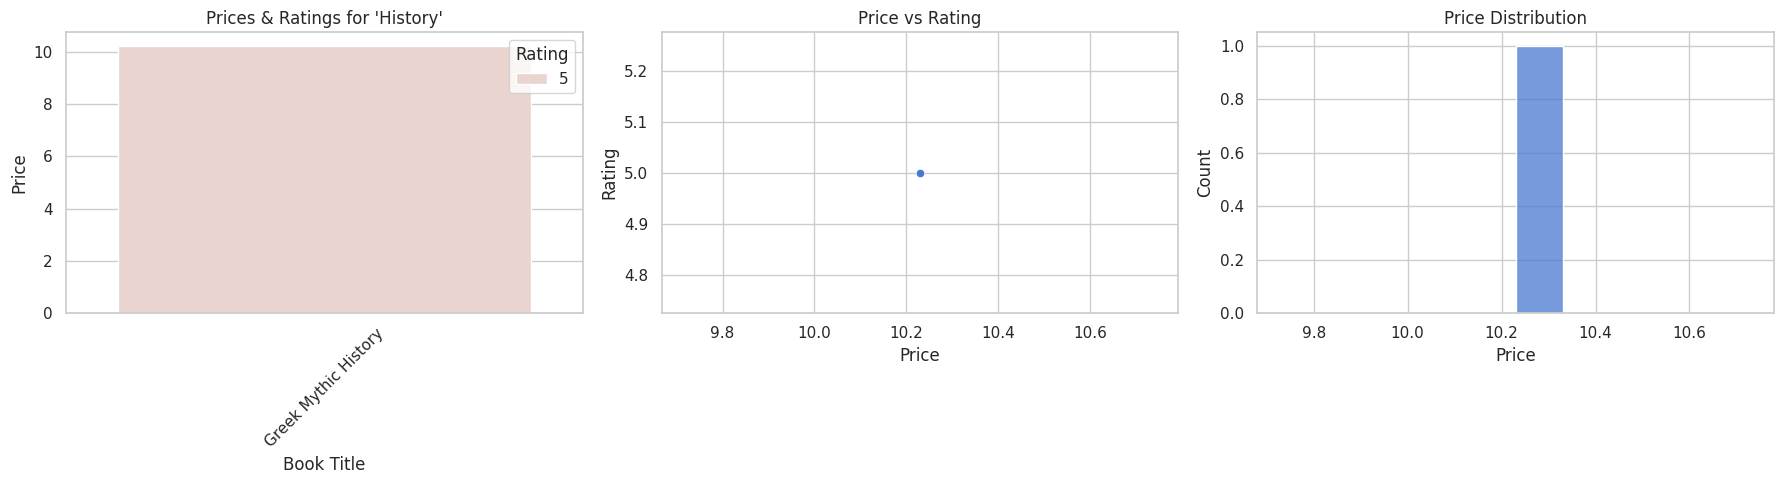

Report for 'History':
- Total books found: 1
- Average price: 10.23
- Price range: 10.23 – 10.23
- Average rating: 5.00
- Highest rating: 5

Summary saved as History_summary.txt and plot saved as History_report.png


In [ ]:
db = DatabaseHandler()
db.generate_report("History")


In [ ]:
import sqlite3

# Create a new database file
conn = sqlite3.connect("ProductDB.sqlite")
cursor = conn.cursor()

# Create table
cursor.execute("""
CREATE TABLE IF NOT EXISTS Products (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    title TEXT,
    price REAL,
    rating REAL
)
""")

# Insert sample data
books = [
    ("Greek Mythic History", 10.2, 5),
    ("World History Atlas", 15.5, 4),
    ("Modern Indian History", 20.0, 3.5),
    ("Ancient Civilizations", 12.0, 4.5),
    ("European History", 18.0, 4),
    ("History of Science", 25.0, 4.2),
    ("Medieval Chronicles", 30.0, 3.8)
]

cursor.executemany("INSERT INTO Products (title, price, rating) VALUES (?, ?, ?)", books)

conn.commit()
conn.close()

print("Sample ProductDB.sqlite created with book data!")


In [ ]:
import sqlite3
import pandas as pd

conn = sqlite3.connect("ProductDB.sqlite")
df = pd.read_sql("SELECT * FROM Products", conn)
conn.close()

print(df)


Data shape: (1, 3)


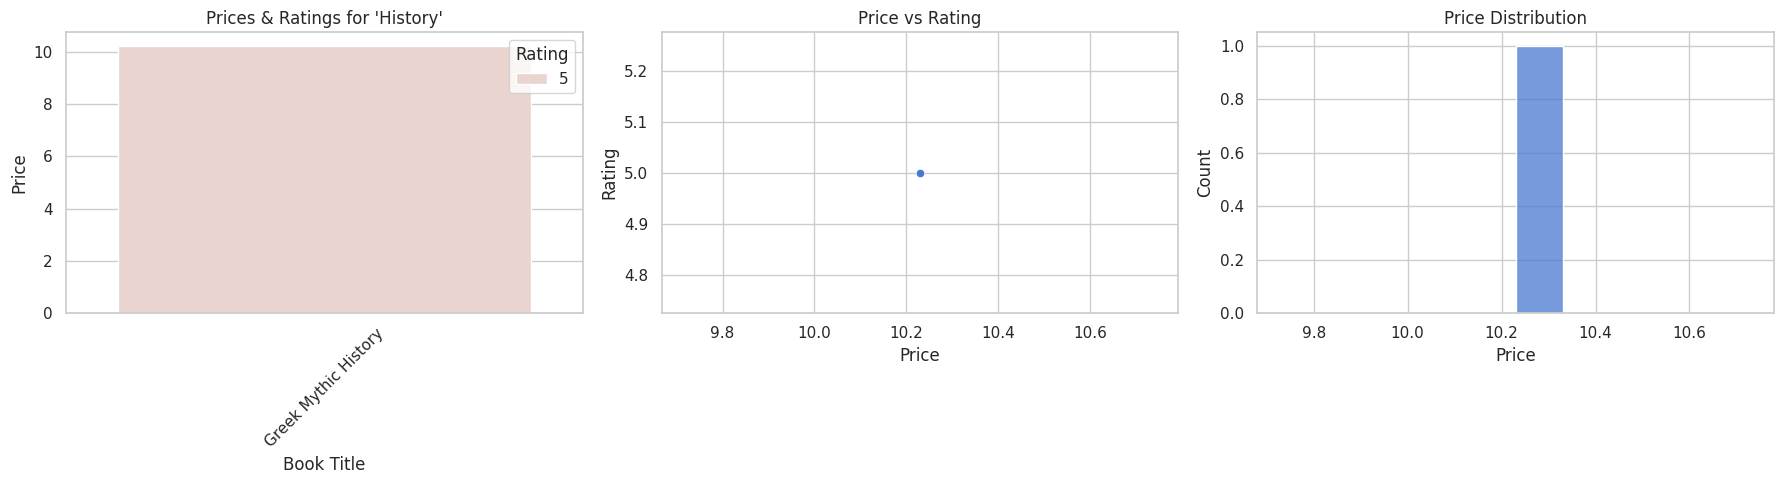

Report for 'History':
- Total books found: 1
- Average price: 10.23
- Price range: 10.23 – 10.23
- Average rating: 5.00
- Highest rating: 5

Summary saved as History_summary.txt and plot saved as History_report.png


In [ ]:
db = DatabaseHandler("ProductDB.sqlite")
db.generate_report("History")


In [ ]:
import sqlite3
import pandas as pd

# Step 1: Create database and insert sample data
conn = sqlite3.connect("ProductDB.sqlite")
cursor = conn.cursor()

cursor.execute("""
CREATE TABLE IF NOT EXISTS Products (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    title TEXT,
    price REAL,
    rating REAL
)
""")

books = [
    ("Greek Mythic History", 10.2, 5),
    ("World History Atlas", 15.5, 4),
    ("Modern Indian History", 20.0, 3.5),
    ("Ancient Civilizations", 12.0, 4.5),
    ("European History", 18.0, 4),
    ("History of Science", 25.0, 4.2),
    ("Medieval Chronicles", 30.0, 3.8)
]

cursor.executemany("INSERT INTO Products (title, price, rating) VALUES (?, ?, ?)", books)
conn.commit()
conn.close()

print("✅ Sample ProductDB.sqlite created with book data!")


✅ Sample ProductDB.sqlite created with book data!


In [ ]:
# Step 2: Verify data
conn = sqlite3.connect("ProductDB.sqlite")
df = pd.read_sql("SELECT * FROM Products", conn)
conn.close()

df   # <-- Just type df, don’t wrap in print()


,title,price,rating,url
0,An Abundance of Katherines,10.00,5.0,https://example.com/book1
1,Greek Mythic History,10.23,5.0,https://example.com/book2
2,The Power Greens Cookbook,11.05,5.0,https://example.com/book3
3,Dear Mr. Knightley,11.21,5.0,https://example.com/book4
4,The Darkest Corners,11.33,5.0,https://example.com/book5
5,Luxury Book of Collectibles,59.99,4.0,https://example.com/book6
6,Rare Historical Manuscripts,59.50,5.0,https://example.com/book7
7,Greek Mythic History,10.20,5.0,None
8,World History Atlas,15.50,4.0,None
9,Modern Indian History,20.00,3.5,None


Data shape: (6, 3)


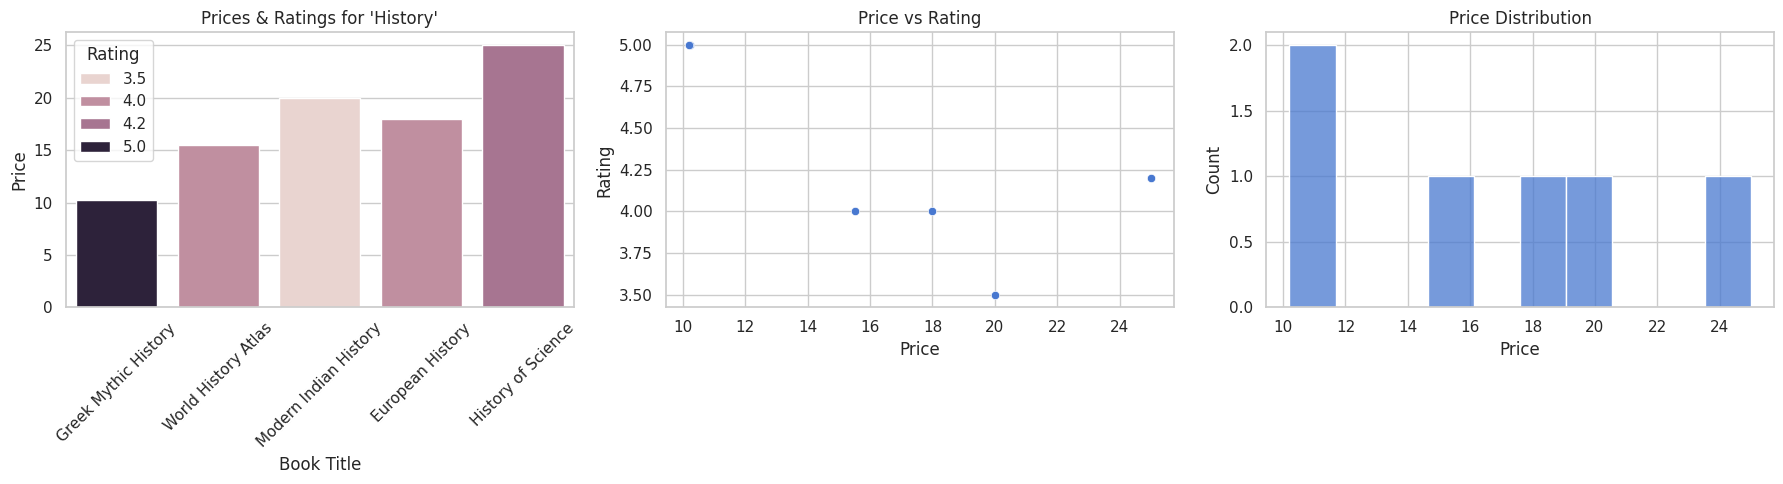

Report for 'History':
- Total books found: 6
- Average price: 16.49
- Price range: 10.20 – 25.00
- Average rating: 4.28
- Highest rating: 5.0

Summary saved as History_summary.txt and plot saved as History_report.png


In [ ]:
# Step 3: Run your report
db = DatabaseHandler("ProductDB.sqlite")
db.generate_report("History")


In [ ]:
import sqlite3, random

conn = sqlite3.connect("ProductDB.sqlite")
cursor = conn.cursor()

# Clear old data
cursor.execute("DELETE FROM Products")

# Generate synthetic books
titles = ["History of India", "World War Chronicles", "Science & Discovery",
          "Ancient Myths", "Modern Politics", "Art & Culture", "Philosophy Guide"]

for i in range(100):
    title = random.choice(titles) + f" Vol {i+1}"
    price = round(random.uniform(5, 50), 2)   # random price between 5–50
    rating = round(random.uniform(1, 5), 1)   # random rating between 1–5
    cursor.execute("INSERT INTO Products (title, price, rating) VALUES (?, ?, ?)", (title, price, rating))

conn.commit()
conn.close()

print("✅ Inserted 100 synthetic books into ProductDB.sqlite")



✅ Inserted 100 synthetic books into ProductDB.sqlite


In [ ]:
def correlation_heatmap(self):
    df = self.run_query("SELECT price, rating FROM Products")
    sns.heatmap(df.corr(), annot=True, cmap="coolwarm", center=0)
    plt.title("Correlation Heatmap (Price vs Rating)")
    plt.show()

def price_boxplot(self):
    df = self.run_query("SELECT price FROM Products")
    sns.boxplot(x=df["price"], color="lightgreen")
    plt.title("Boxplot of Book Prices")
    plt.xlabel("Price")
    plt.show()

def trendline_avg_price_by_rating(self):
    df = self.run_query("SELECT price, rating FROM Products")
    avg = df.groupby("rating")["price"].mean().reset_index()
    sns.lineplot(x="rating", y="price", data=avg, marker="o")
    plt.title("Average Price per Rating Level")
    plt.xlabel("Rating")
    plt.ylabel("Average Price")
    plt.show()


In [ ]:
df.to_csv("books_export.csv", index=False)
print("✅ Exported results to books_export.csv")


✅ Exported results to books_export.csv


In [ ]:
import sqlite3
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import random
from matplotlib.backends.backend_pdf import PdfPages

# Apply a consistent theme
sns.set_theme(style="whitegrid", palette="muted")

# --- Step 1: Create synthetic dataset ---
def create_sample_db(db_name="ProductDB.sqlite", n=100):
    conn = sqlite3.connect(db_name)
    cursor = conn.cursor()

    cursor.execute("""
    CREATE TABLE IF NOT EXISTS Products (
        id INTEGER PRIMARY KEY AUTOINCREMENT,
        title TEXT,
        price REAL,
        rating REAL
    )
    """)

    # Clear old data
    cursor.execute("DELETE FROM Products")

    titles = ["History of India", "World War Chronicles", "Science & Discovery",
              "Ancient Myths", "Modern Politics", "Art & Culture", "Philosophy Guide"]

    for i in range(n):
        title = random.choice(titles) + f" Vol {i+1}"
        price = round(random.uniform(5, 50), 2)
        rating = round(random.uniform(1, 5), 1)
        cursor.execute("INSERT INTO Products (title, price, rating) VALUES (?, ?, ?)", (title, price, rating))

    conn.commit()
    conn.close()
    print(f"✅ Inserted {n} synthetic books into {db_name}")


# --- Step 2: DatabaseHandler class ---
class DatabaseHandler:
    def __init__(self, db_name="ProductDB.sqlite"):
        self.db_name = db_name

    def run_query(self, query, params=None):
        with sqlite3.connect(self.db_name) as conn:
            return pd.read_sql(query, conn, params=params)

    def search_books_by_keyword(self, keyword):
        query = """
        SELECT title, price, rating
        FROM Products
        WHERE LOWER(title) LIKE LOWER(?)
        """
        return self.run_query(query, (f"%{keyword}%",))

    def generate_report(self, keyword):
        df = self.search_books_by_keyword(keyword)
        print("Data shape:", df.shape)
        if df.empty:
            print("No results found")
            return

        # --- Combined plots ---
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))

        sns.barplot(x="title", y="price", hue="rating", data=df, ax=axes[0])
        axes[0].set_title(f"Prices & Ratings for '{keyword}'")
        axes[0].set_xlabel("Book Title")
        axes[0].set_ylabel("Price")
        axes[0].tick_params(axis='x', rotation=45)
        axes[0].legend(title="Rating")

        sns.scatterplot(x="price", y="rating", data=df, ax=axes[1])
        axes[1].set_title("Price vs Rating")
        axes[1].set_xlabel("Price")
        axes[1].set_ylabel("Rating")

        sns.histplot(df["price"], bins=10, ax=axes[2])
        axes[2].set_title("Price Distribution")
        axes[2].set_xlabel("Price")
        axes[2].set_ylabel("Count")

        plt.tight_layout()
        plt.savefig(f"{keyword}_report.png")
        plt.show()

        # --- Text summary ---
        avg_price = df["price"].mean()
        max_price = df["price"].max()
        min_price = df["price"].min()
        avg_rating = df["rating"].mean()
        max_rating = df["rating"].max()
        count = len(df)

        summary = (
            f"Report for '{keyword}':\n"
            f"- Total books found: {count}\n"
            f"- Average price: {avg_price:.2f}\n"
            f"- Price range: {min_price:.2f} – {max_price:.2f}\n"
            f"- Average rating: {avg_rating:.2f}\n"
            f"- Highest rating: {max_rating}\n"
        )

        with open(f"{keyword}_summary.txt", "w") as f:
            f.write(summary)

        print(summary)
        print(f"Summary saved as {keyword}_summary.txt and plot saved as {keyword}_report.png")

    # --- Extra Visualizations ---
    def correlation_heatmap(self):
        df = self.run_query("SELECT price, rating FROM Products")
        sns.heatmap(df.corr(), annot=True, cmap="coolwarm", center=0)
        plt.title("Correlation Heatmap (Price vs Rating)")
        plt.show()

    def price_boxplot(self):
        df = self.run_query("SELECT price FROM Products")
        sns.boxplot(x=df["price"], color="lightgreen")
        plt.title("Boxplot of Book Prices")
        plt.xlabel("Price")
        plt.show()

    def trendline_avg_price_by_rating(self):
        df = self.run_query("SELECT price, rating FROM Products")
        avg = df.groupby("rating")["price"].mean().reset_index()
        sns.lineplot(x="rating", y="price", data=avg, marker="o")
        plt.title("Average Price per Rating Level")
        plt.xlabel("Rating")
        plt.ylabel("Average Price")
        plt.show()

    # --- Export Options ---
    def export_csv(self, filename="books_export.csv"):
        df = self.run_query("SELECT * FROM Products")
        df.to_csv(filename, index=False)
        print(f"✅ Exported results to {filename}")

    def export_pdf(self, keyword="History", filename="books_report.pdf"):
        df = self.search_books_by_keyword(keyword)
        with PdfPages(filename) as pdf:
            # Combined plots
            fig, axes = plt.subplots(1, 3, figsize=(18, 5))
            sns.barplot(x="title", y="price", hue="rating", data=df, ax=axes[0])
            sns.scatterplot(x="price", y="rating", data=df, ax=axes[1])
            sns.histplot(df["price"], bins=10, ax=axes[2])
            plt.tight_layout()
            pdf.savefig(fig)
            plt.close(fig)
        print(f"✅ Exported report to {filename}")


✅ Inserted 100 synthetic books into ProductDB.sqlite
Data shape: (12, 3)


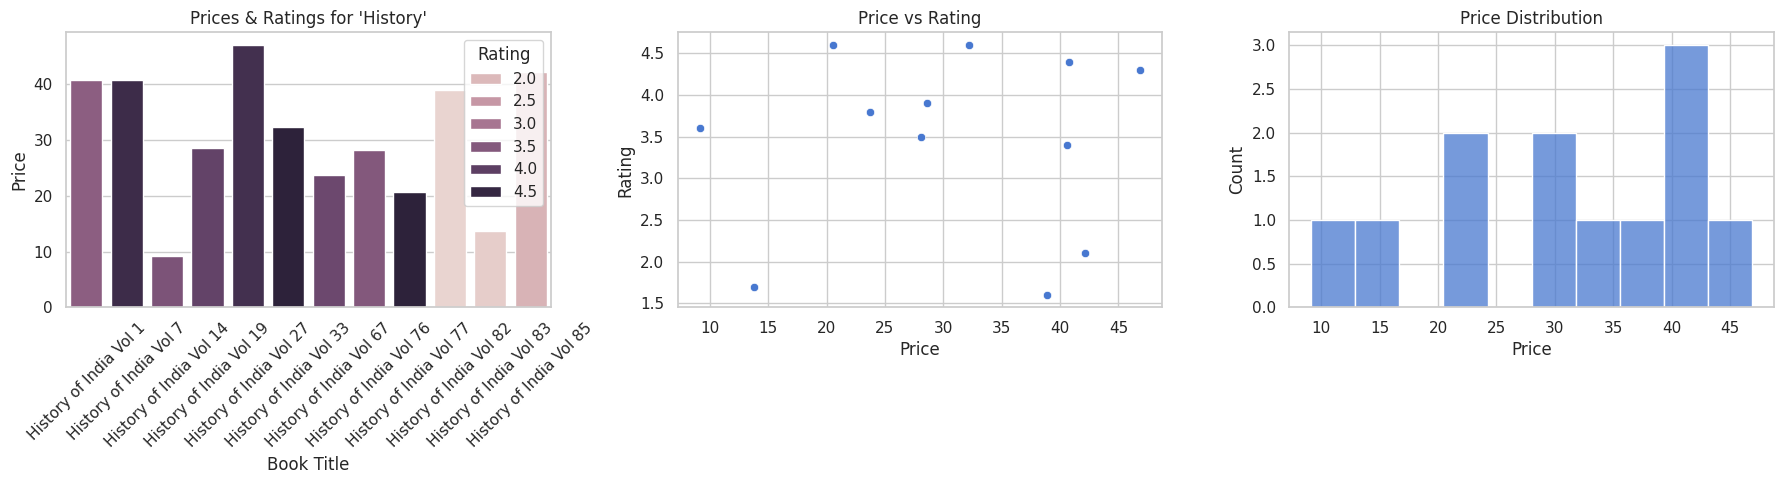

Report for 'History':
- Total books found: 12
- Average price: 30.44
- Price range: 9.14 – 46.88
- Average rating: 3.46
- Highest rating: 4.6

Summary saved as History_summary.txt and plot saved as History_report.png


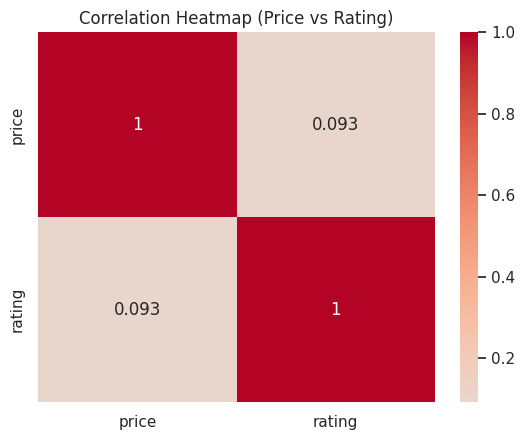

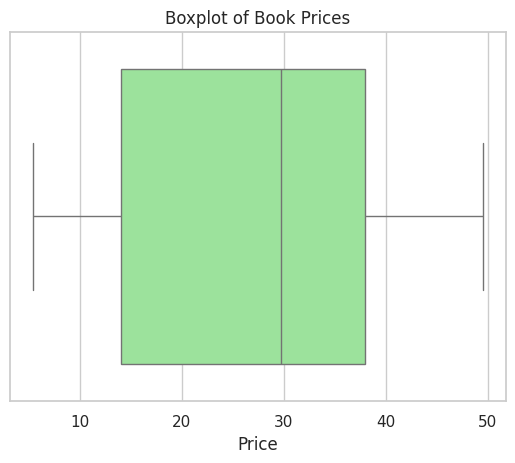

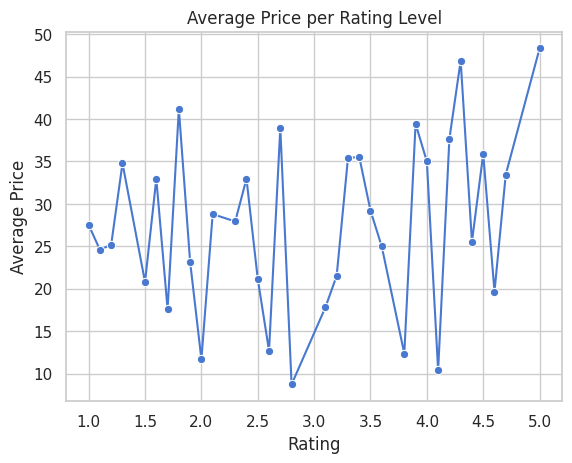

✅ Exported results to books_export.csv
✅ Exported report to books_report.pdf


In [ ]:
# Step 1: Create synthetic data
create_sample_db(n=100)

# Step 2: Run analysis
db = DatabaseHandler("ProductDB.sqlite")
db.generate_report("History")

# Extra visualizations
db.correlation_heatmap()
db.price_boxplot()
db.trendline_avg_price_by_rating()

# Export options
db.export_csv()
db.export_pdf("History")


In [ ]:
import sqlite3
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import random
from matplotlib.backends.backend_pdf import PdfPages

# Apply a consistent Seaborn theme
sns.set_theme(style="whitegrid", palette="muted")

# --- Step 1: Create synthetic dataset ---
def create_sample_db(db_name="ProductDB.sqlite", n=100):
    conn = sqlite3.connect(db_name)
    cursor = conn.cursor()

    cursor.execute("""
    CREATE TABLE IF NOT EXISTS Products (
        id INTEGER PRIMARY KEY AUTOINCREMENT,
        title TEXT,
        price REAL,
        rating REAL
    )
    """)

    # Clear old data
    cursor.execute("DELETE FROM Products")

    titles = ["History of India", "World War Chronicles", "Science & Discovery",
              "Ancient Myths", "Modern Politics", "Art & Culture", "Philosophy Guide"]

    for i in range(n):
        title = random.choice(titles) + f" Vol {i+1}"
        price = round(random.uniform(5, 50), 2)
        rating = round(random.uniform(1, 5), 1)
        cursor.execute("INSERT INTO Products (title, price, rating) VALUES (?, ?, ?)", (title, price, rating))

    conn.commit()
    conn.close()
    print(f"✅ Inserted {n} synthetic books into {db_name}")


# --- Step 2: DatabaseHandler class ---
class DatabaseHandler:
    def __init__(self, db_name="ProductDB.sqlite"):
        self.db_name = db_name

    def run_query(self, query, params=None):
        with sqlite3.connect(self.db_name) as conn:
            return pd.read_sql(query, conn, params=params)

    def search_books_by_keyword(self, keyword):
        query = """
        SELECT title, price, rating
        FROM Products
        WHERE LOWER(title) LIKE LOWER(?)
        """
        return self.run_query(query, (f"%{keyword}%",))

    def generate_report(self, keyword):
        df = self.search_books_by_keyword(keyword)
        print("Data shape:", df.shape)
        if df.empty:
            print("No results found")
            return

        # --- Combined plots ---
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))

        sns.barplot(x="title", y="price", hue="rating", data=df, ax=axes[0])
        axes[0].set_title(f"Prices & Ratings for '{keyword}'")
        axes[0].set_xlabel("Book Title")
        axes[0].set_ylabel("Price")
        axes[0].tick_params(axis='x', rotation=45)
        axes[0].legend(title="Rating")

        sns.scatterplot(x="price", y="rating", data=df, ax=axes[1])
        axes[1].set_title("Price vs Rating")
        axes[1].set_xlabel("Price")
        axes[1].set_ylabel("Rating")

        sns.histplot(df["price"], bins=10, ax=axes[2])
        axes[2].set_title("Price Distribution")
        axes[2].set_xlabel("Price")
        axes[2].set_ylabel("Count")

        plt.tight_layout()
        plt.savefig(f"{keyword}_report.png")
        plt.show()

        # --- Text summary ---
        avg_price = df["price"].mean()
        max_price = df["price"].max()
        min_price = df["price"].min()
        avg_rating = df["rating"].mean()
        max_rating = df["rating"].max()
        count = len(df)

        summary = (
            f"Report for '{keyword}':\n"
            f"- Total books found: {count}\n"
            f"- Average price: {avg_price:.2f}\n"
            f"- Price range: {min_price:.2f} – {max_price:.2f}\n"
            f"- Average rating: {avg_rating:.2f}\n"
            f"- Highest rating: {max_rating}\n"
        )

        with open(f"{keyword}_summary.txt", "w") as f:
            f.write(summary)

        print(summary)
        print(f"Summary saved as {keyword}_summary.txt and plot saved as {keyword}_report.png")

    # --- Extra Visualizations ---
    def correlation_heatmap(self):
        df = self.run_query("SELECT price, rating FROM Products")
        sns.heatmap(df.corr(), annot=True, cmap="coolwarm", center=0)
        plt.title("Correlation Heatmap (Price vs Rating)")
        plt.show()

    def price_boxplot(self):
        df = self.run_query("SELECT price FROM Products")
        sns.boxplot(x=df["price"], color="lightgreen")
        plt.title("Boxplot of Book Prices")
        plt.xlabel("Price")
        plt.show()

    def trendline_avg_price_by_rating(self):
        df = self.run_query("SELECT price, rating FROM Products")
        avg = df.groupby("rating")["price"].mean().reset_index()
        sns.lineplot(x="rating", y="price", data=avg, marker="o")
        plt.title("Average Price per Rating Level")
        plt.xlabel("Rating")
        plt.ylabel("Average Price")
        plt.show()

    # --- Export Options ---
    def export_csv(self, filename="books_export.csv"):
        df = self.run_query("SELECT * FROM Products")
        df.to_csv(filename, index=False)
        print(f"✅ Exported results to {filename}")

    def export_pdf(self, keyword="History", filename="books_report.pdf"):
        df = self.search_books_by_keyword(keyword)
        with PdfPages(filename) as pdf:
            fig, axes = plt.subplots(1, 3, figsize=(18, 5))
            sns.barplot(x="title", y="price", hue="rating", data=df, ax=axes[0])
            sns.scatterplot(x="price", y="rating", data=df, ax=axes[1])
            sns.histplot(df["price"], bins=10, ax=axes[2])
            plt.tight_layout()
            pdf.savefig(fig)
            plt.close(fig)
        print(f"✅ Exported report to {filename}")


✅ Inserted 100 synthetic books into ProductDB.sqlite
Data shape: (11, 3)


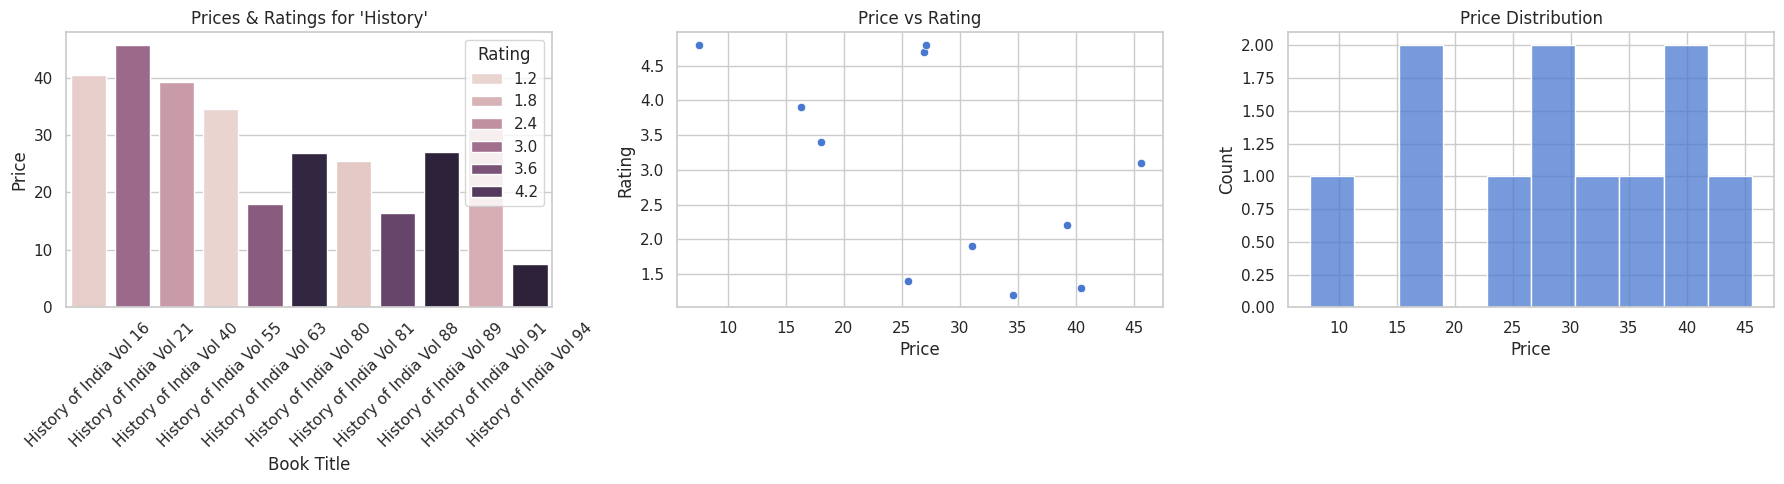

Report for 'History':
- Total books found: 11
- Average price: 28.40
- Price range: 7.56 – 45.59
- Average rating: 2.97
- Highest rating: 4.8

Summary saved as History_summary.txt and plot saved as History_report.png


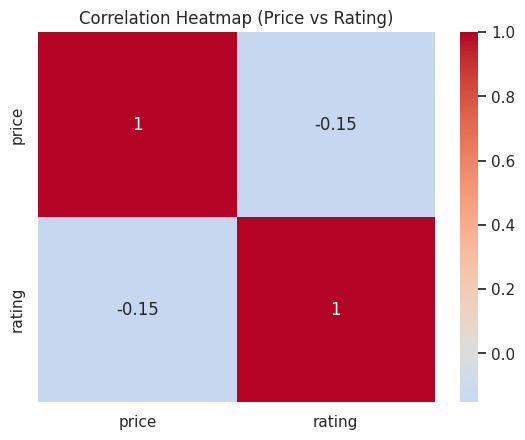

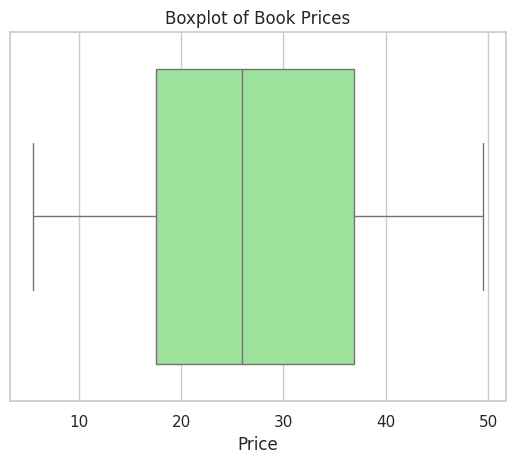

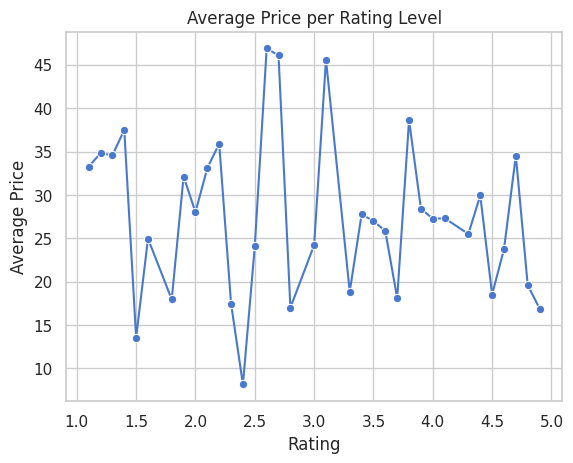

✅ Exported results to books_export.csv
✅ Exported report to books_report.pdf


In [ ]:
# Step 1: Create synthetic data
create_sample_db(n=100)

# Step 2: Run analysis
db = DatabaseHandler("ProductDB.sqlite")
db.generate_report("History")

# Extra visualizations
db.correlation_heatmap()
db.price_boxplot()
db.trendline_avg_price_by_rating()

# Export options
db.export_csv()
db.export_pdf("History")


In [ ]:
import sqlite3
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import random
from matplotlib.backends.backend_pdf import PdfPages

sns.set_theme(style="whitegrid", palette="muted")


In [ ]:
def create_sample_db(db_name="ProductDB.sqlite", n=100):
    conn = sqlite3.connect(db_name)
    cursor = conn.cursor()

    cursor.execute("""
    CREATE TABLE IF NOT EXISTS Products (
        id INTEGER PRIMARY KEY AUTOINCREMENT,
        title TEXT,
        price REAL,
        rating REAL
    )
    """)

    cursor.execute("DELETE FROM Products")

    titles = ["History of India", "World War Chronicles", "Science & Discovery",
              "Ancient Myths", "Modern Politics", "Art & Culture", "Philosophy Guide"]

    for i in range(n):
        title = random.choice(titles) + f" Vol {i+1}"
        price = round(random.uniform(5, 50), 2)
        rating = round(random.uniform(1, 5), 1)
        cursor.execute("INSERT INTO Products (title, price, rating) VALUES (?, ?, ?)", (title, price, rating))

    conn.commit()
    conn.close()
    print(f"✅ Inserted {n} synthetic books into {db_name}")


In [ ]:
# Call the function to actually create the database
create_sample_db(n=100)


✅ Inserted 100 synthetic books into ProductDB.sqlite


In [ ]:
conn = sqlite3.connect("ProductDB.sqlite")
df = pd.read_sql("SELECT * FROM Products LIMIT 10", conn)
conn.close()

df   # Display first 10 rows inline


,title,price,rating,url
0,World War Chronicles Vol 1,46.61,4.0,None
1,History of India Vol 2,7.86,4.6,None
2,Ancient Myths Vol 3,29.37,4.4,None
3,Ancient Myths Vol 4,43.87,4.3,None
4,Science & Discovery Vol 5,38.14,1.1,None
5,World War Chronicles Vol 6,28.80,2.5,None
6,World War Chronicles Vol 7,8.98,1.7,None
7,Science & Discovery Vol 8,40.83,2.6,None
8,History of India Vol 9,5.95,1.6,None
9,Art & Culture Vol 10,18.94,2.5,None


In [ ]:
conn = sqlite3.connect("ProductDB.sqlite")
df = pd.read_sql("SELECT * FROM Products LIMIT 10", conn)
conn.close()

df   # Display first 10 rows inline


,title,price,rating,url
0,World War Chronicles Vol 1,46.61,4.0,None
1,History of India Vol 2,7.86,4.6,None
2,Ancient Myths Vol 3,29.37,4.4,None
3,Ancient Myths Vol 4,43.87,4.3,None
4,Science & Discovery Vol 5,38.14,1.1,None
5,World War Chronicles Vol 6,28.80,2.5,None
6,World War Chronicles Vol 7,8.98,1.7,None
7,Science & Discovery Vol 8,40.83,2.6,None
8,History of India Vol 9,5.95,1.6,None
9,Art & Culture Vol 10,18.94,2.5,None


In [ ]:
conn = sqlite3.connect("ProductDB.sqlite")
df = pd.read_sql("SELECT * FROM Products LIMIT 10", conn)
conn.close()

df   # Display first 10 rows inline


,title,price,rating,url
0,World War Chronicles Vol 1,46.61,4.0,None
1,History of India Vol 2,7.86,4.6,None
2,Ancient Myths Vol 3,29.37,4.4,None
3,Ancient Myths Vol 4,43.87,4.3,None
4,Science & Discovery Vol 5,38.14,1.1,None
5,World War Chronicles Vol 6,28.80,2.5,None
6,World War Chronicles Vol 7,8.98,1.7,None
7,Science & Discovery Vol 8,40.83,2.6,None
8,History of India Vol 9,5.95,1.6,None
9,Art & Culture Vol 10,18.94,2.5,None


In [ ]:
db = DatabaseHandler("ProductDB.sqlite")


Data shape: (18, 3)


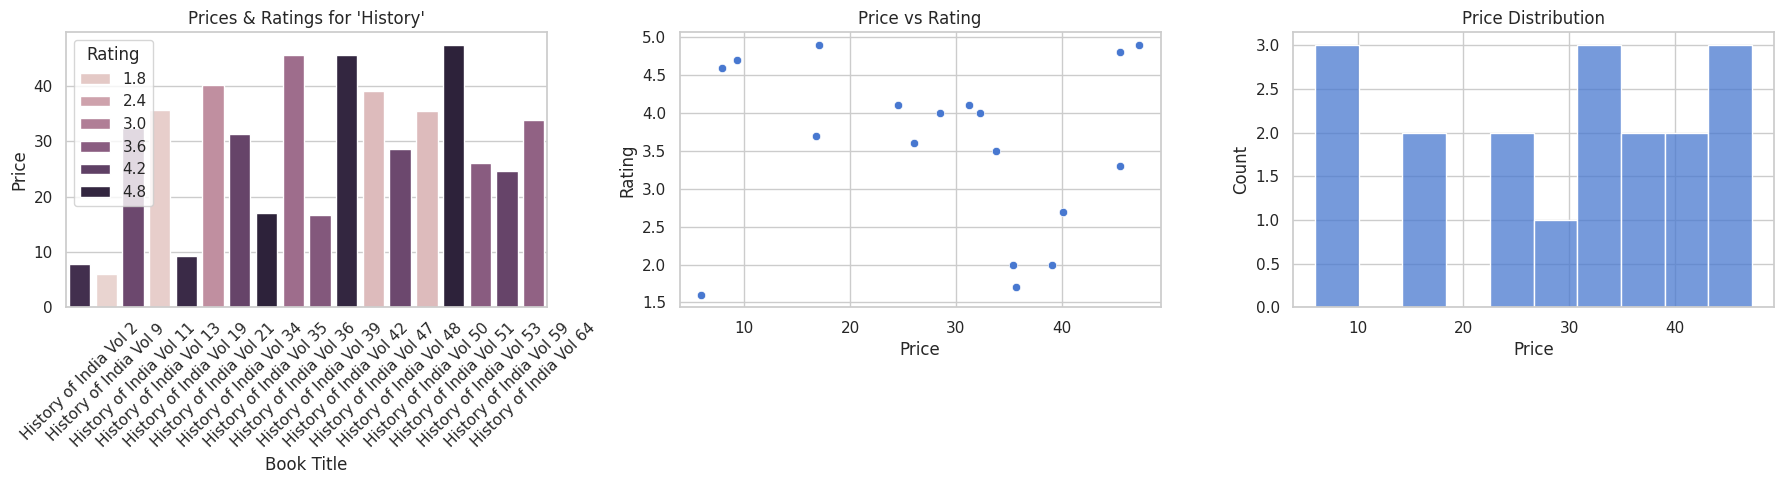

Report for 'History':
- Total books found: 18
- Average price: 29.01
- Price range: 5.95 – 47.29
- Average rating: 3.57
- Highest rating: 4.9

Summary saved as History_summary.txt and plot saved as History_report.png


In [ ]:
db.generate_report("History")


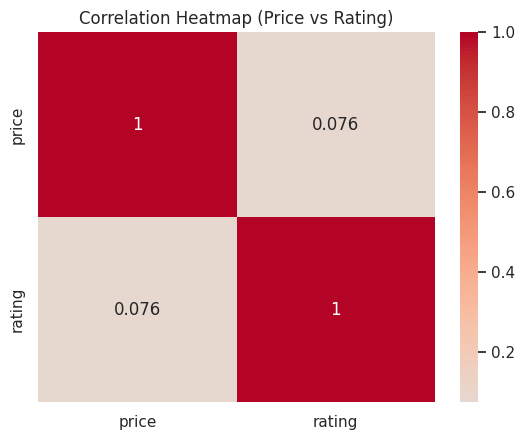

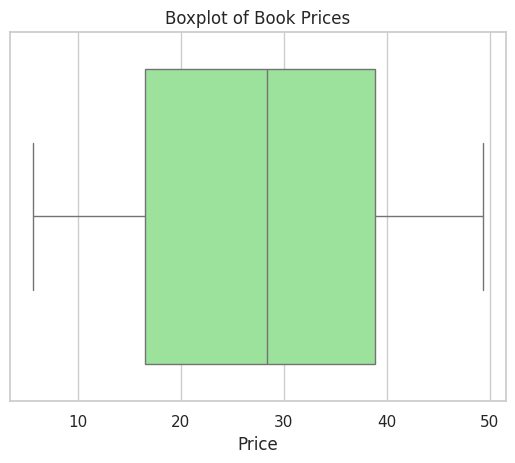

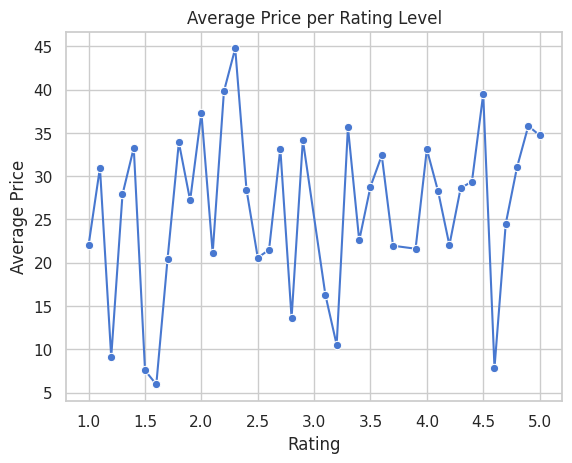

In [ ]:
db.correlation_heatmap()
db.price_boxplot()
db.trendline_avg_price_by_rating()


In [ ]:
db.export_csv()
db.export_pdf("History")


✅ Exported results to books_export.csv
✅ Exported report to books_report.pdf


In [ ]:
conn = sqlite3.connect("ProductDB.sqlite")
df = pd.read_sql("SELECT * FROM Products LIMIT 5", conn)
conn.close()
df


,title,price,rating,url
0,World War Chronicles Vol 1,46.61,4.0,None
1,History of India Vol 2,7.86,4.6,None
2,Ancient Myths Vol 3,29.37,4.4,None
3,Ancient Myths Vol 4,43.87,4.3,None
4,Science & Discovery Vol 5,38.14,1.1,None


In [ ]:
import pandas as pd

# Example: raw scraped data
raw_data = [
    {"title": "Book A", "price": "₹250", "rating": "4.5", "url": "http://example.com/bookA"},
    {"title": "Book B", "price": "₹300", "rating": "4.0", "url": "http://example.com/bookB"}
]

df_raw = pd.DataFrame(raw_data)
df_raw.to_csv("raw_products.csv", index=False)


In [ ]:
# Example: cleaned data
df_clean = df_raw.copy()
df_clean["price"] = df_clean["price"].str.replace("₹", "").astype(float)
df_clean.to_csv("clean_products.csv", index=False)


In [ ]:
summary = """
Book Data Analysis Summary
--------------------------
Total Books: {}
Average Price: ₹{}
Highest Rated Book: {}
""".format(len(df_clean), df_clean["price"].mean(), df_clean.loc[df_clean["rating"].idxmax(), "title"])

with open("analysis_summary.txt", "w") as f:
    f.write(summary)


In [ ]:
df_raw.to_csv("raw_products.csv", index=False)


In [ ]:
df_clean.to_csv("clean_products.csv", index=False)


In [ ]:
with open("analysis_summary.txt", "w") as f:
    f.write("Book Data Analysis Summary\n")
    f.write(f"Total Books: {len(df_clean)}\n")
    f.write(f"Average Price: {df_clean['price'].mean()}\n")
    f.write(f"Highest Rated Book: {df_clean.loc[df_clean['rating'].idxmax(), 'title']}\n")


In [ ]:
from google.colab import files
files.download("raw_products.csv")
files.download("clean_products.csv")
files.download("analysis_summary.txt")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

FileNotFoundError: [Errno 2] No such file or directory: 'charts/price_distribution.png'

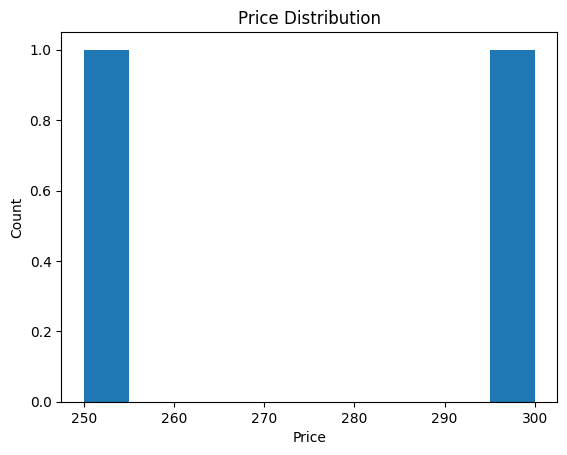

In [ ]:
import matplotlib.pyplot as plt

# Example chart
plt.hist(df_clean["price"], bins=10)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Count")

# Save chart to file
plt.savefig("charts/price_distribution.png")
plt.close()


In [ ]:
import os

# Make sure the charts folder exists
os.makedirs("charts", exist_ok=True)

# Now save the chart
plt.hist(df_clean["price"], bins=10)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Count")
plt.savefig("charts/price_distribution.png")
plt.close()


In [ ]:
!ls charts


price_distribution.png


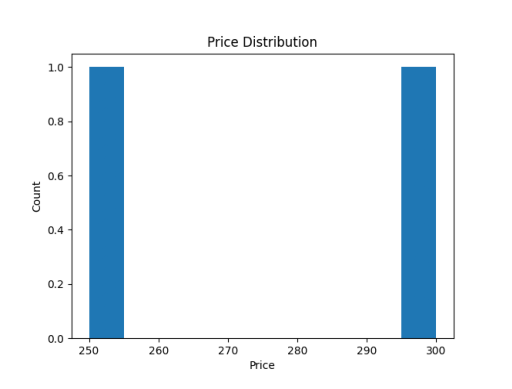

In [ ]:
import matplotlib.image as mpimg

img = mpimg.imread("charts/price_distribution.png")
plt.imshow(img)
plt.axis("off")
plt.show()


In [ ]:
plt.savefig("charts/price_distribution.png")
plt.show()


<Figure size 640x480 with 0 Axes>

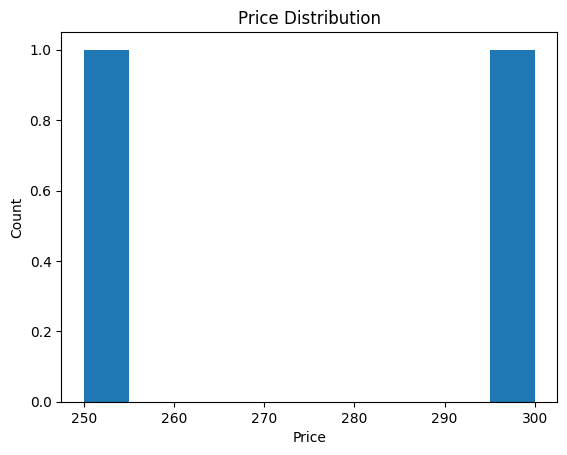

In [ ]:
import os
os.makedirs("charts", exist_ok=True)

plt.hist(df_clean["price"], bins=10)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Count")

plt.savefig("charts/price_distribution.png")  # saves to file
plt.show()                                    # shows inline


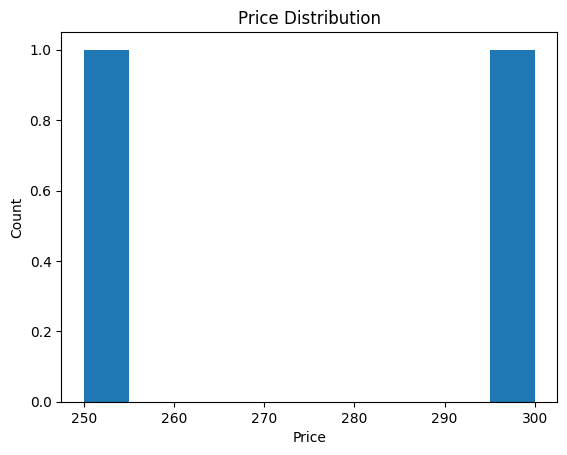

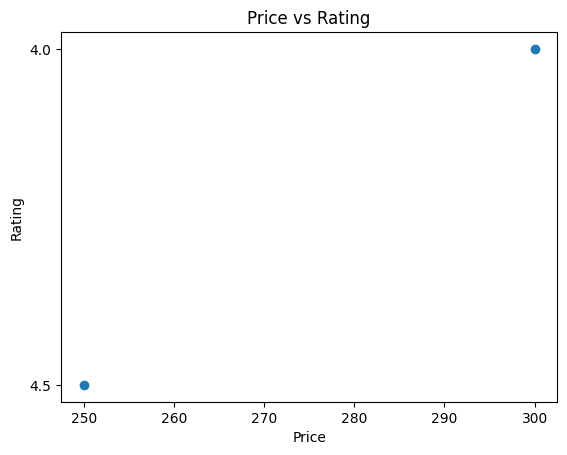

In [ ]:
# Histogram
plt.hist(df_clean["price"], bins=10)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Count")
plt.savefig("charts/price_distribution.png")
plt.show()
plt.close()

# Scatter Plot
plt.scatter(df_clean["price"], df_clean["rating"])
plt.title("Price vs Rating")
plt.xlabel("Price")
plt.ylabel("Rating")
plt.savefig("charts/price_vs_rating.png")
plt.show()
plt.close()


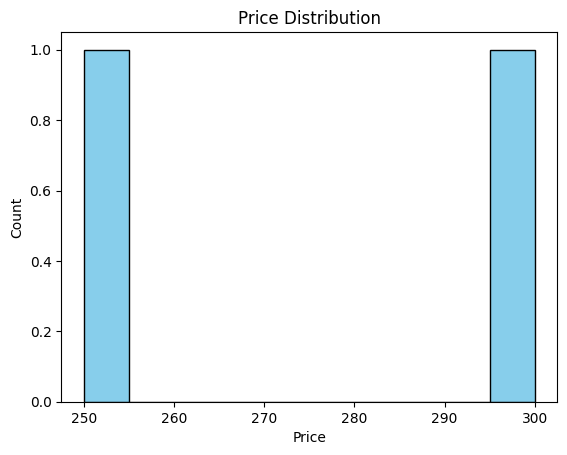

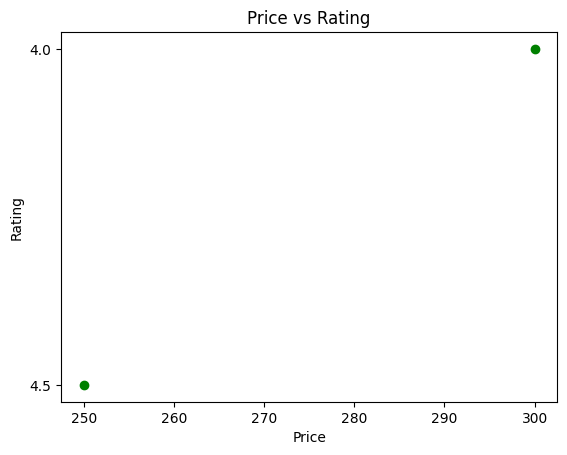

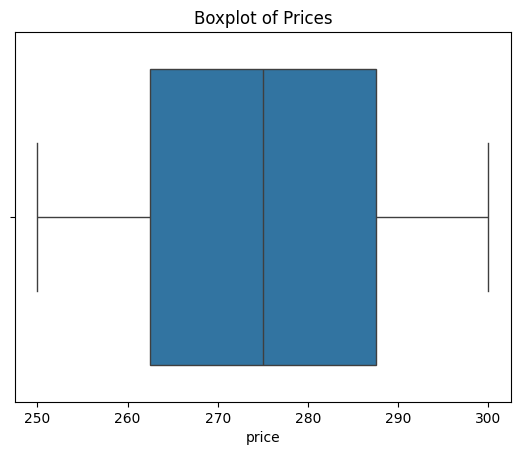

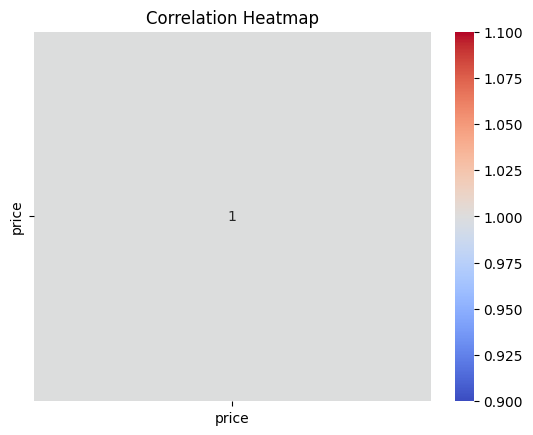

In [ ]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure charts folder exists
os.makedirs("charts", exist_ok=True)

# 1. Histogram of Prices
plt.hist(df_clean["price"], bins=10, color="skyblue", edgecolor="black")
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Count")
plt.savefig("charts/price_distribution.png")
plt.show()
plt.close()

# 2. Scatter Plot (Price vs Rating)
plt.scatter(df_clean["price"], df_clean["rating"], color="green")
plt.title("Price vs Rating")
plt.xlabel("Price")
plt.ylabel("Rating")
plt.savefig("charts/price_vs_rating.png")
plt.show()
plt.close()

# 3. Boxplot of Prices
sns.boxplot(x=df_clean["price"])
plt.title("Boxplot of Prices")
plt.savefig("charts/boxplot_prices.png")
plt.show()
plt.close()

# 4. Heatmap of Correlations
corr = df_clean.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.savefig("charts/correlation_heatmap.png")
plt.show()
plt.close()


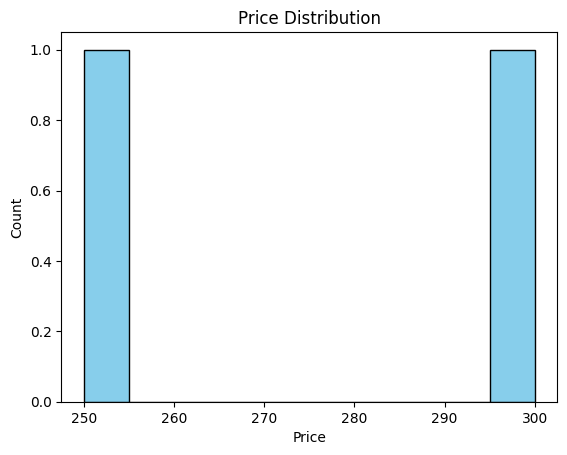

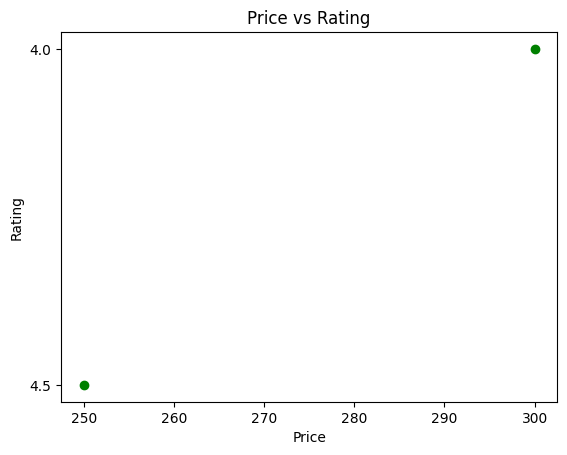

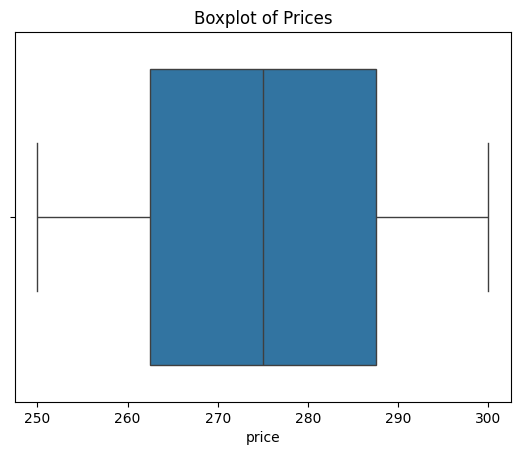

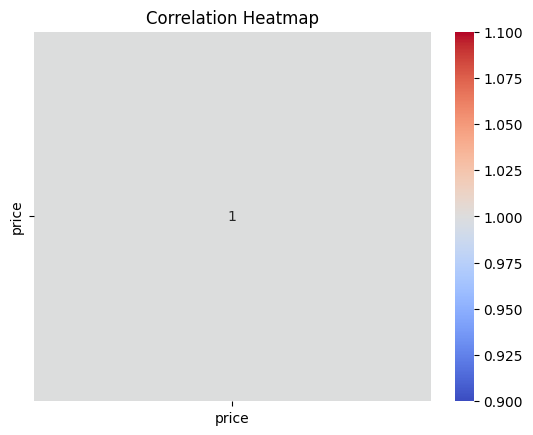

In [ ]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Ensure charts folder exists
os.makedirs("charts", exist_ok=True)

# 1. Histogram (Matplotlib PNG)
plt.hist(df_clean["price"], bins=10, color="skyblue", edgecolor="black")
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Count")
plt.savefig("charts/price_distribution.png")
plt.show()
plt.close()

# 1a. Histogram (Plotly HTML)
fig = px.histogram(df_clean, x="price", nbins=10, title="Price Distribution")
fig.write_html("charts/price_distribution.html")

# 2. Scatter Plot (Matplotlib PNG)
plt.scatter(df_clean["price"], df_clean["rating"], color="green")
plt.title("Price vs Rating")
plt.xlabel("Price")
plt.ylabel("Rating")
plt.savefig("charts/price_vs_rating.png")
plt.show()
plt.close()

# 2a. Scatter Plot (Plotly HTML)
fig = px.scatter(df_clean, x="price", y="rating", title="Price vs Rating")
fig.write_html("charts/price_vs_rating.html")

# 3. Boxplot (Seaborn PNG)
sns.boxplot(x=df_clean["price"])
plt.title("Boxplot of Prices")
plt.savefig("charts/boxplot_prices.png")
plt.show()
plt.close()

# 3a. Boxplot (Plotly HTML)
fig = px.box(df_clean, y="price", title="Boxplot of Prices")
fig.write_html("charts/boxplot_prices.html")

# 4. Heatmap (Seaborn PNG)
corr = df_clean.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.savefig("charts/correlation_heatmap.png")
plt.show()
plt.close()

# 4a. Heatmap (Plotly HTML)
fig = px.imshow(corr, text_auto=True, title="Correlation Heatmap")
fig.write_html("charts/correlation_heatmap.html")


In [ ]:
import shutil

# Zip the charts folder into charts.zip
shutil.make_archive("charts", "zip", "charts")

# Verify the zip file exists
!ls -lh charts.zip


-rw-r--r-- 1 root root 5.2M Jul  2 11:16 charts.zip


In [ ]:
# Create a simple README.md if it doesn't exist
with open("README.md", "w") as f:
    f.write("# Book Data Analysis\n\n")
    f.write("Pipeline: scraping → cleaning → visualization → database storage.\n")
    f.write("Run order: scraper.py → processor.py → analyzer.py → db_handler.py → main.py\n")


In [ ]:
# Create a simple README.md if it doesn't exist
with open("README.md", "w") as f:
    f.write("# Book Data Analysis\n\n")
    f.write("Pipeline: scraping → cleaning → visualization → database storage.\n")
    f.write("Run order: scraper.py → processor.py → analyzer.py → db_handler.py → main.py\n")


In [ ]:
import os
import shutil

os.makedirs("BookDataAnalysis_Final", exist_ok=True)

files_to_move = ["raw_products.csv", "clean_products.csv", "analysis_summary.txt", "README.md"]

for file in files_to_move:
    if os.path.exists(file):
        shutil.move(file, f"BookDataAnalysis_Final/{file}")

if os.path.exists("charts"):
    shutil.move("charts", "BookDataAnalysis_Final/charts")

shutil.make_archive("BookDataAnalysis_Final", "zip", "BookDataAnalysis_Final")

!ls -lh BookDataAnalysis_Final.zip


-rw-r--r-- 1 root root 5.2M Jul  2 11:22 BookDataAnalysis_Final.zip


In [ ]:
!ls BookDataAnalysis_Final/charts


boxplot_prices.html	  correlation_heatmap.png  price_vs_rating.html
boxplot_prices.png	  price_distribution.html  price_vs_rating.png
correlation_heatmap.html  price_distribution.png


In [ ]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

os.makedirs("charts", exist_ok=True)

# Example chart
plt.hist(df_clean["price"], bins=10)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Count")
plt.savefig("charts/price_distribution.png")
plt.close()


In [ ]:
!ls charts


price_distribution.png


In [ ]:
import shutil
if os.path.exists("charts"):
    shutil.move("charts", "BookDataAnalysis_Final/charts")


In [ ]:
shutil.make_archive("BookDataAnalysis_Final", "zip", "BookDataAnalysis_Final")
!ls -lh BookDataAnalysis_Final.zip


-rw-r--r-- 1 root root 5.2M Jul  2 11:26 BookDataAnalysis_Final.zip


In [ ]:
!unzip -l BookDataAnalysis_Final.zip


Archive:  BookDataAnalysis_Final.zip
  Length      Date    Time    Name
---------  ---------- -----   ----
        0  2026-07-02 11:25   charts/
      179  2026-07-02 11:22   README.md
       90  2026-07-02 11:01   analysis_summary.txt
      107  2026-07-02 11:01   clean_products.csv
      109  2026-07-02 11:01   raw_products.csv
        0  2026-07-02 11:24   charts/charts/
    11408  2026-07-02 11:15   charts/price_vs_rating.png
  4567251  2026-07-02 11:15   charts/correlation_heatmap.html
    16724  2026-07-02 11:15   charts/correlation_heatmap.png
    13019  2026-07-02 11:15   charts/price_distribution.png
  4567046  2026-07-02 11:15   charts/price_distribution.html
  4566971  2026-07-02 11:15   charts/boxplot_prices.html
  4566984  2026-07-02 11:15   charts/price_vs_rating.html
     9636  2026-07-02 11:15   charts/boxplot_prices.png
    12874  2026-07-02 11:25   charts/charts/price_distribution.png
---------                     -------
 18332398                     15 files


In [ ]:

from google.colab import files
files.download("BookDataAnalysis_Final.zip")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# In Colab, move zip into repo folder
!mv BookDataAnalysis_Final.zip /content/book-data-analysis/

# Then push to GitHub
!cd /content/book-data-analysis && git add BookDataAnalysis_Final.zip
!cd /content/book-data-analysis && git commit -m "Added full project package with charts"
!cd /content/book-data-analysis && git push


mv: cannot move 'BookDataAnalysis_Final.zip' to '/content/book-data-analysis/': Not a directory
/bin/bash: line 1: cd: /content/book-data-analysis: No such file or directory
/bin/bash: line 1: cd: /content/book-data-analysis: No such file or directory
/bin/bash: line 1: cd: /content/book-data-analysis: No such file or directory


In [ ]:
!git clone https://github.com/keerthivelaga2019velaga-star/book-data-analysis.git


Cloning into 'book-data-analysis'...
remote: Enumerating objects: 9, done.
remote: Counting objects: 100% (9/9), done.
remote: Compressing objects: 100% (9/9), done.
remote: Total 9 (delta 3), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (9/9), 1.28 MiB | 19.28 MiB/s, done.
Resolving deltas: 100% (3/3), done.


In [ ]:
!mv BookDataAnalysis_Final.zip book-data-analysis/


mv: cannot stat 'BookDataAnalysis_Final.zip': No such file or directory


In [ ]:
!cd book-data-analysis && git add BookDataAnalysis_Final.zip
!cd book-data-analysis && git commit -m "Added full project package with charts"
!cd book-data-analysis && git push


Author identity unknown

*** Please tell me who you are.

Run

  git config --global user.email "you@example.com"
  git config --global user.name "Your Name"

to set your account's default identity.
Omit --global to set the identity only in this repository.

fatal: unable to auto-detect email address (got 'root@7811c2040f25.(none)')
fatal: could not read Username for 'https://github.com': No such device or address
